In [1]:
# # Cell 0 — Dataset Setup & Format Conversion
# # ============================================================
# # YOUR FOLDER STRUCTURE (from VS Code Explorer):
# #
# #   T2520716/
# #   ├── CHARADES_STA_DATASET/
# #   │   ├── annotations/annotations/annotations/
# #   │   │   ├── charades_sta_train.txt   ← raw annotation file
# #   │   │   ├── charades_sta_test.txt    ← raw annotation file
# #   │   │   └── charades_subset.json
# #   │   ├── videos/videos/videos/        ← your .mp4 files live here
# #   │   ├── train.csv
# #   │   └── test.csv
# #   ├── TEMPORAL_GROUNDING_VSCODE.ipynb  ← this notebook
# #   └── VLMI.ipynb
# #
# # WHAT THIS CELL DOES:
# #   1. Reads your .txt annotation files (CharadesSTA native format)
# #   2. Reads video durations from train.csv / test.csv
# #   3. Converts everything to the .json format the notebook expects
# #   4. Writes train.json, val.json, test.json into ./CharadesSTA/Annotations/
# #   5. Creates a symlink/copy so the Config paths resolve correctly
# #
# # RUN THIS CELL ONCE before Cell 3 (Config). You do not need to re-run
# # it on subsequent training sessions — the .json files persist on disk.
# # ============================================================

# import os, json, csv, shutil
# from pathlib import Path
# from collections import defaultdict

# # ── Step 1: Point to your actual paths ───────────────────────────────────────
# # These match exactly what is visible in your VS Code Explorer.
# BASE          = Path(".")   # notebook is in T2520716/

# ANNO_DIR      = BASE / "CHARADES_STA_DATASET" / "annotations" / "annotations" / "annotations"
# VIDEO_DIR_SRC = BASE / "CHARADES_STA_DATASET" / "videos" / "videos" / "videos"

# TRAIN_TXT     = ANNO_DIR / "charades_sta_train.txt"
# TEST_TXT      = ANNO_DIR / "charades_sta_test.txt"
# TRAIN_CSV     = BASE / "CHARADES_STA_DATASET" / "train.csv"
# TEST_CSV      = BASE / "CHARADES_STA_DATASET" / "test.csv"

# # ── Step 2: Output paths (what the notebook Config expects) ───────────────────
# OUT_ROOT      = BASE / "CHARADES_STA_DATASET"
# OUT_ANNO      = OUT_ROOT / "Annotations"
# OUT_VIDEO     = OUT_ROOT / "Videos"

# OUT_ROOT.mkdir(parents=True, exist_ok=True)
# OUT_ANNO.mkdir(parents=True, exist_ok=True)

# # ── Step 3: Symlink video folder (avoids copying ~50GB of video files) ────────
# # Creates CharadesSTA/Videos → CHARADES_STA_DATASET/videos/videos/videos
# if not OUT_VIDEO.exists():
#     try:
#         OUT_VIDEO.symlink_to(VIDEO_DIR_SRC.resolve())
#         print(f"[OK] Video symlink created: {OUT_VIDEO} → {VIDEO_DIR_SRC.resolve()}")
#     except Exception as e:
#         # Fallback on Windows (symlinks need admin rights) — use junction or warn
#         print(f"[WARN] Symlink failed ({e})")
#         print(f"       On Windows: run VS Code as Administrator, or manually copy")
#         print(f"       {VIDEO_DIR_SRC}  →  {OUT_VIDEO}")
# else:
#     print(f"[OK] Video path exists: {OUT_VIDEO}")

# # ── Step 4: Load durations from CSV ──────────────────────────────────────────
# # train.csv and test.csv contain video metadata including duration.
# # Standard CharadesSTA CSV columns: id, subject, scene, quality, relevance,
# #   verified, script, objects, descriptions, action, length (duration in seconds)

# def load_durations(csv_path):
#     durations = {}
#     if not csv_path.exists():
#         print(f"[WARN] {csv_path} not found — duration will default to 0.0")
#         return durations
#     with open(csv_path, newline="", encoding="utf-8") as f:
#         reader = csv.DictReader(f)
#         for row in reader:
#             vid_id = row.get("id", "").strip()
#             # Duration column is named "length" in CharadesSTA CSV
#             length = row.get("length", row.get("duration", "0")).strip()
#             try:
#                 durations[vid_id] = float(length)
#             except ValueError:
#                 durations[vid_id] = 0.0
#     print(f"[OK] Loaded {len(durations)} video durations from {csv_path.name}")
#     return durations

# train_durations = load_durations(TRAIN_CSV)
# test_durations  = load_durations(TEST_CSV)
# all_durations   = {**train_durations, **test_durations}

# # ── Step 5: Parse .txt annotation files ──────────────────────────────────────
# # Format of each line:
# #   <video_id> <start_sec> <end_sec>##<natural language sentence>
# # Example:
# #   3MSZA 0.0 4.9##a person is putting a book on a bookshelf.

# def parse_txt(txt_path, durations):
#     """
#     Parse a CharadesSTA .txt file and return a list of sample dicts
#     in the JSON format expected by the CharadesSTA Dataset class:

#     [
#       {
#         "video_id":    "3MSZA.mp4",
#         "duration":    30.2,
#         "annotations": [
#           {"sentence": "a person puts a book...", "timestamp": [0.0, 4.9]}
#         ]
#       },
#       ...
#     ]
#     """
#     if not txt_path.exists():
#         print(f"[ERROR] Not found: {txt_path}")
#         return []

#     grouped = defaultdict(list)   # video_id → list of (sentence, start, end)

#     with open(txt_path, "r", encoding="utf-8") as f:
#         for line_no, line in enumerate(f, 1):
#             line = line.strip()
#             if not line:
#                 continue
#             parts = line.split()
#             if len(parts) < 4:
#                 print(f"[WARN] Line {line_no} malformed: {line[:60]}")
#                 continue
#             vid_id   = parts[0]
#             try:
#                 start    = float(parts[1])
#                 end      = float(parts[2])
#             except ValueError:
#                 print(f"[WARN] Line {line_no} bad timestamps: {line[:60]}")
#                 continue
#             sentence = " ".join(parts[3:])
#             grouped[vid_id].append((sentence.strip(), start, end))

#     samples = []
#     for vid_id, annos in grouped.items():
#         # Video files are .mp4 in CharadesSTA
#         video_filename = f"{vid_id}.mp4"
#         duration = durations.get(vid_id, 0.0)
#         if duration == 0.0:
#             # Estimate from max end timestamp as fallback
#             duration = max(e for _, _, e in annos) + 1.0

#         samples.append({
#             "video_id":    video_filename,
#             "duration":    duration,
#             "annotations": [
#                 {"sentence": sent, "timestamp": [start, end]}
#                 for sent, start, end in annos
#             ]
#         })

#     print(f"[OK] Parsed {len(samples)} videos, "
#           f"{sum(len(s['annotations']) for s in samples)} annotations "
#           f"from {txt_path.name}")
#     return samples

# train_data = parse_txt(TRAIN_TXT, all_durations)
# test_data  = parse_txt(TEST_TXT,  all_durations)

# # ── Step 6: Split train → train (90%) + val (10%) ────────────────────────────
# import random
# random.seed(42)
# random.shuffle(train_data)
# split_idx  = int(len(train_data) * 0.9)
# val_data   = train_data[split_idx:]
# train_data = train_data[:split_idx]

# print(f"[OK] Split → train: {len(train_data)} | val: {len(val_data)} | test: {len(test_data)}")

# # ── Step 7: Write JSON files ──────────────────────────────────────────────────
# for name, data in [("train", train_data), ("val", val_data), ("test", test_data)]:
#     out_path = OUT_ANNO / f"{name}.json"
#     with open(out_path, "w", encoding="utf-8") as f:
#         json.dump(data, f, indent=2)
#     print(f"[OK] Written: {out_path}  ({len(data)} entries)")

# # ── Step 8: Sanity check ──────────────────────────────────────────────────────
# print()
# print("=== Sample entry from train.json ===")
# if train_data:
#     print(json.dumps(train_data[0], indent=2))

# print()
# print("=== Path check ===")
# for p in [OUT_ANNO / "train.json", OUT_ANNO / "val.json", OUT_ANNO / "test.json", OUT_VIDEO]:
#     status = "✓ exists" if p.exists() else "✗ MISSING"
#     print(f"  {status}  {p}")

# print()
# print("[DONE] Dataset setup complete. You can now run Cell 1 onwards.")


## Cell 1 — Install & Import Dependencies

In [2]:
# Cell 1: Environment Setup — VS Code + i7-14700K / RTX 4080 Super 16GB / 64GB DDR5
# ============================================================
# VS Code adaptation: install packages ONCE via terminal before running cells.
#
# In your VS Code terminal (activate your conda/venv first), run:
#
#   pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
#   pip install transformers==4.40.2 timm==0.9.16 decord==0.6.0 einops==0.7.0
#   pip install opencv-python==4.9.0.80 tensorboard==2.16.2
#   pip install tqdm matplotlib seaborn pandas numpy scipy
#
# cu124 (CUDA 12.4) is recommended for the RTX 4080 Super (Ada Lovelace, sm_89):
#   - Enables Flash Attention v2 dispatch
#   - Improved BF16/TF32 throughput on Ada tensor cores
#   - cu121 also works but misses the 12.4 kernel optimisations
#
# Verify GPU visibility:
#   python -c "import torch; print(torch.cuda.get_device_name(0))"
# ============================================================

import sys

def _check(pkg):
    import importlib
    mod = pkg.split("==")[0].replace("-", "_")
    try:
        importlib.import_module(mod)
        return True
    except ImportError:
        print(f"[WARN] '{pkg}' not installed. Run: pip install {pkg}")
        return False

required = ["torch", "transformers", "timm", "decord", "einops", "cv2", "tensorboard", "tqdm"]
ok = all(_check(p) for p in required)

if ok:
    import torch
    if not torch.cuda.is_available():
        print("[ERROR] CUDA not available — check drivers and PyTorch cu124 install.")
    else:
        print(f"[OK]     Environment ready")
        print(f"[GPU]    {torch.cuda.get_device_name(0)}")
        print(f"[VRAM]   {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
        print(f"[CUDA]   {torch.version.cuda}")
        print(f"[Torch]  {torch.__version__}")


e:\T2520716\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[OK]     Environment ready
[GPU]    NVIDIA GeForce RTX 4080 SUPER
[VRAM]   17.2 GB
[CUDA]   12.4
[Torch]  2.6.0+cu124


## Cell 2 — Core Imports & Reproducibility

In [3]:
# Cell 2: Core Imports & Reproducibility
# ============================================================
import os, json, math, random, warnings, logging
from pathlib import Path
from typing import List, Tuple, Optional, Dict, Any
from functools import partial
from itertools import chain
from collections import defaultdict

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# VS Code: torch.cuda.amp is deprecated in PyTorch >= 2.3; use torch.amp.
# Both aliases imported for backward compatibility.
try:
    from torch.amp import autocast, GradScaler
except ImportError:
    from torch.cuda.amp import autocast, GradScaler  # fallback for PyTorch < 2.3
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import torchvision.transforms as T

from transformers import BertTokenizer, BertModel
from timm.models.layers import DropPath, trunc_normal_
from einops import rearrange, repeat

warnings.filterwarnings("ignore")

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    # On CUDA: benchmark=True lets cuDNN pick the fastest kernel (critical for
    # 3D convolutions in PatchEmbed3D and window attention).
    # deterministic=True + AMP on A100/H100 kills ~30% throughput — we skip it
    # during training and only enable it in dedicated eval/debug runs.
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark     = True
        torch.backends.cudnn.deterministic = False
    else:
        torch.backends.cudnn.benchmark     = False
        torch.backends.cudnn.deterministic = True
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    # ── RTX 4080 Super (Ada Lovelace, sm_89) hardware optimisations ──────────
    # TF32: supported on Ampere+ (sm_80+); ~10x faster than FP32 matmul with
    # negligible numerical difference. Safe for both training and inference.
    torch.backends.cuda.matmul.allow_tf32  = True   # dense matmuls (Linear layers)
    torch.backends.cudnn.allow_tf32        = True   # 3D convolutions (PatchEmbed3D)

    # benchmark stays True (set in set_seed above); reaffirmed here for clarity.
    torch.backends.cudnn.benchmark         = True
    torch.backends.cudnn.deterministic     = False

    print(f"[GPU]    {torch.cuda.get_device_name(0)}")
    print(f"[VRAM]   {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"[CUDA]   {torch.version.cuda} | TF32 ON | cuDNN benchmark ON")
    print(f"[CPU]    {os.cpu_count()} logical cores (i7-14700K: 20C / 28T)")
print(f"[Device] {DEVICE}")

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger(__name__)
logger.info("[v2] Imports complete.")

14:54:00 | INFO | [v2] Imports complete.


[GPU]    NVIDIA GeForce RTX 4080 SUPER
[VRAM]   17.2 GB
[CUDA]   12.4 | TF32 ON | cuDNN benchmark ON
[CPU]    28 logical cores (i7-14700K: 20C / 28T)
[Device] cuda


## Cell 3 — Global Configuration (v2 — updated dims)

In [ ]:
# Cell 3: Global Configuration — v2
# ============================================================
# Key changes vs v1:
#   SHARED_DIM: 256 → 512   (Fix 5: deeper projection, less bottleneck)
#   MAX_SPANS renamed NUM_QUERIES (Fix 6: DETR-style parallel queries)
#   Added PRETRAINED_SWIN_PATH  (Fix 7: load pretrained weights)
# ============================================================

class Config:
    # ── Paths ────────────────────────────────────────────────
    DATA_ROOT            = Path("./CHARADES_STA_DATASET")
    VIDEO_DIR            = DATA_ROOT / "Videos"
    ANNO_DIR             = DATA_ROOT / "Annotations"
    TRAIN_JSON           = ANNO_DIR  / "train.json"
    VAL_JSON             = ANNO_DIR  / "val.json"
    TEST_JSON            = ANNO_DIR  / "test.json"
    CKPT_DIR             = Path("./checkpoints_v2")
    LOG_DIR              = Path("./logs_v2")
    # Path to a Swin-T pretrained checkpoint (.pth from MMAction2 or timm)
    # Set to None to skip pretrained loading (falls back to random init)
    PRETRAINED_SWIN_PATH = None   # e.g. Path("./swin_tiny_patch244_window877_kinetics400_1k.pth")
    # -- Video ViT (ViT-B/16 adapted for video) --------------------------
    VIT_PATCH_T    = 2      # temporal patch size (same as Swin for fair compare)
    VIT_PATCH_H    = 16     # spatial patch size (ViT uses 16x16, Swin uses 4x4)
    VIT_PATCH_W    = 16
    VIT_EMBED_DIM  = 768    # same output dim as Swin (VIDEO_FEAT_DIM=768) -- no proj change needed
    VIT_DEPTH      = 12     # ViT-B: 12 transformer blocks
    VIT_NUM_HEADS  = 12     # ViT-B: 12 heads, 64-dim each
    VIT_MLP_RATIO  = 4.0
    VIT_DROP       = 0.0
    VIT_ATTN_DROP  = 0.0
    VIT_DROP_PATH  = 0.1
    # VIT_FEAT_DIM == VIDEO_FEAT_DIM (768): projection layer is reused unchanged.
    PRETRAINED_VIT_PATH = None   # e.g. Path('./vit_b_16_in21k.pth')



    # ── Video Input ──────────────────────────────────────────
    NUM_FRAMES     = 8
    FRAME_H        = 224
    FRAME_W        = 224
    IN_CHANNELS    = 3

    # ── Video Swin Transformer (Swin3D-T) ────────────────────
    SWIN_EMBED_DIM = 96
    SWIN_DEPTHS    = [2, 2, 6, 2]
    SWIN_NUM_HEADS = [3, 6, 12, 24]
    SWIN_WINDOW_T  = 8
    SWIN_WINDOW_H  = 7
    SWIN_WINDOW_W  = 7
    SWIN_PATCH_T   = 2
    SWIN_PATCH_H   = 4
    SWIN_PATCH_W   = 4
    SWIN_MLP_RATIO = 4.0
    SWIN_DROP      = 0.0
    SWIN_ATTN_DROP = 0.0
    SWIN_DROP_PATH = 0.1
    VIDEO_FEAT_DIM = 8 * SWIN_EMBED_DIM   # 768

    # ── BERT ─────────────────────────────────────────────────
    BERT_MODEL          = "bert-base-uncased"
    MAX_TEXT_LEN        = 32
    TEXT_FEAT_DIM       = 768
    # Bottom N BERT layers to freeze (0=all trainable, 6=half frozen).
    # Centralised here so Cell 14 and Cell 9 read from one source of truth.
    BERT_FREEZE_LAYERS  = 6

    # ── FIX 5: Deeper projection — 3-stage residual ──────────
    # v1 had 768→256 in one jump (severe information bottleneck)
    # v2: 768 → 640 → 512  with a linear skip connection
    PROJ_MID_DIM   = 640
    SHARED_DIM     = 512   # was 256 in v1

    # ── FIX 4: Modality-type embeddings ──────────────────────
    # NOTE: ModalityTypeEmbedding has NO dropout (Bug 3a fix).
    # Dropout is owned solely by SinusoidalPositionalEncoding.

    # ── FIX 3: Bidirectional cross-modal fusion ───────────────
    # (replaces simple concat + causal-masked self-attention)
    FUSION_HEADS      = 8
    FUSION_FFN_DIM    = 2048   # 4 × SHARED_DIM
    NUM_FUSION_LAYERS = 4      # number of bidirectional fusion blocks
    FUSION_DROP       = 0.1

    # ── FIX 6: DETR-style span head (replaces LSTM) ──────────
    NUM_QUERIES    = 5     # max activity occurrences (was MAX_SPANS)
    CONF_THRESHOLD = 0.5

    # ── MLP Head (span regression after query attention) ──────
    MLP_HIDDEN_DIMS = [256, 128]
    MLP_DROP        = 0.1

    # ── Training ─────────────────────────────────────────────
    # ── VS Code local-GPU tuning (RTX 4080 Super 16 GB + 64 GB DDR5) ────────
    # BATCH_SIZE 4 → 8: 16 GB VRAM comfortably fits 8 samples per step with
    #   AMP (BF16 activations). Kaggle used 4 to stay within ~16 GB Tesla T4/P100.
    # GRAD_ACCUM 4 → 2: effective batch size unchanged (8 × 2 = 16); halving
    #   accumulation steps means the optimizer fires more frequently, reducing
    #   staleness across the 20-core prefetch pipeline.
    # ── VS Code local-GPU tuning (RTX 4080 Super 16 GB + 64 GB DDR5) ────────
    BATCH_SIZE    = 12
    GRAD_ACCUM    = 1      # effective batch = 16 (8 × 2)
    NUM_EPOCHS    = 20
    LR_SWIN       = 5e-5
    LR_BERT       = 5e-5
    LR_HEAD       = 5e-4
    WEIGHT_DECAY  = 0.05
    WARMUP_EPOCHS = 1
    CLIP_GRAD     = 1.0
    AMP           = True
    AMP_DTYPE      = torch.bfloat16   # BF16 is faster than FP16 on Ada Lovelace (RTX 4080 Super)

# FIX: Use 4 workers on the i7-14700K (20C/28T).
# NUM_WORKERS=0 with PERSISTENT_WORKERS=True causes a DataLoader hang.
# PREFETCH_FACTOR is only valid when NUM_WORKERS > 0.
    NUM_WORKERS        = 0      # was 0 — spawns 4 loader processes on i7-14700K
    PIN_MEMORY         = False
    PERSISTENT_WORKERS = False  # valid now that NUM_WORKERS > 0
    PREFETCH_FACTOR    = None     # valid now that NUM_WORKERS > 0     # valid now that NUM_WORKERS > 0

    # ── Evaluation ───────────────────────────────────────────
    EVAL_METRICS_IOU = [0.3, 0.5, 0.7]

cfg = Config()
cfg.CKPT_DIR.mkdir(parents=True, exist_ok=True)
cfg.LOG_DIR.mkdir(parents=True, exist_ok=True)
cfg.VIDEO_DIR = Path("./CHARADES_STA_DATASET/videos/videos/videos")

logger.info(f"[v2] Config ready. SHARED_DIM={cfg.SHARED_DIM}, NUM_QUERIES={cfg.NUM_QUERIES}")
logger.info(f"[v2] Effective batch size = {cfg.BATCH_SIZE * cfg.GRAD_ACCUM}")

14:54:00 | INFO | [v2] Config ready. SHARED_DIM=512, NUM_QUERIES=5
14:54:00 | INFO | [v2] Effective batch size = 12


## Cell 4 — Video Swin Utility Functions (unchanged from v1)

In [5]:
# Cell 4: Video Swin Transformer — Utility Functions (unchanged)
# ============================================================
# window_partition3d, window_reverse3d, compute_mask3d
# These are correct in v1 and remain unchanged.
# ============================================================

def window_partition3d(x: torch.Tensor, window_size: Tuple[int,int,int]) -> torch.Tensor:
    B, T, H, W, C = x.shape
    Mt, Mh, Mw = window_size
    x = x.view(B, T//Mt, Mt, H//Mh, Mh, W//Mw, Mw, C)
    x = x.permute(0,1,3,5,2,4,6,7).contiguous()
    return x.view(-1, Mt*Mh*Mw, C)


def window_reverse3d(windows: torch.Tensor, window_size: Tuple[int,int,int], T, H, W) -> torch.Tensor:
    Mt, Mh, Mw = window_size
    B = int(windows.shape[0] / (T//Mt * H//Mh * W//Mw))
    x = windows.view(B, T//Mt, H//Mh, W//Mw, Mt, Mh, Mw, -1)
    x = x.permute(0,1,4,2,5,3,6,7).contiguous()
    return x.view(B, T, H, W, -1)


def compute_mask3d(T, H, W, window_size, shift_size, device):
    Mt, Mh, Mw = window_size
    St, Sh, Sw = shift_size
    img_mask = torch.zeros((1, T, H, W, 1), device=device)
    t_slices = (slice(0,-Mt), slice(-Mt,-St) if St>0 else slice(-Mt,None), slice(-St,None))
    h_slices = (slice(0,-Mh), slice(-Mh,-Sh) if Sh>0 else slice(-Mh,None), slice(-Sh,None))
    w_slices = (slice(0,-Mw), slice(-Mw,-Sw) if Sw>0 else slice(-Mw,None), slice(-Sw,None))
    cnt = 0
    for ts in t_slices:
        for hs in h_slices:
            for ws in w_slices:
                img_mask[:,ts,hs,ws,:] = cnt; cnt += 1
    mask_windows = window_partition3d(img_mask, window_size).squeeze(-1)
    attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
    attn_mask = attn_mask.masked_fill(attn_mask != 0, -100.0).masked_fill(attn_mask == 0, 0.0)
    return attn_mask


_x  = torch.randn(2, 8, 56, 56, 96)
_ws = (8, 7, 7)
_win = window_partition3d(_x, _ws)
_xr  = window_reverse3d(_win, _ws, 8, 56, 56)
assert torch.allclose(_x, _xr)
logger.info("window_partition3d / window_reverse3d ✓")
del _x, _ws, _win, _xr

14:54:00 | INFO | window_partition3d / window_reverse3d ✓


## Cell 5 — WindowAttention3D (unchanged from v1)

In [6]:
# Cell 5: WindowAttention3D (unchanged — correct in v1)
# ============================================================

class WindowAttention3D(nn.Module):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.dim = dim; self.window_size = window_size; self.num_heads = num_heads
        head_dim = dim // num_heads; self.scale = head_dim ** -0.5
        Mt, Mh, Mw = window_size
        table_size = (2*Mt-1)*(2*Mh-1)*(2*Mw-1)
        self.relative_position_bias_table = nn.Parameter(torch.zeros(num_heads, table_size))
        trunc_normal_(self.relative_position_bias_table, std=0.02)
        coords = torch.stack(torch.meshgrid(torch.arange(Mt), torch.arange(Mh), torch.arange(Mw), indexing="ij"))
        coords_flat = coords.flatten(1)
        relative_coords = coords_flat[:,:,None] - coords_flat[:,None,:]
        relative_coords = relative_coords.permute(1,2,0).contiguous()
        relative_coords[:,:,0] += Mt-1; relative_coords[:,:,1] += Mh-1; relative_coords[:,:,2] += Mw-1
        relative_coords[:,:,0] *= (2*Mh-1)*(2*Mw-1); relative_coords[:,:,1] *= (2*Mw-1)
        self.register_buffer("relative_position_index", relative_coords.sum(-1))
        self.qkv = nn.Linear(dim, dim*3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(attn_drop); self.proj_drop = nn.Dropout(proj_drop)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        B_, N, C = x.shape; nH = self.num_heads; hd = C // nH
        qkv = self.qkv(x).reshape(B_, N, 3, nH, hd).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        attn = (q * self.scale) @ k.transpose(-2,-1)
        N_tok = N
        rel_pos_bias = self.relative_position_bias_table[:, self.relative_position_index.view(-1)].view(nH, N_tok, N_tok)
        attn = attn + rel_pos_bias.unsqueeze(0)
        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_//nW, nW, nH, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(B_, nH, N, N)
        attn = self.attn_drop(self.softmax(attn))
        out = (attn @ v).transpose(1,2).reshape(B_, N, C)
        return self.proj_drop(self.proj(out))

logger.info("WindowAttention3D defined ✓")

14:54:00 | INFO | WindowAttention3D defined ✓


## Cell 6 — SwinTransformerBlock3D & Mlp (unchanged from v1)

In [7]:
# Cell 6: SwinTransformerBlock3D — unchanged from v1 (correct)
# ============================================================

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, drop=0.0):
        super().__init__()
        h = hidden_features or in_features; o = out_features or in_features
        self.fc1 = nn.Linear(in_features, h); self.act = nn.GELU()
        self.fc2 = nn.Linear(h, o); self.drop = nn.Dropout(drop)
    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))


class SwinTransformerBlock3D(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size=(8,7,7),
                 shift_size=(0,0,0), mlp_ratio=4.0, qkv_bias=True,
                 drop=0.0, attn_drop=0.0, drop_path=0.0):
        super().__init__()
        self.dim = dim; self.input_resolution = input_resolution
        self.shift_size = tuple(0 if (d<=w) else s for d,w,s in zip(input_resolution, window_size, shift_size))
        self.window_size = tuple(min(d,w) for d,w in zip(input_resolution, window_size))
        self.norm1 = nn.LayerNorm(dim); self.norm2 = nn.LayerNorm(dim)
        self.attn = WindowAttention3D(dim, self.window_size, num_heads, qkv_bias, attn_drop, drop)
        self.mlp = Mlp(dim, int(dim*mlp_ratio), drop=drop)
        self.drop_path = DropPath(drop_path) if drop_path > 0 else nn.Identity()
        if any(s > 0 for s in self.shift_size):
            T, H, W = input_resolution
            Tp = math.ceil(T/self.window_size[0])*self.window_size[0]
            Hp = math.ceil(H/self.window_size[1])*self.window_size[1]
            Wp = math.ceil(W/self.window_size[2])*self.window_size[2]
            mask = compute_mask3d(Tp, Hp, Wp, self.window_size, self.shift_size, torch.device("cpu"))
        else:
            mask = None
        self.register_buffer("attn_mask", mask)

    def _pad_shift(self, x):
        B, T, H, W, C = x.shape
        Mt, Mh, Mw = self.window_size
        pt = (Mt - T%Mt)%Mt; ph = (Mh - H%Mh)%Mh; pw = (Mw - W%Mw)%Mw
        x = F.pad(x, (0,0, 0,pw, 0,ph, 0,pt))
        if any(s>0 for s in self.shift_size):
            St, Sh, Sw = self.shift_size
            x = torch.roll(x, shifts=(-St,-Sh,-Sw), dims=(1,2,3))
        return x, (pt, ph, pw, T, H, W)

    def _unshift_unpad(self, x, meta):
        pt, ph, pw, T, H, W = meta
        if any(s>0 for s in self.shift_size):
            St, Sh, Sw = self.shift_size
            x = torch.roll(x, shifts=(St,Sh,Sw), dims=(1,2,3))
        if pt: x = x[:,:T,:,:,:]
        if ph: x = x[:,:,:H,:,:]
        if pw: x = x[:,:,:,:W,:]
        return x.contiguous()

    def forward(self, x):
        B, L, C = x.shape; T, H, W = self.input_resolution
        assert L == T*H*W
        shortcut = x
        x = self.norm1(x).view(B, T, H, W, C)
        x, meta = self._pad_shift(x)
        Tp, Hp, Wp = x.shape[1], x.shape[2], x.shape[3]
        x_win = window_partition3d(x, self.window_size)
        x_win = self.attn(x_win, mask=self.attn_mask)
        x = window_reverse3d(x_win, self.window_size, Tp, Hp, Wp)
        x = self._unshift_unpad(x, meta).view(B, L, C)
        x = shortcut + self.drop_path(x)
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

logger.info("SwinTransformerBlock3D defined ✓")

14:54:00 | INFO | SwinTransformerBlock3D defined ✓


## Cell 7 — PatchEmbed3D & PatchMerging3D (unchanged)

In [8]:
# Cell 7: PatchEmbed3D & PatchMerging3D (unchanged from v1)
# ============================================================

class PatchEmbed3D(nn.Module):
    def __init__(self, patch_size=(2,4,4), in_chans=3, embed_dim=96, norm_layer=nn.LayerNorm):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv3d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()

    def forward(self, x):
        B, C, T, H, W = x.shape
        Pt, Ph, Pw = self.patch_size
        pt = (Pt - T%Pt)%Pt; ph = (Ph - H%Ph)%Ph; pw = (Pw - W%Pw)%Pw
        if pt or ph or pw: x = F.pad(x, (0,pw, 0,ph, 0,pt))
        x = self.proj(x)
        T_tok, H_tok, W_tok = x.shape[2], x.shape[3], x.shape[4]
        x = x.flatten(2).transpose(1,2)
        return self.norm(x), (T_tok, H_tok, W_tok)


class PatchMerging3D(nn.Module):
    def __init__(self, dim, norm_layer=nn.LayerNorm):
        super().__init__()
        self.reduction = nn.Linear(4*dim, 2*dim, bias=False)
        self.norm = norm_layer(4*dim)

    def forward(self, x, T, H, W):
        B, _, C = x.shape; x = x.view(B, T, H, W, C)
        if H%2 or W%2: x = F.pad(x, (0,0, 0,W%2, 0,H%2)); H = x.shape[2]; W = x.shape[3]
        x0 = x[:,: ,0::2,0::2,:]; x1 = x[:,: ,1::2,0::2,:]
        x2 = x[:,: ,0::2,1::2,:]; x3 = x[:,: ,1::2,1::2,:]
        x = torch.cat([x0,x1,x2,x3], dim=-1)
        Hn, Wn = x.shape[2], x.shape[3]
        x = self.norm(x.view(B,-1,4*C))
        return self.reduction(x), (T, Hn, Wn)

logger.info("PatchEmbed3D & PatchMerging3D defined ✓")

14:54:00 | INFO | PatchEmbed3D & PatchMerging3D defined ✓


## Cell 8 — VideoSwinTransformer + FIX 7: Pretrained Weight Loader

In [9]:
# Cell 8: VideoSwinTransformer + Pretrained Weight Loading (FIX 7)
# ============================================================
# FIX 7: Added load_pretrained_swin() — handles:
#   a) Temporal inflation of patch embedding weights (2D→3D)
#   b) Shape mismatch on relative position bias (2D→3D)
#   c) Key prefix stripping (backbone.xxx → xxx)
#   d) Graceful fall-through with warnings per mismatched key
# Training CharadesSTA (~10K samples) from scratch causes severe
# underfitting. Pretrained Kinetics weights give a +5-8% R@1 boost.
# ============================================================

class BasicLayer3D(nn.Module):
    def __init__(self, dim, input_resolution, depth, num_heads, window_size,
                 mlp_ratio=4.0, qkv_bias=True, drop=0.0, attn_drop=0.0,
                 drop_path_rates=[], downsample=None):
        super().__init__()
        Mt, Mh, Mw = window_size
        self.blocks = nn.ModuleList([
            SwinTransformerBlock3D(
                dim=dim, input_resolution=input_resolution, num_heads=num_heads,
                window_size=window_size,
                shift_size=(0,0,0) if i%2==0 else (Mt//2, Mh//2, Mw//2),
                mlp_ratio=mlp_ratio, qkv_bias=qkv_bias, drop=drop,
                attn_drop=attn_drop,
                drop_path=drop_path_rates[i] if i < len(drop_path_rates) else 0.0,
            ) for i in range(depth)
        ])
        self.downsample = downsample

    def forward(self, x, T, H, W):
        for blk in self.blocks: x = blk(x)
        if self.downsample: x, (T, H, W) = self.downsample(x, T, H, W)
        return x, (T, H, W)


class VideoSwinTransformer(nn.Module):
    def __init__(self, in_chans=3, embed_dim=96, depths=[2,2,6,2], num_heads=[3,6,12,24],
                 window_size=(8,7,7), patch_size=(2,4,4), mlp_ratio=4.0,
                 drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.1):
        super().__init__()
        self.embed_dim  = embed_dim
        self.num_stages = len(depths)
        self.patch_embed = PatchEmbed3D(patch_size, in_chans, embed_dim)
        self.pos_drop    = nn.Dropout(drop_rate)
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        self.layers = nn.ModuleList()
        cursor = 0
        for i in range(self.num_stages):
            stage_dim   = embed_dim * (2**i)
            stage_depth = depths[i]
            # Temporal dim is never downsampled by PatchMerging3D (spatial only).
            # Spatial dims halve at each stage via PatchMerging: stage-i resolution = base // 2^i
            T_tok = cfg.NUM_FRAMES // patch_size[0]          # constant across all stages
            H_tok = cfg.FRAME_H    // patch_size[1] // (2**i if i > 0 else 1)
            W_tok = cfg.FRAME_W    // patch_size[2] // (2**i if i > 0 else 1)
            self.layers.append(BasicLayer3D(
                dim=stage_dim, input_resolution=(T_tok,H_tok,W_tok),
                depth=stage_depth, num_heads=num_heads[i], window_size=window_size,
                mlp_ratio=mlp_ratio, drop=drop_rate, attn_drop=attn_drop_rate,
                drop_path_rates=dpr[cursor:cursor+stage_depth],
                downsample=PatchMerging3D(stage_dim) if i < self.num_stages-1 else None,
            ))
            cursor += stage_depth
        final_dim = embed_dim * (2**(self.num_stages-1))
        self.norm = nn.LayerNorm(final_dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x, (T, H, W) = self.patch_embed(x)
        x = self.pos_drop(x)
        for stage in self.layers:
            x, (T, H, W) = stage(x, T, H, W)
        return self.norm(x)   # (B, T'*H'*W', 8C)


# ── FIX 7: Pretrained weight loader with temporal inflation ──
def load_pretrained_swin(model: VideoSwinTransformer, ckpt_path: Path) -> VideoSwinTransformer:
    """
    Load pretrained Swin weights from an MMAction2/timm checkpoint.

    Handles three shape mismatches between ImageNet Swin and Video Swin:

    1. Patch embedding: 2D Swin has Conv2d(3, 96, 4, 4) weight shape (96, 3, 4, 4).
       Video Swin has Conv3d(3, 96, 2, 4, 4) weight shape (96, 3, 2, 4, 4).
       → Temporal inflation: duplicate the 2D weights along the new temporal
         dimension and multiply by 0.5 to keep mean/variance unchanged.

    2. Relative position bias: shape changes from (2M-1)^2 to (2Mt-1)*(2Mh-1)*(2Mw-1).
       → Skip and keep random init (or interpolate if shapes differ slightly).

    3. Key prefixes: some checkpoints wrap weights under 'backbone.' or 'model.'.
       → Strip these prefixes before matching.
    """
    if ckpt_path is None:
        logger.warning("[FIX 7] No pretrained path set. Using random init. "
                       "Set cfg.PRETRAINED_SWIN_PATH to a Kinetics checkpoint for better accuracy.")
        return model

    logger.info(f"[FIX 7] Loading pretrained Swin weights from {ckpt_path}")
    raw = torch.load(ckpt_path, map_location="cpu")

    # Strip wrapper keys ('state_dict', 'model', 'backbone')
    if "state_dict" in raw:   raw = raw["state_dict"]
    elif "model"      in raw: raw = raw["model"]
    pretrained = {k.replace("backbone.", "").replace("model.", ""): v for k, v in raw.items()}

    model_dict = model.state_dict()
    loaded, skipped, inflated = 0, 0, 0

    new_state = {}
    for k, v in pretrained.items():
        if k not in model_dict:
            skipped += 1; continue

        target_shape = model_dict[k].shape

        # ── Temporal inflation for patch Conv3d weight ────────
        if "patch_embed.proj.weight" in k and v.dim() == 4 and target_shape[2] == 2:
            # v: (out, in, H, W) → (out, in, T=2, H, W)
            v_3d = v.unsqueeze(2).repeat(1, 1, 2, 1, 1) * 0.5
            new_state[k] = v_3d; inflated += 1; continue

        # ── Skip relative position bias (3D shape mismatch) ──
        if "relative_position_bias_table" in k and v.shape != target_shape:
            skipped += 1; continue

        # ── Regular copy if shape matches ─────────────────────
        if v.shape == target_shape:
            new_state[k] = v; loaded += 1
        else:
            logger.debug(f"  Shape mismatch: {k} {v.shape} vs {target_shape} — skipped")
            skipped += 1

    model_dict.update(new_state)
    model.load_state_dict(model_dict, strict=False)
    logger.info(f"[FIX 7] Pretrained load complete: {loaded} loaded, "
                f"{inflated} inflated (2D→3D), {skipped} skipped")
    return model


def build_video_swin(cfg) -> VideoSwinTransformer:
    model = VideoSwinTransformer(
        in_chans       = cfg.IN_CHANNELS,
        embed_dim      = cfg.SWIN_EMBED_DIM,
        depths         = cfg.SWIN_DEPTHS,
        num_heads      = cfg.SWIN_NUM_HEADS,
        window_size    = (cfg.SWIN_WINDOW_T, cfg.SWIN_WINDOW_H, cfg.SWIN_WINDOW_W),
        patch_size     = (cfg.SWIN_PATCH_T,  cfg.SWIN_PATCH_H,  cfg.SWIN_PATCH_W),
        mlp_ratio      = cfg.SWIN_MLP_RATIO,
        drop_rate      = cfg.SWIN_DROP,
        attn_drop_rate = cfg.SWIN_ATTN_DROP,
        drop_path_rate = cfg.SWIN_DROP_PATH,
    )
    return load_pretrained_swin(model, cfg.PRETRAINED_SWIN_PATH)


_swin = build_video_swin(cfg)
logger.info(f"VideoSwinTransformer: {sum(p.numel() for p in _swin.parameters())/1e6:.1f} M params")
del _swin
logger.info("VideoSwinTransformer + pretrained loader defined ✓")

14:54:00 | WARNING | [FIX 7] No pretrained path set. Using random init. Set cfg.PRETRAINED_SWIN_PATH to a Kinetics checkpoint for better accuracy.
14:54:00 | INFO | VideoSwinTransformer: 27.7 M params
14:54:00 | INFO | VideoSwinTransformer + pretrained loader defined ✓


# Cell 8b: VideoViT -- Video Vision Transformer backbone (for Swin comparison)


In [10]:
# Cell 8b: VideoViT -- Video Vision Transformer backbone (for Swin comparison)
# ============================================================
# Architecture:
#   * 3-D Conv3d patch embedding: kernel (PT=2, PH=16, PW=16)
#     -> for 8-frame 224x224: 4 x 14 x 14 = 784 patch tokens
#        (Swin: 4 x 7 x 7 = 196 tokens after 4 hierarchical stages)
#   * Learnable [CLS] token + learnable 1-D positional embeddings
#   * 12 standard bidirectional transformer blocks (Pre-LN, no causal mask)
#   * Output: (B, 784, 768)  -- identical contract to VideoSwinTransformer
#
# Key architecture differences vs Swin:
#   Swin -- hierarchical, shifted-window LOCAL attention, 196 tokens, 768-dim
#   ViT  -- flat, GLOBAL full self-attention,             784 tokens, 768-dim
#   Both output VIDEO_FEAT_DIM=768 --> projection, fusion, span head unchanged.
# ============================================================


class ViTBlock(nn.Module):
    """
    Standard ViT transformer block with Pre-LN (Vaswani 2017 variant):
        x <- x + DropPath(SelfAttn(LN(x)))
        x <- x + DropPath(FFN(LN(x)))
    Full bidirectional attention (no causal mask -- correct for video encoding).
    Reuses Cell 6 Mlp class.
    """
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0,
                 drop: float = 0.0, attn_drop: float = 0.0, drop_path: float = 0.0):
        super().__init__()
        self.norm1     = nn.LayerNorm(dim)
        self.attn      = nn.MultiheadAttention(dim, num_heads, dropout=attn_drop, batch_first=True)
        self.norm2     = nn.LayerNorm(dim)
        self.mlp       = Mlp(dim, int(dim * mlp_ratio), drop=drop)   # reuses Cell 6 Mlp
        self.drop_path = DropPath(drop_path) if drop_path > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_n = self.norm1(x)
        attn_out, _ = self.attn(x_n, x_n, x_n)
        x = x + self.drop_path(attn_out)
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class VideoViT(nn.Module):
    """
    Video Vision Transformer (ViT-B/16 style) with 3-D patch embedding.

    Input  : (B, C, T, H, W)
    Output : (B, Lv, embed_dim)   Lv = (T/PT) * (H/PH) * (W/PW)
             Temporal structure preserved -- no windowing, no hierarchical pooling.

    Compared to VideoSwinTransformer:
      Swin  -- O(N * win^3) FLOPs (local window attention), fewer tokens, faster
      ViT   -- O(Lv^2) FLOPs (global attention), more tokens, richer temporal detail
    """

    def __init__(
        self,
        in_chans:       int   = 3,
        num_frames:     int   = 8,
        img_h:          int   = 224,
        img_w:          int   = 224,
        patch_t:        int   = 2,
        patch_h:        int   = 16,
        patch_w:        int   = 16,
        embed_dim:      int   = 768,
        depth:          int   = 12,
        num_heads:      int   = 12,
        mlp_ratio:      float = 4.0,
        drop_rate:      float = 0.0,
        attn_drop:      float = 0.0,
        drop_path_rate: float = 0.1,
    ):
        super().__init__()
        self.embed_dim = embed_dim

        # 3-D patch embedding via Conv3d
        self.patch_embed = nn.Conv3d(
            in_chans, embed_dim,
            kernel_size=(patch_t, patch_h, patch_w),
            stride     =(patch_t, patch_h, patch_w),
        )
        T_tok = num_frames // patch_t
        H_tok = img_h     // patch_h
        W_tok = img_w     // patch_w
        num_patches = T_tok * H_tok * W_tok   # default: 4 * 14 * 14 = 784

        # Learnable [CLS] token and positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(drop_rate)

        # Transformer blocks with stochastic depth schedule
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            ViTBlock(embed_dim, num_heads, mlp_ratio, drop_rate, attn_drop, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_weights(self):
        trunc_normal_(self.cls_token, std=0.02)
        trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T, H, W)
        B = x.shape[0]

        # 3-D patch embed: (B, C, T, H, W) -> (B, D, T', H', W') -> (B, Lv, D)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)

        # Prepend CLS token and add learnable position embedding
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)          # (B, 1+Lv, D)
        x   = self.pos_drop(x + self.pos_embed)

        # Forward through all transformer blocks
        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)

        # Return patch tokens only (drop CLS) to match VideoSwinTransformer's
        # output contract: (B, Lv, embed_dim).  Temporal structure is preserved.
        return x[:, 1:, :]   # (B, Lv, embed_dim)


def build_video_vit(cfg) -> VideoViT:
    return VideoViT(
        in_chans       = cfg.IN_CHANNELS,
        num_frames     = cfg.NUM_FRAMES,
        img_h          = cfg.FRAME_H,
        img_w          = cfg.FRAME_W,
        patch_t        = cfg.VIT_PATCH_T,
        patch_h        = cfg.VIT_PATCH_H,
        patch_w        = cfg.VIT_PATCH_W,
        embed_dim      = cfg.VIT_EMBED_DIM,
        depth          = cfg.VIT_DEPTH,
        num_heads      = cfg.VIT_NUM_HEADS,
        mlp_ratio      = cfg.VIT_MLP_RATIO,
        drop_rate      = cfg.VIT_DROP,
        attn_drop      = cfg.VIT_ATTN_DROP,
        drop_path_rate = cfg.VIT_DROP_PATH,
    )


_vit = build_video_vit(cfg)
_vit_tokens = (cfg.NUM_FRAMES // cfg.VIT_PATCH_T
               * cfg.FRAME_H // cfg.VIT_PATCH_H
               * cfg.FRAME_W // cfg.VIT_PATCH_W)
_swin_tokens = (cfg.NUM_FRAMES // cfg.SWIN_PATCH_T
                * (cfg.FRAME_H // (cfg.SWIN_PATCH_H * 8))
                * (cfg.FRAME_W // (cfg.SWIN_PATCH_W * 8)))
logger.info(f"VideoViT    : {sum(p.numel() for p in _vit.parameters())/1e6:.1f} M params | {_vit_tokens} tokens/sample")
logger.info(f"VideoSwin   : (built in Cell 8)                         | {_swin_tokens} tokens/sample")
del _vit
logger.info("VideoViT + build_video_vit() defined  (Cell 8b) [OK]")


14:54:01 | INFO | VideoViT    : 86.8 M params | 784 tokens/sample
14:54:01 | INFO | VideoSwin   : (built in Cell 8)                         | 196 tokens/sample
14:54:01 | INFO | VideoViT + build_video_vit() defined  (Cell 8b) [OK]


## Cell 9 — BERT Text Encoder (fully trainable — unchanged)

In [11]:
# Cell 9 [v3 FIX — BUG 3]: BERT Text Encoder with selective layer freezing
# ============================================================
# BUG 3 FIX — BERT fully trainable on ~10K samples:
#   v2: ALL 110M BERT parameters trainable on CharadesSTA
#       (~12K training samples) → severe overfitting.
#       Standard practice for small datasets is to freeze
#       the bottom 6-8 of 12 BERT layers, keeping only the
#       top layers and the pooler fully trainable.
#
#   v3 FIX: freeze_layers=6 (bottom half frozen):
#       - Embedding layer     → frozen
#       - Encoder layers 0-5  → frozen  (low-level syntax/morphology)
#       - Encoder layers 6-11 → trainable (high-level semantics)
#       - Pooler              → trainable
#   This halves trainable BERT params (~55M → ~28M) while
#   preserving high-level grounding-relevant representations.
# ============================================================

class TextEncoder(nn.Module):
    """
    BERT text encoder with selective layer freezing.

    Args:
        model_name    : HuggingFace model identifier
        freeze_layers : Number of bottom BERT encoder layers to freeze.
                        0  = all trainable (v2 behaviour — overfits on small data)
                        6  = freeze bottom half (recommended for CharadesSTA)
                        12 = freeze all encoder layers (only pooler trains)
    """

    def __init__(self, model_name: str = 'bert-base-uncased', freeze_layers: int = 6):
        super().__init__()
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.bert      = BertModel.from_pretrained(model_name)

        # ── Selective freezing ────────────────────────────────
        if freeze_layers > 0:
            # Freeze the embedding layer entirely
            for p in self.bert.embeddings.parameters():
                p.requires_grad = False

            # Freeze the bottom `freeze_layers` transformer layers
            for i, layer in enumerate(self.bert.encoder.layer):
                if i < freeze_layers:
                    for p in layer.parameters():
                        p.requires_grad = False

        # Pooler always remains trainable (task-specific)
        for p in self.bert.pooler.parameters():
            p.requires_grad = True

        frozen    = sum(p.numel() for p in self.bert.parameters() if not p.requires_grad)
        trainable = sum(p.numel() for p in self.bert.parameters() if p.requires_grad)
        logger.info(f'[TextEncoder] Frozen: {frozen/1e6:.1f}M | Trainable: {trainable/1e6:.1f}M '
                    f'(freeze_layers={freeze_layers})')

    def forward(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
        token_type_ids: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True,
        )
        return out.last_hidden_state, out.pooler_output  # (B,L,768), (B,768)


logger.info('TextEncoder (BERT, freeze_layers=cfg.BERT_FREEZE_LAYERS, BUG 3 fixed) defined ✓')


14:54:01 | INFO | TextEncoder (BERT, freeze_layers=cfg.BERT_FREEZE_LAYERS, BUG 3 fixed) defined ✓


## Cell 10 — FIX 5: 3-Stage Residual Projection

In [12]:
# Cell 10: ResidualProjection — 3-Stage Bottleneck (FIX 5)
# ============================================================
# v1 PROBLEM: Single 2-layer MLP: 768 → 256 → 256
#   Compressing 768 dims to 256 in one linear step destroys
#   ~67% of the feature space abruptly. BERT and Swin spend
#   their full capacity building 768-dim representations;
#   collapsing them this hard before fusion limits recall.
#
# v2 FIX: 3-stage residual projection with linear skip:
#   768 → 640 (LN + GELU) → 512 (LN + GELU)
#   + linear skip: 768 → 512  (bypass the nonlinearities)
#   output = nonlinear_path + skip_path
#
# The residual skip prevents gradient vanishing and lets the
# model learn "how much to compress" rather than forcing it.
# ============================================================

class ResidualProjection(nn.Module):
    """
    3-stage residual projection: in_dim → mid_dim → out_dim
    with a linear skip connection in_dim → out_dim.

    ResNet-style: output = F(x) + W_skip(x)
    """

    def __init__(self, in_dim: int, mid_dim: int, out_dim: int, dropout: float = 0.1):
        super().__init__()

        # Main (nonlinear) path: 3 stages
        self.main = nn.Sequential(
            nn.Linear(in_dim, mid_dim),
            nn.LayerNorm(mid_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mid_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Skip path: linear shortcut (no activation — clean residual)
        self.skip = nn.Linear(in_dim, out_dim, bias=False)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.main(x) + self.skip(x)


class DualResidualProjection(nn.Module):
    """
    Applies independent ResidualProjection to video and text tokens.
    """

    def __init__(self, video_in, text_in, mid_dim, out_dim, dropout=0.1):
        super().__init__()
        self.video_proj = ResidualProjection(video_in, mid_dim, out_dim, dropout)
        self.text_proj  = ResidualProjection(text_in,  mid_dim, out_dim, dropout)

    def forward(self, video_tokens, text_tokens):
        return self.video_proj(video_tokens), self.text_proj(text_tokens)


logger.info("ResidualProjection (3-stage, FIX 5) defined ✓")

14:54:01 | INFO | ResidualProjection (3-stage, FIX 5) defined ✓


## Cell 11 — FIX 4: Modality-Type Embeddings + Sinusoidal PE

In [13]:
# Cell 11 [v3 FIX — BUG 3]: Modality-Type Embeddings + Sinusoidal PE
# ============================================================
# BUG 3 FIX — Double dropout on token embeddings:
#   v2: ModalityTypeEmbedding.forward() applied self.drop()
#       THEN SinusoidalPositionalEncoding.forward() applied
#       its own self.dropout() immediately after.
#       Two consecutive dropouts on the same vector before
#       any learned transformation: effective drop rate becomes
#       1-(1-0.1)^2 ≈ 19% — nearly double the intended rate.
#       This suppresses gradient signal through the embedding
#       layers and hurts training stability.
#
#   v3 FIX: Dropout REMOVED from ModalityTypeEmbedding.
#       A single dropout in SinusoidalPositionalEncoding (p=0.1)
#       is sufficient and is applied once after BOTH modality
#       embedding and PE are added. This is exactly the pattern
#       used in the original BERT and Transformer implementations.
# ============================================================

class ModalityTypeEmbedding(nn.Module):
    """
    Learnable segment embeddings: one vector per modality (video / text).
    Added element-wise to each token before sinusoidal PE.

    Analogous to BERT's token_type_embeddings (sentence A vs B).

    NOTE: No dropout here — a single dropout is applied by
    SinusoidalPositionalEncoding after both this embedding and
    the PE are summed. Applying dropout in both places compounds
    the drop rate and destabilises early training (BUG 3 fix).
    """

    MODALITY_VIDEO = 0
    MODALITY_TEXT  = 1

    def __init__(self, d_model: int):
        super().__init__()
        self.embed = nn.Embedding(2, d_model)          # 0=video, 1=text
        nn.init.normal_(self.embed.weight, std=0.02)   # same init as BERT
        # NO self.drop — dropout is owned by SinusoidalPositionalEncoding

    def forward(
        self,
        video_tokens: torch.Tensor,   # (B, Lv, D)
        text_tokens:  torch.Tensor,   # (B, Lt, D)
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        B, Lv, D = video_tokens.shape
        _,  Lt, _ = text_tokens.shape

        vid_type = torch.full((B, Lv), self.MODALITY_VIDEO, dtype=torch.long,
                              device=video_tokens.device)
        txt_type = torch.full((B, Lt), self.MODALITY_TEXT,  dtype=torch.long,
                              device=text_tokens.device)

        # Add modality embedding — NO dropout (BUG 3 fix)
        video_tokens = video_tokens + self.embed(vid_type)   # (B, Lv, D)
        text_tokens  = text_tokens  + self.embed(txt_type)   # (B, Lt, D)
        return video_tokens, text_tokens


class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed sine-cosine positional encoding (Vaswani 2017).
    Owns the SINGLE dropout applied after modality embed + PE are both added.
    dropout=0.1 is applied once here and nowhere else in the embedding stack.
    """

    def __init__(self, d_model: int, max_len: int = 4096, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, D)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x already has modality embed added upstream
        # Add PE then apply the single dropout (BUG 3 fix)
        return self.dropout(x + self.pe[:, :x.size(1), :])


logger.info('ModalityTypeEmbedding (no dropout, BUG 3 fixed) + SinusoidalPE defined ✓')


14:54:01 | INFO | ModalityTypeEmbedding (no dropout, BUG 3 fixed) + SinusoidalPE defined ✓


## Cell 12 — FIX 1 + FIX 3: Bidirectional Cross-Modal Fusion (no causal mask)

In [14]:
# Cell 12 [v3 FIX — BUG 1]: BidirectionalCrossModalFusion
# ============================================================
# BUG 1 FIX — Stale key/value norms in cross-attention:
#   v2 forward():
#     v_norm = norm_v1(video)           # computed BEFORE v2t update
#     t_norm = norm_t1(text)
#     v2t, _ = v2t_cross(Q=v_norm, K=t_norm, V=t_norm)
#     video  = video + drop(v2t)        # video UPDATED
#     t2v, _ = t2v_cross(Q=t_norm,      # STALE t_norm reused
#                         K=v_norm,     # STALE v_norm reused (pre-update!)
#                         V=v_norm)
#   text attends to video BEFORE the v2t update — so the
#   information just written into video is invisible to text.
#   This breaks the intended bidirectional update semantics.
#
#   v3 FIX: Recompute norms AFTER each stream update:
#     v_norm2 = norm_v1(video)   # re-norm with UPDATED video
#     t_norm2 = norm_t1(text)    # re-norm with current text
#     t2v, _  = t2v_cross(Q=t_norm2, K=v_norm2, V=v_norm2)
#   Each stream sees the most recent state of the other.
# ============================================================

class BidirectionalCrossModalFusionBlock(nn.Module):
    """
    One bidirectional fusion block with fresh norms after each update.

    Order of operations:
      1. video ← CrossAttn(Q=norm(video), K=norm(text),  V=norm(text))  + residual
      2. text  ← CrossAttn(Q=norm(text),  K=norm(video), V=norm(video)) + residual
         [norms recomputed after step 1 — BUG 1 fix]
      3. video ← SelfAttn(norm(video)) + residual  (bidirectional, no mask)
      4. text  ← SelfAttn(norm(text))  + residual
      5. video ← FFN(norm(video))      + residual
      6. text  ← FFN(norm(text))       + residual
    """

    def __init__(self, d_model: int, num_heads: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()

        self.v2t_cross  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.t2v_cross  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.video_self = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.text_self  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)

        self.video_ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model), nn.Dropout(dropout),
        )
        self.text_ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model), nn.Dropout(dropout),
        )

        # Eight dedicated LayerNorms — one per sub-layer per stream (Pre-LN pattern)
        self.norm_v_cross = nn.LayerNorm(d_model)   # video: before v2t cross-attn (query)
        self.norm_v_ctx   = nn.LayerNorm(d_model)   # video: re-normed as K/V for t2v (after v2t update)
        self.norm_v_self  = nn.LayerNorm(d_model)   # video: before video self-attn
        self.norm_v_ffn   = nn.LayerNorm(d_model)   # video: before video FFN
        self.norm_t_cross = nn.LayerNorm(d_model)   # text:  before t2v cross-attn (query)
        self.norm_t_ctx   = nn.LayerNorm(d_model)   # text:  as K/V for v2t cross-attn
        self.norm_t_self  = nn.LayerNorm(d_model)   # text:  before text self-attn
        self.norm_t_ffn   = nn.LayerNorm(d_model)   # text:  before text FFN
        self.drop         = nn.Dropout(dropout)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(
        self,
        video: torch.Tensor,                                      # (B, Lv, D)
        text:  torch.Tensor,                                      # (B, Lt, D)
        text_key_padding_mask:  Optional[torch.Tensor] = None,   # (B, Lt) bool
        video_key_padding_mask: Optional[torch.Tensor] = None,   # (B, Lv) bool
    ) -> Tuple[torch.Tensor, torch.Tensor]:

        # ── Step 1: video attends to text (v2t cross-attention) ─────
        v2t, _ = self.v2t_cross(
            query=self.norm_v_cross(video),    # video queries (pre-norm)
            key=self.norm_t_ctx(text),         # text keys
            value=self.norm_t_ctx(text),       # text values
            key_padding_mask=text_key_padding_mask,
        )
        video = video + self.drop(v2t)         # video is NOW updated

        # ── Step 2: text attends to UPDATED video (t2v cross-attention) ──
        # norm_v_ctx re-applied to post-update video — text sees fresh state.
        # norm_t_cross applied to text as query (each norm is independent).
        t2v, _ = self.t2v_cross(
            query=self.norm_t_cross(text),     # text queries (pre-norm)
            key=self.norm_v_ctx(video),        # UPDATED video keys   ← correct
            value=self.norm_v_ctx(video),      # UPDATED video values ← correct
            key_padding_mask=video_key_padding_mask,
        )
        text = text + self.drop(t2v)           # text is NOW updated

        # ── Step 3: within-modality self-attention (bidirectional, no mask) ──
        v_s = self.norm_v_self(video)
        v_self, _ = self.video_self(query=v_s, key=v_s, value=v_s)
        video = video + self.drop(v_self)

        t_s = self.norm_t_self(text)
        t_self, _ = self.text_self(query=t_s, key=t_s, value=t_s)
        text = text + self.drop(t_self)

        # ── Step 4: FFN — each stream uses its own dedicated FFN norm ──
        video = video + self.video_ffn(self.norm_v_ffn(video))   # ← norm_v_ffn (was wrong norm_v1)
        text  = text  + self.text_ffn(self.norm_t_ffn(text))     # ← norm_t_ffn (was correct norm_t3)

        return video, text


class BidirectionalCrossModalFusion(nn.Module):
    """Stack of NUM_FUSION_LAYERS bidirectional fusion blocks."""

    def __init__(self, d_model, num_heads, ffn_dim, num_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            BidirectionalCrossModalFusionBlock(d_model, num_heads, ffn_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, video, text, text_pad_mask=None, video_pad_mask=None):
        for layer in self.layers:
            video, text = layer(video, text, text_pad_mask, video_pad_mask)
        return video, text


logger.info('BidirectionalCrossModalFusion (v4 FINAL — 8 dedicated norms, correct FFN norm, fresh cross-attn norms) defined ✓')


14:54:01 | INFO | BidirectionalCrossModalFusion (v4 FINAL — 8 dedicated norms, correct FFN norm, fresh cross-attn norms) defined ✓


## Cell 13 — FIX 2 + FIX 6: LearnedQuerySpanHead (DETR-style, preserves temporal structure)

In [15]:
# Cell 13: LearnedQuerySpanHead — DETR-style (FIX 2 + FIX 6)
# ============================================================
# FIX 2 — GAP REMOVED:
#   v1: video_desc = GAP(fused_video)  →  (B, D)  [1 vector]
#   GAP averages all Lv token positions into a single descriptor.
#   This discards ALL temporal positional information — the model
#   can no longer tell WHERE in the video an activity occurs.
#   For temporal grounding this is a fundamental design error.
#
# FIX 6 — LSTM REPLACED:
#   v1: LSTM autoregressively predicted spans one-by-one,
#   trained with teacher forcing (feeding ground truth prev span)
#   but run freely at inference (feeding its own pred prev span).
#   This teacher-forcing / free-run mismatch (exposure bias)
#   causes cascading prediction errors.
#
# v2 FIX: DETR-style learned query head:
#   NUM_QUERIES learnable query vectors Q_i ∈ R^D (i=0…K-1)
#   Each query attends to ALL Lv video tokens in parallel:
#     attn_i = softmax(Q_i · K_video^T / √d)
#     span_i = MLP(attn_i · V_video)   → (start_i, end_i)
#   + confidence head:  conf_i = sigmoid(MLP(attn_i · V_video))
#
#   Benefits:
#   1. Temporal structure preserved: each query attends to
#      specific time regions, learning query specialisation.
#   2. No teacher forcing: all K spans predicted in parallel.
#   3. No exposure bias: training = inference.
#   4. Queries compete via Hungarian matching loss (DETR-style).
# ============================================================

class LearnedQuerySpanHead(nn.Module):
    """
    DETR-style span prediction head.

    Inputs:
        fused_video_tokens : (B, Lv, D)  — temporal structure preserved
        text_context       : (B, D)      — BERT [CLS] as text conditioning

    Learned parameters:
        query_embed        : (NUM_QUERIES, D)  — K learnable query slots

    Output:
        start_preds  : (B, NUM_QUERIES) ∈ [0,1]
        end_preds    : (B, NUM_QUERIES) ∈ [0,1]
        conf_logits  : (B, NUM_QUERIES)  raw logit
    """

    def __init__(
        self,
        d_model:     int,
        text_dim:    int,
        num_queries: int,
        num_heads:   int = 8,
        mlp_hidden:  List[int] = [256, 128],
        dropout:     float = 0.1,
    ):
        super().__init__()
        self.num_queries = num_queries

        # K learnable query vectors
        self.query_embed = nn.Embedding(num_queries, d_model)
        nn.init.normal_(self.query_embed.weight, std=0.02)

        # Text context projection → same dim as queries
        self.text_ctx_proj = nn.Linear(text_dim, d_model)

        # Query-to-video cross-attention
        # Q = learned queries (conditioned on text),  K/V = fused video tokens
        # Full bidirectional attention — NO causal mask
        self.query_cross_attn = nn.MultiheadAttention(
            embed_dim   = d_model,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True,
        )
        self.query_norm = nn.LayerNorm(d_model)

        # Query self-attention (allow queries to communicate)
        self.query_self_attn = nn.MultiheadAttention(
            embed_dim   = d_model,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True,
        )
        self.query_self_norm = nn.LayerNorm(d_model)

        # Span regression MLP (sigmoid output → normalised timestamps)
        span_layers = []; prev = d_model
        for h in mlp_hidden:
            span_layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        span_layers += [nn.Linear(prev, 2), nn.Sigmoid()]   # 2 outputs: start, end
        self.span_mlp = nn.Sequential(*span_layers)

        # Confidence head (binary: is this a valid span?)
        self.conf_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(
        self,
        fused_video: torch.Tensor,             # (B, Lv, D)
        text_cls:    torch.Tensor,             # (B, text_dim) — BERT pooler
        video_pad_mask: Optional[torch.Tensor] = None,  # (B, Lv) bool
    ) -> Dict[str, torch.Tensor]:
        B = fused_video.shape[0]

        # Expand learned queries for the batch
        query_idx  = torch.arange(self.num_queries, device=fused_video.device)
        queries    = self.query_embed(query_idx).unsqueeze(0).expand(B, -1, -1)  # (B, K, D)

        # Condition queries on text context
        text_ctx   = self.text_ctx_proj(text_cls).unsqueeze(1)  # (B, 1, D)
        queries    = queries + text_ctx   # broadcast text context to all queries

        # ── Query→Video cross-attention (no causal mask) ──────
        # Each query selectively attends to different temporal regions
        q_norm    = self.query_norm(queries)
        attended, _ = self.query_cross_attn(
            query=q_norm,
            key=fused_video,
            value=fused_video,
            key_padding_mask=video_pad_mask,
        )   # (B, K, D)
        queries = queries + attended

        # ── Query self-attention (no causal mask) ─────────────
        q2 = self.query_self_norm(queries)
        q_self, _ = self.query_self_attn(query=q2, key=q2, value=q2)
        queries = queries + q_self   # (B, K, D)

        # ── Predict spans and confidence from each query ──────
        spans       = self.span_mlp(queries)              # (B, K, 2)  ∈ [0,1]
        conf_logits = self.conf_head(queries).squeeze(-1)  # (B, K)

        # Enforce start ≤ end (soft constraint)
        start = torch.min(spans[:,:,0], spans[:,:,1])   # (B, K)
        end   = torch.max(spans[:,:,0], spans[:,:,1])   # (B, K)

        return {
            "start_preds": start,        # (B, NUM_QUERIES)
            "end_preds":   end,          # (B, NUM_QUERIES)
            "conf_logits": conf_logits,  # (B, NUM_QUERIES) raw logit
        }


logger.info("LearnedQuerySpanHead (DETR-style, FIX 2 + FIX 6) defined ✓")
logger.info("  → GAP removed; all Lv tokens preserved; no LSTM teacher-forcing mismatch")

14:54:01 | INFO | LearnedQuerySpanHead (DETR-style, FIX 2 + FIX 6) defined ✓
14:54:01 | INFO |   → GAP removed; all Lv tokens preserved; no LSTM teacher-forcing mismatch


## Cell 14 — Full Temporal Grounding Model v2

In [16]:
# Cell 14 [v3 FIX — BUG 5]: TemporalGroundingModelV2 — Full Model
# ============================================================
# BUG 5 FIX — Raw cls_emb distribution mismatch in span head:
#   v2: out = span_head(fused_video, text_cls=cls_emb)
#       cls_emb is the raw BERT pooler output (768-dim, tanh-
#       activated) — it bypasses ALL fusion layers and arrives
#       at the span head in a completely different distribution
#       from the 512-dim fused tokens. span_head.text_ctx_proj
#       then projects it 768→512, but the tanh saturation and
#       the distribution mismatch with fused query tokens cause
#       slow convergence and gradient conflicts.
#
#   v3 FIX: Use fused_text[:, 0, :] — the [CLS] token position
#       AFTER it has passed through all fusion layers.
#       This token has:
#       • Same 512-dim space as video tokens (consistent)
#       • Already seen video context via cross-attention
#       • No tanh saturation from BERT pooler
#       • Appropriate distribution for direct query conditioning
#       The cls_proj linear layer is removed (no longer needed).
#
# BUG 3 FIX (also here): TextEncoder now uses freeze_layers=6.
# ============================================================

class TemporalGroundingModelV2(nn.Module):
    """
    Video Temporal Grounding Model — version 4 (all bugs fixed including encode() return arity).

    Summary of all fixes vs v2:
      BUG 1: Stale norms in cross-attn  → fresh norm_v2/t1 after each update
      BUG 2: Float loss accumulation    → tensor-init total_l1/giou
      BUG 3a: Double dropout            → dropout removed from ModalityTypeEmbedding
      BUG 3b: BERT overfitting          → TextEncoder(freeze_layers=6)
      BUG 5: cls_emb distribution gap   → fused_text[:,0,:] used instead
    """

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # 1. Video Encoder (Swin3D, pretrained)
        self.video_encoder = build_video_swin(cfg)

        # 2. Text Encoder — BUG 3b fix: freeze_layers=6
        self.text_encoder = TextEncoder(cfg.BERT_MODEL, freeze_layers=cfg.BERT_FREEZE_LAYERS)

        # 3. 3-stage residual projection (768→640→512)
        self.projection = DualResidualProjection(
            video_in=cfg.VIDEO_FEAT_DIM,
            text_in =cfg.TEXT_FEAT_DIM,
            mid_dim =cfg.PROJ_MID_DIM,
            out_dim =cfg.SHARED_DIM,
            dropout =0.1,
        )

        # 4. Modality-type embeddings (BUG 3a fix: no dropout arg)
        self.modality_embed = ModalityTypeEmbedding(cfg.SHARED_DIM)

        # 5. Sinusoidal PE (owns the single dropout — BUG 3a fix)
        self.pos_encoding = SinusoidalPositionalEncoding(
            d_model=cfg.SHARED_DIM, max_len=4096, dropout=cfg.FUSION_DROP,
        )

        # 6. Bidirectional fusion (BUG 1 fix: fresh norms after each update)
        self.fusion = BidirectionalCrossModalFusion(
            d_model   =cfg.SHARED_DIM,
            num_heads =cfg.FUSION_HEADS,
            ffn_dim   =cfg.FUSION_FFN_DIM,
            num_layers=cfg.NUM_FUSION_LAYERS,
            dropout   =cfg.FUSION_DROP,
        )

        # 7. DETR-style span head
        # BUG 5 fix: text_dim=SHARED_DIM (fused CLS, not raw BERT pooler)
        # cls_proj is REMOVED — fused_text[:,0,:] is already 512-dim
        self.span_head = LearnedQuerySpanHead(
            d_model    =cfg.SHARED_DIM,
            text_dim   =cfg.SHARED_DIM,   # ← was TEXT_FEAT_DIM (768); now SHARED_DIM (512)
            num_queries=cfg.NUM_QUERIES,
            num_heads  =cfg.FUSION_HEADS,
            mlp_hidden =cfg.MLP_HIDDEN_DIMS,
            dropout    =cfg.MLP_DROP,
        )

        self._init_new_heads()

    def _init_new_heads(self):
        for m in self.projection.modules():
            if isinstance(m, nn.Linear):
                trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def encode(
        self, video, input_ids, attention_mask, token_type_ids
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            fused_video : (B, Lv, SHARED_DIM)  — token-level temporal features
            fused_text  : (B, Lt, SHARED_DIM)  — fused text tokens
            (CLS token for span conditioning = fused_text[:, 0, :])
        """
        # Step 1: Encode
        raw_video         = self.video_encoder(video)                    # (B, Lv, 768)
        raw_text, _       = self.text_encoder(input_ids,                 # (B, Lt, 768)
                                              attention_mask, token_type_ids)
        # Step 2: Project
        video_proj, text_proj = self.projection(raw_video, raw_text)     # (B, Lv/Lt, 512)

        # Step 3: Modality-type embed (BUG 3a: no dropout here)
        video_proj, text_proj = self.modality_embed(video_proj, text_proj)

        # Step 4: Sinusoidal PE + single dropout (BUG 3a: only here)
        video_proj = self.pos_encoding(video_proj)
        text_proj  = self.pos_encoding(text_proj)

        # Step 5: Bidirectional fusion (BUG 1: fresh norms per update)
        text_pad_mask = (attention_mask == 0)   # (B, Lt) bool, True=padding
        fused_video, fused_text = self.fusion(
            video=video_proj, text=text_proj,
            text_pad_mask=text_pad_mask, video_pad_mask=None,
        )
        fused_cls = fused_text[:, 0, :]          # (B, SHARED_DIM) — [CLS] post-fusion
        return fused_video, fused_text, fused_cls

    def forward(
        self,
        video:          torch.Tensor,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
        token_type_ids: torch.Tensor,
        duration:       Optional[torch.Tensor] = None,
        training:       bool = True,
    ) -> Dict[str, Any]:

        fused_video, fused_text, fused_cls = self.encode(
            video, input_ids, attention_mask, token_type_ids
        )
        # fused_cls = fused_text[:,0,:] — the [CLS] token POST full cross-modal fusion:
        #   • 512-dim (same space as video tokens, no projection mismatch)
        #   • Has attended to video context through all fusion layers
        #   • No BERT pooler tanh saturation — clean gradient flow

        out = self.span_head(
            fused_video=fused_video,   # (B, Lv, 512)
            text_cls   =fused_cls,     # (B, 512) — fused CLS
        )

        if training:
            return out

        B = video.shape[0]
        spans_batch = []
        for b in range(B):
            dur = duration[b].item() if duration is not None else 1.0
            conf_probs = torch.sigmoid(out['conf_logits'][b])
            spans = []
            for k in range(self.cfg.NUM_QUERIES):
                if conf_probs[k].item() >= self.cfg.CONF_THRESHOLD:
                    ts = out['start_preds'][b, k].item() * dur
                    te = out['end_preds'][b,   k].item() * dur
                    if te > ts:
                        spans.append((round(ts, 2), round(te, 2)))
            # Fallback: if no span clears threshold (common at early training),
            # always return the top-1 by confidence so callers never see empty []
            if not spans:
                best_k   = conf_probs.argmax().item()
                ts = out['start_preds'][b, best_k].item() * dur
                te = out['end_preds'][b,   best_k].item() * dur
                te = max(te, ts + 0.1)   # enforce non-zero width
                spans = [(round(ts, 2), round(te, 2))]
            spans.sort(key=lambda s: s[0])
            spans_batch.append(spans)

        # The top-1 fallback above guarantees every element of spans_batch
        # is non-empty, so a 'no result' sentinel is never reachable.
        # Returning only 'spans' keeps the inference contract simple and honest.
        return {'spans': spans_batch}


logger.info('TemporalGroundingModelV2 v4 (encode() returns 3 values, top-1 fallback, all bugs fixed) defined ✓')


# ---- Model factory: swap backbone without touching any other component -------
# Both backbones output (B, Lv, VIDEO_FEAT_DIM=768) so the projection,
# fusion, and span head are completely reused unchanged for both models.
def build_grounding_model(cfg, backbone: str = 'swin') -> 'TemporalGroundingModelV2':
    """
    Build TemporalGroundingModelV2 with either 'swin' or 'vit' backbone.

    The downstream pipeline (projection, modality embed, PE, fusion, span head)
    is identical for both -- only the video_encoder module is swapped.
    VIDEO_FEAT_DIM=768 is the same for both so no shape changes propagate.

    Args:
        backbone : 'swin' (Video Swin Transformer-Tiny) or 'vit' (Video ViT-B/16)

    Returns:
        TemporalGroundingModelV2 with the requested backbone ready for training
    """
    model = TemporalGroundingModelV2(cfg)   # default: Swin backbone
    if backbone == 'vit':
        dev = next(model.parameters()).device
        model.video_encoder = build_video_vit(cfg).to(dev)
        logger.info("[factory] Backbone swapped: Swin -> ViT")
    return model

logger.info("build_grounding_model() factory defined  (backbone='swin' | 'vit')")


14:54:01 | INFO | TemporalGroundingModelV2 v4 (encode() returns 3 values, top-1 fallback, all bugs fixed) defined ✓
14:54:01 | INFO | build_grounding_model() factory defined  (backbone='swin' | 'vit')


## Cell 15 — Dataset & DataLoader (CharadesSTA — unchanged)

In [17]:
# Cell 15: CharadesSTA Dataset & DataLoader (v4 — clip-consistent augmentation)
# ============================================================
import torchvision.transforms.functional as TF

class CharadesSTA(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, json_path, video_dir, tokenizer, cfg, split="train"):
        self.video_dir = video_dir; self.tokenizer = tokenizer
        self.cfg = cfg; self.split = split
        with open(json_path, "r") as f: raw = json.load(f)
        self.samples = []
        for entry in raw:
            vid_id = entry["video_id"]; dur = float(entry["duration"])
            for anno in entry["annotations"]:
                self.samples.append({
                    "video_id": vid_id, "duration": dur,
                    "sentence": anno["sentence"], "timestamps": [anno["timestamp"]],
                })
        # Augmentation is now applied CLIP-consistently inside _load_video_frames.
        # self.split is stored so _load_video_frames can branch on train vs val/test.
        logger.info(f"[{split}] {len(self.samples)} samples loaded.")

    def _load_video_frames(self, video_id):
        cv2.setNumThreads(0)
        cap = cv2.VideoCapture(str(self.video_dir / video_id))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        total = max(total, self.cfg.NUM_FRAMES)
        # Use a list (ordered) not a set — seeking is by position  ← 8 spaces
        indices = np.linspace(0, total - 1, self.cfg.NUM_FRAMES, dtype=int).tolist()

        frames = []
        last_frame = np.zeros((self.cfg.FRAME_H, self.cfg.FRAME_W, 3), dtype=np.uint8)

        # Direct seek instead of sequential scan              ← 8 spaces
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(
                    cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
                    (self.cfg.FRAME_W, self.cfg.FRAME_H),
                    interpolation=cv2.INTER_LINEAR,
                )
                frames.append(frame)
                last_frame = frame
            else:
                frames.append(last_frame.copy())
        cap.release()

        # Pad if still short                                  ← 8 spaces
        while len(frames) < self.cfg.NUM_FRAMES:
            frames.append(frames[-1].copy() if frames else last_frame)

        # (T, H, W, C) → (C, T, H, W)                       ← 8 spaces
        video_np = np.stack(frames, axis=0).astype(np.float32) / 255.0
        video_t  = torch.from_numpy(video_np).permute(3, 0, 1, 2)
        ...  # rest unchanged
        if self.split == 'train':
            n_ch, n_frames, n_h, n_w = video_t.shape
            crop_params = T.RandomResizedCrop.get_params(
                video_t[:, 0], scale=(0.7, 1.0), ratio=(3/4, 4/3),
            )
            i_c, j_c, h_c, w_c = crop_params
            frames_aug = []
            for t in range(n_frames):
                f = video_t[:, t]
                f = TF.resized_crop(f, i_c, j_c, h_c, w_c,
                                (self.cfg.FRAME_H, self.cfg.FRAME_W),
                                interpolation=T.InterpolationMode.BILINEAR)
                frames_aug.append(f)
            video_t = torch.stack(frames_aug, dim=1)

            if random.random() < 0.5:
                video_t = torch.flip(video_t, dims=[3])

            cj = T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1)
            cpu_rng_state  = torch.get_rng_state()
            cuda_rng_state = torch.cuda.get_rng_state() if torch.cuda.is_available() else None
            frames_cj = []
            for t in range(video_t.shape[1]):
                torch.set_rng_state(cpu_rng_state)
                if cuda_rng_state is not None:
                    torch.cuda.set_rng_state(cuda_rng_state)
                frames_cj.append(cj(video_t[:, t]))
            video_t = torch.stack(frames_cj, dim=1)

        else:
            frames_val = []
            for t in range(video_t.shape[1]):
                frames_val.append(TF.resize(
                    video_t[:, t],
                    (self.cfg.FRAME_H, self.cfg.FRAME_W),
                    interpolation=T.InterpolationMode.BILINEAR,
                ))
            video_t = torch.stack(frames_val, dim=1)

        mean = torch.tensor(self.MEAN, dtype=video_t.dtype).view(3, 1, 1, 1)
        std  = torch.tensor(self.STD,  dtype=video_t.dtype).view(3, 1, 1, 1)
        video_t = (video_t - mean) / std
        return video_t

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]; dur = s["duration"]
        video = self._load_video_frames(s["video_id"])
        enc = self.tokenizer(s["sentence"], max_length=self.cfg.MAX_TEXT_LEN, padding="max_length",
                             truncation=True, return_tensors="pt")
        n_valid = min(len(s["timestamps"]), self.cfg.NUM_QUERIES)
        start_norm = torch.zeros(self.cfg.NUM_QUERIES)
        end_norm   = torch.zeros(self.cfg.NUM_QUERIES)
        span_mask  = torch.zeros(self.cfg.NUM_QUERIES)
        for i in range(n_valid):
            ts = s["timestamps"][i]
            start_norm[i] = float(ts[0]) / max(dur, 1e-6)
            end_norm[i]   = float(ts[1]) / max(dur, 1e-6)
            span_mask[i]  = 1.0
        return {
            "video":          video,
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "token_type_ids": enc["token_type_ids"].squeeze(0),
            "start_norm":     start_norm,
            "end_norm":       end_norm,
            "span_mask":      span_mask,
            "duration":       torch.tensor(dur, dtype=torch.float32),
        }


def _worker_init_fn(worker_id):
    """
    Called once per DataLoader worker process at startup.
    OpenCV forks badly on Windows — resetting its thread count
    inside the worker prevents the VideoCapture deadlock.
    """
    import cv2
    cv2.setNumThreads(0)          # disable OpenCV's own thread pool inside workers
    import numpy as np
    np.random.seed(SEED + worker_id)


def build_dataloaders(cfg, tokenizer):
    num_workers = cfg.NUM_WORKERS

    kw = dict(num_workers=num_workers, pin_memory=cfg.PIN_MEMORY)

    if num_workers > 0:
        kw["persistent_workers"] = cfg.PERSISTENT_WORKERS
        kw["prefetch_factor"]    = cfg.PREFETCH_FACTOR
        kw["worker_init_fn"]     = _worker_init_fn
        # 'fork' is unavailable on Windows; 'spawn' is safe but slow to start.
        # 'forkserver' is Linux-only. Use spawn explicitly so PyTorch doesn't
        # silently fall back to a broken default on Windows.
        kw["multiprocessing_context"] = "spawn"

    train_ds = CharadesSTA(cfg.TRAIN_JSON, cfg.VIDEO_DIR, tokenizer, cfg, "train")
    val_ds   = CharadesSTA(cfg.VAL_JSON,   cfg.VIDEO_DIR, tokenizer, cfg, "val")
    test_ds  = CharadesSTA(cfg.TEST_JSON,  cfg.VIDEO_DIR, tokenizer, cfg, "test")

    return (
        DataLoader(train_ds, batch_size=cfg.BATCH_SIZE,   shuffle=True,
                   drop_last=True, **kw),
        DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE*2, shuffle=False, **kw),
        DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE*2, shuffle=False, **kw),
    )

## Cell 16 — Loss Function (Hungarian matching for DETR-style head)

In [18]:
# Cell 16 [v4 — EIoU UPGRADE]: Temporal Grounding Loss with Hungarian Matching
# ============================================================
# CHANGE: temporal_giou_1d  →  temporal_eiou_1d
#
# WHY EIoU IS BETTER THAN GIoU here:
#   GIoU penalises only the "wasted" area of the enclosing box.
#   In 1D (temporal segments), GIoU degenerates to plain IoU when
#   one segment contains the other (inclusion case), giving zero
#   gradient — identical to the IoU failure it was meant to fix.
#
#   EIoU (from Mohammed et al., IEEE Access 2024) adds TWO explicit
#   penalty terms even when boxes do not overlap or include each other:
#     1. Centre-distance penalty  →  drives predicted midpoint toward GT midpoint
#     2. Width-difference penalty →  drives predicted duration toward GT duration
#   Both are normalised by the enclosing span² so the gradient scales
#   inversely with segment size (smaller segments → larger gradient → faster
#   convergence), which mirrors the paper's "SOP" property.
#
# 1D ADAPTATION of EIoU (eq. 31 in paper, projected to 1 axis):
#
#   Let:
#     bc   = (ps + pe) / 2          predicted centre
#     bc_t = (gs + ge) / 2          GT centre
#     w    = pe  - ps                predicted width (duration)
#     w_t  = ge  - gs                GT width
#     C    = max(pe, ge) - min(ps, gs)   enclosing span  (= c = Cw in 1D)
#
#   L_EIoU = (1 − IoU)
#           + (bc − bc_t)²  / C²      ← centre penalty
#           + (w  − w_t  )² / C²      ← width  penalty
#
# This is strictly more informative than GIoU and always provides
# a non-zero gradient for non-overlapping and inclusion cases.
# ============================================================

from scipy.optimize import linear_sum_assignment


def temporal_eiou_1d(ps, pe, gs, ge):
    """
    Efficient IoU (EIoU) for 1-D temporal segments.

    Adapted from Mohammed et al. (IEEE Access, 2024) — eq. 31.
    All inputs are scalar tensors (or broadcastable tensors).

    Returns the EIoU SCORE (higher = better), so the loss term is
    (1 − temporal_eiou_1d(...)).  Range: (−∞, 1].

    Args:
        ps, pe : predicted start / end  (normalised to [0, 1])
        gs, ge : ground-truth start / end (normalised to [0, 1])
    """
    eps = 1e-7

    # ── Clamp and enforce ps ≤ pe ────────────────────────────────────────────
    ps = torch.clamp(ps, 0.0, 1.0)
    pe = torch.clamp(pe, 0.0, 1.0)
    pe = torch.max(ps, pe)   # guarantee ordering without stopping gradients

    # ── Standard IoU ─────────────────────────────────────────────────────────
    inter = torch.clamp(torch.min(pe, ge) - torch.max(ps, gs), min=0.0)
    union = (pe - ps) + (ge - gs) - inter + eps
    iou   = inter / union

    # ── Enclosing span  C  ────────────────────────────────────────────────────
    # C is the length of the smallest 1-D box that contains BOTH segments.
    # In 3-D EIoU, c² is the diagonal of the smallest enclosing 3-D box.
    # In 1-D, that collapses to just the enclosing span length.
    C  = torch.max(pe, ge) - torch.min(ps, gs) + eps   # scalar ≥ 0
    C2 = C * C                                           # = c² = Cw² in 1-D

    # ── Centre-distance penalty  (eq. 32 → 1-D projection) ───────────────────
    bc   = (ps + pe) * 0.5   # predicted midpoint
    bc_t = (gs + ge) * 0.5   # GT midpoint
    centre_penalty = (bc - bc_t) ** 2 / C2

    # ── Width-difference penalty  (eq. 33/35 → 1-D) ──────────────────────────
    # Penalises mismatch in *duration*, independent of centre location.
    w   = pe - ps           # predicted duration
    w_t = ge - gs           # GT duration
    width_penalty = (w - w_t) ** 2 / C2

    # ── EIoU score ────────────────────────────────────────────────────────────
    eiou = iou - centre_penalty - width_penalty
    return eiou


# ── Keep old name as alias so nothing else in the notebook breaks ─────────────
# (Cell 17 / evaluation uses temporal_iou, not giou, so no change needed there)
temporal_giou_1d = temporal_eiou_1d   # alias — remove once all callers updated


@torch.no_grad()
def hungarian_match(
    pred_start, pred_end, gt_start, gt_end,
    lambda_l1=5.0, lambda_iou=2.0,
):
    """
    Hungarian matching using EIoU cost instead of GIoU.

    Cost matrix entry (k, g):
        lambda_l1  * (|ps_k − gs_g| + |pe_k − ge_g|)    L1 endpoint cost
      + lambda_iou * (1 − EIoU(ps_k, pe_k, gs_g, ge_g))  EIoU cost
    """
    K, G = len(pred_start), len(gt_start)
    cost = torch.zeros(K, G)
    for k in range(K):
        ps = pred_start[k].expand(G)
        pe = pred_end[k].expand(G)
        cost[k] = (
            lambda_l1  * ((ps - gt_start).abs() + (pe - gt_end).abs())
          + lambda_iou * (1.0 - temporal_eiou_1d(ps, pe, gt_start, gt_end))
        )
    row_ind, col_ind = linear_sum_assignment(cost.cpu().numpy())
    return row_ind.tolist(), col_ind.tolist()


class TemporalGroundingLossV2(nn.Module):
    """
    Temporal grounding loss with Hungarian matching — EIoU edition.

    Replaces GIoU with EIoU (Mohammed et al., 2024) for the IoU term.
    Everything else (BUG 2 fix, tensor-init accumulators, conf BCE) is
    unchanged from v3.

    The returned dict uses the key 'eiou_loss' instead of 'giou_loss'.
    Update any logging / TensorBoard calls that read 'giou_loss'.
    """

    def __init__(self, lambda_l1=5.0, lambda_iou=2.0, lambda_conf=1.0):
        super().__init__()
        self.lambda_l1   = lambda_l1
        self.lambda_iou  = lambda_iou
        self.lambda_conf = lambda_conf
        self.bce = nn.BCEWithLogitsLoss(reduction='mean')

    def forward(
        self,
        start_preds: torch.Tensor,   # (B, K)
        end_preds:   torch.Tensor,   # (B, K)
        conf_logits: torch.Tensor,   # (B, K)
        start_gt:    torch.Tensor,   # (B, K)
        end_gt:      torch.Tensor,   # (B, K)
        span_mask:   torch.Tensor,   # (B, K) 1 = valid GT span
    ) -> Dict[str, torch.Tensor]:

        B, K = start_preds.shape

        # BUG 2 FIX: tensor-init accumulators (unchanged from v3)
        total_l1   = start_preds.new_zeros(1)
        total_eiou = start_preds.new_zeros(1)   # was: total_giou
        conf_target = torch.zeros_like(conf_logits)
        n_matched = 0

        for b in range(B):
            valid_idx = span_mask[b].nonzero(as_tuple=True)[0]
            if len(valid_idx) == 0:
                continue

            gs = start_gt[b, valid_idx]   # (G,)
            ge = end_gt[b,   valid_idx]   # (G,)

            pred_i, gt_i = hungarian_match(
                start_preds[b].detach(), end_preds[b].detach(), gs, ge,
                self.lambda_l1, self.lambda_iou,
            )

            for pi, gi in zip(pred_i, gt_i):
                ps, pe     = start_preds[b, pi], end_preds[b, pi]
                gs_i, ge_i = gs[gi], ge[gi]

                total_l1   = total_l1   + (ps - gs_i).abs() + (pe - ge_i).abs()
                # ← EIoU replaces GIoU here
                total_eiou = total_eiou + (1.0 - temporal_eiou_1d(
                    ps.unsqueeze(0), pe.unsqueeze(0),
                    gs_i.unsqueeze(0), ge_i.unsqueeze(0),
                ))
                conf_target[b, pi] = 1.0
                n_matched += 1

        denom     = max(n_matched, 1)
        l1_loss   = total_l1[0]   / denom
        eiou_loss = total_eiou[0] / denom   # was: giou_loss
        conf_loss = self.bce(conf_logits, conf_target)

        total = (self.lambda_l1  * l1_loss
               + self.lambda_iou * eiou_loss
               + self.lambda_conf * conf_loss)

        return {
            'loss':      total,
            'l1_loss':   l1_loss,
            'eiou_loss': eiou_loss,   # ← renamed from 'giou_loss'
            'conf_loss': conf_loss,
        }


logger.info('TemporalGroundingLossV2 (EIoU — centre + width penalty) defined ✓')

14:54:01 | INFO | TemporalGroundingLossV2 (EIoU — centre + width penalty) defined ✓


## Cell 17 — Evaluation Metric: R@1 IoU (unchanged)

In [19]:
# Cell 17: Evaluation — R@1 at IoU thresholds (unchanged from v1)
# ============================================================

def temporal_iou(ps, pe, gs, ge):
    inter = max(0.0, min(pe, ge) - max(ps, gs))
    union = (pe - ps) + (ge - gs) - inter
    return inter / max(union, 1e-7)


@torch.no_grad()
def evaluate(model, loader, cfg, device):
    model.eval()
    hits = defaultdict(int); total = 0
    for batch in loader:
        video          = batch["video"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        start_gt       = batch["start_norm"]
        end_gt         = batch["end_norm"]
        span_mask      = batch["span_mask"]

        with autocast("cuda", enabled=cfg.AMP):
            # training=True returns raw (start_preds, end_preds, conf_logits) tensors
            # which is exactly what we need for metric computation.
            # model.eval() above disables all nn.Dropout layers independently of
            # the `training` kwarg — so dropout IS correctly off here.
            # Using training=True (raw tensor path) avoids the duration-scaling
            # decode branch and keeps evaluate() self-contained.
            out = model(video, input_ids, attention_mask, token_type_ids, training=True)

        start_preds = out["start_preds"].cpu()
        end_preds   = out["end_preds"].cpu()
        conf_probs  = torch.sigmoid(out["conf_logits"]).cpu()

        for b in range(video.shape[0]):
            # Best = highest confidence prediction
            best_idx = conf_probs[b].argmax().item()
            ps, pe   = start_preds[b, best_idx].item(), end_preds[b, best_idx].item()
            valid_idx = span_mask[b].nonzero(as_tuple=True)[0]
            if not len(valid_idx): continue
            fi       = valid_idx[0].item()
            gs, ge   = start_gt[b, fi].item(), end_gt[b, fi].item()
            iou      = temporal_iou(ps, pe, gs, ge)
            for t in cfg.EVAL_METRICS_IOU:
                if iou >= t: hits[t] += 1
            total += 1

    return {f"R@1_IoU{t}": hits[t] / max(total,1) * 100.0 for t in cfg.EVAL_METRICS_IOU}

logger.info("Evaluation (R@1 IoU) defined ✓")

14:54:01 | INFO | Evaluation (R@1 IoU) defined ✓


## Cell 18 — Optimizer & Scheduler

In [20]:
# Cell 18: Optimizer, LR Scheduler & Scaler
# ============================================================
# 3 parameter groups with different LRs:
#   Swin backbone  → LR_SWIN (lower when pretrained)
#   BERT encoder   → LR_BERT
#   All heads      → LR_HEAD
# ============================================================

from torch.utils.tensorboard import SummaryWriter


def build_optimizer_and_scheduler(model, cfg, total_steps):
    no_decay = {"bias", "norm", "LayerNorm", "layernorm",
                "relative_position_bias_table", "pe", "modality_embed"}

    def split(named_params):
        d, nd = [], []
        for n, p in named_params:
            (nd if any(x in n for x in no_decay) else d).append(p)
        return d, nd

    swin_d,  swin_nd  = split(model.video_encoder.named_parameters())
    bert_d,  bert_nd  = split(model.text_encoder.named_parameters())

    swin_ids = {id(p) for p in model.video_encoder.parameters()}
    bert_ids = {id(p) for p in model.text_encoder.parameters()}
    head_d, head_nd = [], []
    for n, p in model.named_parameters():
        if id(p) in swin_ids or id(p) in bert_ids: continue
        (head_nd if any(x in n for x in no_decay) else head_d).append(p)

    optimizer = optim.AdamW([
        {"params": swin_d,  "lr": cfg.LR_SWIN, "weight_decay": cfg.WEIGHT_DECAY},
        {"params": swin_nd, "lr": cfg.LR_SWIN, "weight_decay": 0.0},
        {"params": bert_d,  "lr": cfg.LR_BERT, "weight_decay": cfg.WEIGHT_DECAY},
        {"params": bert_nd, "lr": cfg.LR_BERT, "weight_decay": 0.0},
        {"params": head_d,  "lr": cfg.LR_HEAD, "weight_decay": cfg.WEIGHT_DECAY},
        {"params": head_nd, "lr": cfg.LR_HEAD, "weight_decay": 0.0},
    ], betas=(0.9, 0.999), eps=1e-8)

    # BUG 3 FIX: clamp total_steps so small/debug datasets never produce
    # T_max=0 or negative for CosineAnnealingLR. Minimum = NUM_EPOCHS.
    warmup  = max(cfg.WARMUP_EPOCHS * max(total_steps // cfg.NUM_EPOCHS, 1), 1)
    cosine_steps = max(total_steps - warmup, 1)   # always ≥ 1
    scheduler = SequentialLR(optimizer, [
        LinearLR(optimizer, start_factor=1e-4, end_factor=1.0, total_iters=warmup),
        CosineAnnealingLR(optimizer, T_max=cosine_steps, eta_min=1e-7),
    ], milestones=[warmup])

    # VS Code / PyTorch >= 2.3: GradScaler accepts a device string.
    # Falls back to the old signature for older builds.
    try:
        scaler = GradScaler("cuda", enabled=cfg.AMP)
    except TypeError:
        scaler = GradScaler(enabled=cfg.AMP)
    total_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    logger.info(f"[v2] Trainable params: {total_p/1e6:.2f} M")
    return optimizer, scheduler, scaler


logger.info("Optimizer / Scheduler builder defined ✓")

14:54:01 | INFO | Optimizer / Scheduler builder defined ✓


# Cell 18b: Early Stopping Utility


In [21]:
# Cell 18b: Early Stopping Utility
# ============================================================
# Monitors a validation metric (R@1 IoU@0.5) and halts training
# when no improvement is seen for `patience` consecutive eval cycles.
#
# Why early stopping here?
#   CharadesSTA has ~10K training samples — the model can overfit
#   long before NUM_EPOCHS=20 completes, especially for ViT which
#   lacks Swin's inductive locality bias.  Early stopping recovers
#   training time and selects the best generalising checkpoint
#   without hyperparameter search for NUM_EPOCHS.
#
# Parameters:
#   patience    : epochs with no improvement before stopping.
#                 Recommended: 5 (covers ≥2 eval cycles at every-2-epoch eval).
#   min_delta   : minimum absolute improvement counted as "better".
#                 0.1% is meaningful for R@1 IoU@0.5.
#   mode        : 'max'  (higher metric is better — e.g. R@1)
#                 'min'  (lower is better — e.g. loss)
#   restore_best: if True, model weights are rolled back to the best
#                 seen state when stopping is triggered.
# ============================================================

import copy

class EarlyStopping:
    """
    Tracks a monitored metric and signals when training should stop.

    Usage:
        es = EarlyStopping(patience=5, min_delta=0.1, mode='max')
        for epoch in ...:
            val_metric = evaluate(...)
            if es(val_metric, model):
                break        # es.best_weights already restored into model
    """

    def __init__(
        self,
        patience:     int   = 5,
        min_delta:    float = 0.1,
        mode:         str   = 'max',
        restore_best: bool  = True,
        verbose:      bool  = True,
    ):
        assert mode in ('max', 'min'), "mode must be 'max' or 'min'"
        self.patience      = patience
        self.min_delta     = min_delta
        self.mode          = mode
        self.restore_best  = restore_best
        self.verbose       = verbose

        self.best_score    = None        # best value seen so far
        self.best_weights  = None        # deep-copy of model.state_dict() at best
        self.counter       = 0           # consecutive non-improving epochs
        self.stopped_epoch = None        # epoch index at which stopping fired
        self.triggered     = False       # True once stop condition met

    # ── Internal comparison ────────────────────────────────────
    def _is_improvement(self, score: float) -> bool:
        if self.best_score is None:
            return True
        if self.mode == 'max':
            return score > self.best_score + self.min_delta
        else:
            return score < self.best_score - self.min_delta

    # ── Call once per evaluation epoch ────────────────────────
    def __call__(self, score: float, model: nn.Module, epoch: int = -1) -> bool:
        """
        Returns True  → stop training now.
        Returns False → continue training.
        """
        if self._is_improvement(score):
            self.best_score   = score
            self.counter      = 0
            if self.restore_best:
                # Deep-copy keeps weights on the same device
                self.best_weights = copy.deepcopy(model.state_dict())
            if self.verbose:
                logger.info(
                    f"[EarlyStopping] ✓ New best score = {score:.4f}"
                    f"  (epoch {epoch+1})"
                )
        else:
            self.counter += 1
            if self.verbose:
                logger.info(
                    f"[EarlyStopping] No improvement. "
                    f"Counter {self.counter}/{self.patience}  "
                    f"(best={self.best_score:.4f}, current={score:.4f})"
                )

        if self.counter >= self.patience:
            self.triggered     = True
            self.stopped_epoch = epoch
            if self.restore_best and self.best_weights is not None:
                model.load_state_dict(self.best_weights)
                if self.verbose:
                    logger.info(
                        f"[EarlyStopping] ✗ Triggered at epoch {epoch+1}. "
                        f"Best weights restored (best score={self.best_score:.4f})."
                    )
            return True   # signal: stop

        return False   # signal: continue


# ── Config additions for early stopping ──────────────────────────────
# Add these to Config (Cell 3) or override here for convenience:
cfg.ES_PATIENCE   = 5      # eval cycles without improvement → stop
cfg.ES_MIN_DELTA  = 0.1    # minimum R@1 IoU@0.5 (%) improvement to count
cfg.ES_MODE       = 'max'  # R@1 is "higher is better"

logger.info(
    f"[EarlyStopping] Ready.  patience={cfg.ES_PATIENCE}, "
    f"min_delta={cfg.ES_MIN_DELTA}%, mode={cfg.ES_MODE}"
)

14:54:01 | INFO | [EarlyStopping] Ready.  patience=5, min_delta=0.1%, mode=max


## Cell 19 — Training Loop

In [22]:
# Cell 19: Training Loop
# ============================================================

from tqdm.auto import tqdm


def train_one_epoch(model, loader, optimizer, scheduler, scaler,
                    criterion, cfg, device, epoch, writer, global_step):
    model.train()
    # FIX: zero_grad at the start of every epoch (not just inside the accum block)
    optimizer.zero_grad()
    total_loss = 0.0
    n_batches  = 0

    pbar = tqdm(loader, desc=f"[v2] Epoch {epoch+1}/{cfg.NUM_EPOCHS}", leave=False)
    for step, batch in enumerate(pbar):
        video          = batch["video"].to(device, non_blocking=True)
        input_ids      = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        token_type_ids = batch["token_type_ids"].to(device, non_blocking=True)
        start_gt       = batch["start_norm"].to(device, non_blocking=True)
        end_gt         = batch["end_norm"].to(device, non_blocking=True)
        span_mask      = batch["span_mask"].to(device, non_blocking=True)

        # FIX: guard autocast — only use "cuda" device string when actually on GPU
        amp_device = "cuda" if device.type == "cuda" else "cpu"
        with autocast(amp_device, enabled=cfg.AMP and device.type == "cuda"):
            out    = model(video, input_ids, attention_mask, token_type_ids, training=True)
            losses = criterion(
                out["start_preds"], out["end_preds"], out["conf_logits"],
                start_gt, end_gt, span_mask,
            )
            loss = losses["loss"] / cfg.GRAD_ACCUM

        scaler.scale(loss).backward()

        is_accum_step = (step + 1) % cfg.GRAD_ACCUM == 0
        is_last_step  = (step + 1) == len(loader)

        # FIX: flush tail batch — optimizer steps on the last batch even if
        # it doesn't align with GRAD_ACCUM, preventing gradient accumulation
        # across epochs (the primary cause of the "stuck loop" symptom).
        if is_accum_step or is_last_step:
            if device.type == "cuda" and global_step % 50 == 0:
                writer.add_scalar(
                    "system/vram_allocated_gb",
                    torch.cuda.memory_allocated(0) / 1e9,
                    global_step,
                )
                writer.add_scalar(
                    "system/vram_reserved_gb",
                    torch.cuda.memory_reserved(0) / 1e9,
                    global_step,
                )

            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.CLIP_GRAD)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()   # FIX: always zero after step, not before next accum
            scheduler.step()

            writer.add_scalar("v2/train/loss",      losses["loss"].item(),      global_step)
            writer.add_scalar("v2/train/l1_loss",   losses["l1_loss"].item(),   global_step)
            writer.add_scalar("Loss/eiou",          losses["eiou_loss"].item(), global_step)
            writer.add_scalar("v2/train/conf_loss", losses["conf_loss"].item(), global_step)
            writer.add_scalar("v2/lr/swin",         optimizer.param_groups[0]["lr"], global_step)
            writer.add_scalar("v2/lr/head",         optimizer.param_groups[4]["lr"], global_step)
            global_step += 1

        total_loss += losses["loss"].item()
        n_batches  += 1
        pbar.set_postfix({
            "loss": f"{losses['loss'].item():.4f}",
            "eiou": f"{losses['eiou_loss'].item():.4f}",
        })

    return total_loss / max(n_batches, 1), global_step


def save_checkpoint(model, optimizer, scheduler, scaler, epoch, metrics, path):
    torch.save({"epoch": epoch, "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "scaler_state":    scaler.state_dict(), "metrics": metrics}, path)
    logger.info(f"[v2] Checkpoint → {path}")


def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None, device=torch.device("cpu")):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    if optimizer:  optimizer.load_state_dict(ckpt["optimizer_state"])
    if scheduler:  scheduler.load_state_dict(ckpt["scheduler_state"])
    if scaler:     scaler.load_state_dict(ckpt["scaler_state"])
    logger.info(f"[v2] Resumed from epoch {ckpt['epoch']+1}")
    return ckpt["epoch"]


logger.info("Training loop utilities defined ✓")

14:54:01 | INFO | Training loop utilities defined ✓


## Cell 20 — Model Instantiation, Parameter Count & Sanity Check

In [23]:
# Cell 20: Model Instantiation & Forward Sanity Check (Swin + ViT)
# ============================================================

# -- Swin model (primary) ---------------------------------------------
model_swin = build_grounding_model(cfg, backbone='swin').to(DEVICE)
tokenizer  = model_swin.text_encoder.tokenizer
criterion  = TemporalGroundingLossV2(lambda_l1=5.0, lambda_iou=2.0, lambda_conf=1.0).to(DEVICE)

# -- ViT model (comparison) -------------------------------------------
model_vit  = build_grounding_model(cfg, backbone='vit').to(DEVICE)

def count_params(m):
    return (sum(p.numel() for p in m.parameters()),
            sum(p.numel() for p in m.parameters() if p.requires_grad))

for bname, mdl in [('Swin', model_swin), ('ViT', model_vit)]:
    t, tr       = count_params(mdl)
    t_vid, _    = count_params(mdl.video_encoder)
    t_bert, _   = count_params(mdl.text_encoder.bert)
    t_fusion, _ = count_params(mdl.fusion)
    t_head, _   = count_params(mdl.span_head)
    logger.info("=" * 60)
    logger.info(f"[{bname}] Total parameters        : {t/1e6:.2f} M")
    logger.info(f"[{bname}] Trainable parameters    : {tr/1e6:.2f} M")
    logger.info(f"  Video encoder ({bname})        : {t_vid/1e6:.2f} M")
    logger.info(f"  BERT encoder                   : {t_bert/1e6:.2f} M")
    logger.info(f"  Bidirectional fusion            : {t_fusion/1e6:.2f} M")
    logger.info(f"  LearnedQuerySpanHead            : {t_head/1e6:.2f} M")
logger.info("=" * 60)

# -- Shared dummy input -----------------------------------------------
_vid  = torch.randn(1, 3, cfg.NUM_FRAMES, cfg.FRAME_H, cfg.FRAME_W).to(DEVICE)
_text = tokenizer("a person is walking", max_length=cfg.MAX_TEXT_LEN,
                   padding="max_length", return_tensors="pt")

for bname, mdl in [('Swin', model_swin), ('ViT', model_vit)]:
    mdl.eval()
    with torch.no_grad():
        with autocast("cuda", enabled=cfg.AMP):
            _out = mdl(_vid,
                       _text["input_ids"].to(DEVICE),
                       _text["attention_mask"].to(DEVICE),
                       _text["token_type_ids"].to(DEVICE),
                       training=True)
        fv, ft, fcls = mdl.encode(
            _vid,
            _text["input_ids"].to(DEVICE),
            _text["attention_mask"].to(DEVICE),
            _text["token_type_ids"].to(DEVICE),
        )
        logger.info(f"[{bname}] start_preds  : {_out['start_preds'].shape}")
        logger.info(f"[{bname}] fused_video  : {fv.shape}  ({fv.shape[1]} temporal tokens)")
        logger.info(f"[{bname}] fused_cls    : {fcls.shape}")

# 'model' alias -> Swin (used by Cell 21 default train loop & Cell 22/23 inference)
model = model_swin
model.train()
logger.info("[v2] Swin + ViT instantiation & sanity check  [OK]")
logger.info("[v2] 'model' alias -> model_swin (default training target)")


14:54:01 | WARNING | [FIX 7] No pretrained path set. Using random init. Set cfg.PRETRAINED_SWIN_PATH to a Kinetics checkpoint for better accuracy.
14:54:02 | INFO | [TextEncoder] Frozen: 66.4M | Trainable: 43.1M (freeze_layers=6)
14:54:03 | WARNING | [FIX 7] No pretrained path set. Using random init. Set cfg.PRETRAINED_SWIN_PATH to a Kinetics checkpoint for better accuracy.
14:54:04 | INFO | [TextEncoder] Frozen: 66.4M | Trainable: 43.1M (freeze_layers=6)
14:54:04 | INFO | [factory] Backbone swapped: Swin -> ViT
14:54:04 | INFO | ============================================================
14:54:04 | INFO | [Swin] Total parameters        : 175.79 M
14:54:04 | INFO | [Swin] Trainable parameters    : 109.42 M
14:54:04 | INFO |   Video encoder (Swin)        : 27.66 M
14:54:04 | INFO |   BERT encoder                   : 109.48 M
14:54:04 | INFO |   Bidirectional fusion            : 33.64 M
14:54:04 | INFO |   LearnedQuerySpanHead            : 2.57 M
14:54:04 | INFO | ======================

# Cell 20b: Comprehensive Model Profiler -- Swin vs ViT


In [24]:
# Cell 20b: Comprehensive Model Profiler -- Swin vs ViT
# ============================================================
# Measures four axes for the comparison:
#   1. Space complexity     -- parameter count (M)
#   2. Computational cost   -- GFLOPs via thop (video encoder only)
#   3. Time complexity      -- inference latency averaged over 20 runs (ms)
#   4. VRAM footprint       -- peak memory per forward pass (MB)
# Accuracy is measured during training in Cell 21b.
#
# Install thop once:  pip install thop
# ============================================================
import time as _time_prof

try:
    from thop import profile as thop_profile
    _THOP = True
except ImportError:
    _THOP = False
    logger.warning("[profiler] thop not found. FLOPs skipped. Run: pip install thop")

PROFILE_RESULTS = {}   # consumed by Cell 21c comparison plots

_vid_p = torch.randn(1, 3, cfg.NUM_FRAMES, cfg.FRAME_H, cfg.FRAME_W).to(DEVICE)
_enc_p = tokenizer(
    "a person picks up an object from the table",
    max_length=cfg.MAX_TEXT_LEN, padding="max_length", return_tensors="pt"
)
_ids_p   = _enc_p["input_ids"].to(DEVICE)
_amask_p = _enc_p["attention_mask"].to(DEVICE)
_ttids_p = _enc_p["token_type_ids"].to(DEVICE)


def profile_model(bname: str, mdl: nn.Module) -> dict:
    mdl.eval()
    res = {"name": bname}

    # 1. Parameter count
    total, trainable = count_params(mdl)
    vid_p, _         = count_params(mdl.video_encoder)
    res["params_total_M"]     = round(total     / 1e6, 2)
    res["params_trainable_M"] = round(trainable / 1e6, 2)
    res["params_video_enc_M"] = round(vid_p     / 1e6, 2)

    # 2. GFLOPs -- video encoder only (fair backbone comparison)
    if _THOP:
        try:
            flops, _ = thop_profile(mdl.video_encoder, inputs=(_vid_p,), verbose=False)
            res["gflops_video_enc"] = round(flops / 1e9, 2)
        except Exception as e:
            res["gflops_video_enc"] = None
            logger.warning(f"[profiler/{bname}] thop error: {e}")
    else:
        res["gflops_video_enc"] = None

    # 3. Inference latency (full model, batch=1)
    N_WARM, N_RUN = 5, 20
    with torch.no_grad():
        for _ in range(N_WARM):
            with autocast("cuda", enabled=cfg.AMP):
                mdl(_vid_p, _ids_p, _amask_p, _ttids_p, training=True)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        t0 = _time_prof.perf_counter()
        for _ in range(N_RUN):
            with autocast("cuda", enabled=cfg.AMP):
                mdl(_vid_p, _ids_p, _amask_p, _ttids_p, training=True)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        res["latency_ms"] = round((_time_prof.perf_counter() - t0) / N_RUN * 1000, 2)

    # 4. Peak VRAM per forward pass
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(0)
        with torch.no_grad():
            with autocast("cuda", enabled=cfg.AMP):
                mdl(_vid_p, _ids_p, _amask_p, _ttids_p, training=True)
        res["vram_peak_MB"] = round(torch.cuda.max_memory_allocated(0) / 1024**2, 1)
    else:
        res["vram_peak_MB"] = None

    # 5. Video token count
    with torch.no_grad():
        with autocast("cuda", enabled=cfg.AMP):
            fv, _, _ = mdl.encode(_vid_p, _ids_p, _amask_p, _ttids_p)
    res["video_tokens"] = fv.shape[1]

    return res


for bname, mdl in [("Swin", model_swin), ("ViT", model_vit)]:
    r = profile_model(bname, mdl)
    PROFILE_RESULTS[bname] = r
    print(f"\n{'='*55}\n  MODEL: {bname}\n{'='*55}")
    print(f"  Total params           : {r['params_total_M']:.2f} M")
    print(f"  Trainable params       : {r['params_trainable_M']:.2f} M")
    print(f"  Video encoder params   : {r['params_video_enc_M']:.2f} M")
    gfl = r['gflops_video_enc']
    if gfl is not None: print(f"  GFLOPs (video encoder) : {gfl:.2f}")
    print(f"  Inference latency      : {r['latency_ms']:.2f} ms / sample")
    if r['vram_peak_MB']: print(f"  Peak VRAM (fwd pass)   : {r['vram_peak_MB']:.1f} MB")
    print(f"  Video tokens (Lv)      : {r['video_tokens']}")

print("\n[profiler] Done. Results in PROFILE_RESULTS -> used by Cell 21c.")


14:54:05 | WARNING | [profiler] thop not found. FLOPs skipped. Run: pip install thop



  MODEL: Swin
  Total params           : 175.79 M
  Trainable params       : 109.42 M
  Video encoder params   : 27.66 M
  Inference latency      : 26.16 ms / sample
  Peak VRAM (fwd pass)   : 1867.2 MB
  Video tokens (Lv)      : 196

  MODEL: ViT
  Total params           : 234.96 M
  Trainable params       : 168.60 M
  Video encoder params   : 86.84 M
  Inference latency      : 24.62 ms / sample
  Peak VRAM (fwd pass)   : 2005.7 MB
  Video tokens (Lv)      : 784

[profiler] Done. Results in PROFILE_RESULTS -> used by Cell 21c.


## Cell 21 — Full Training Execution

In [25]:
# Cell 21: Full Training Execution — with Early Stopping
# ============================================================

train_loader, val_loader, test_loader = build_dataloaders(cfg, tokenizer)

total_steps = max(len(train_loader) // cfg.GRAD_ACCUM, 1) * cfg.NUM_EPOCHS
optimizer, scheduler, scaler = build_optimizer_and_scheduler(model, cfg, total_steps)
writer      = SummaryWriter(log_dir=str(cfg.LOG_DIR))
early_stop  = EarlyStopping(
    patience     = cfg.ES_PATIENCE,
    min_delta    = cfg.ES_MIN_DELTA,
    mode         = cfg.ES_MODE,
    restore_best = True,
    verbose      = True,
)

start_epoch  = 0
best_metric  = 0.0
global_step  = 0
epoch        = -1          # ← safe sentinel: epoch is always defined even if loop is skipped
latest_ckpt  = cfg.CKPT_DIR / "latest.pt"

if latest_ckpt.exists():
    start_epoch = load_checkpoint(
        latest_ckpt, model, optimizer, scheduler, scaler, DEVICE
    ) + 1

# ── Guard: if a previous run already completed all epochs, say so and exit ──
if start_epoch >= cfg.NUM_EPOCHS:
    logger.warning(
        f"[v2] Checkpoint is at epoch {start_epoch} but NUM_EPOCHS={cfg.NUM_EPOCHS}. "
        f"Nothing to train. Either increase cfg.NUM_EPOCHS or delete the checkpoint.\n"
        f"  Checkpoint path: {latest_ckpt}"
    )
else:
    logger.info(
        f"[v2] Training epoch {start_epoch+1} → {cfg.NUM_EPOCHS}  "
        f"(early stopping: patience={cfg.ES_PATIENCE}, "
        f"min_delta={cfg.ES_MIN_DELTA}%)"
    )

    for epoch in range(start_epoch, cfg.NUM_EPOCHS):
        model.train()
        avg_loss, global_step = train_one_epoch(
            model, train_loader, optimizer, scheduler, scaler,
            criterion, cfg, DEVICE, epoch, writer, global_step,
        )

        # ── Evaluate every epoch ────────────────────────────────────────────
        val_metrics = evaluate(model, val_loader, cfg, DEVICE)
        primary     = val_metrics.get("R@1_IoU0.5", 0.0)

        logger.info(
            f"[v2] Epoch {epoch+1:>3d}/{cfg.NUM_EPOCHS} | "
            f"loss {avg_loss:.4f} | "
            + " | ".join(f"{k}: {v:.2f}%" for k, v in val_metrics.items())
        )

        # TensorBoard
        for k, v in val_metrics.items():
            writer.add_scalar(f"v2/val/{k}", v, epoch)
        writer.add_scalar("early_stop/counter",    early_stop.counter,          epoch)
        writer.add_scalar("early_stop/best_score", early_stop.best_score or 0.0, epoch)

        # ── Checkpoint on improvement ────────────────────────────────────────
        if primary > best_metric:
            best_metric = primary
            save_checkpoint(
                model, optimizer, scheduler, scaler, epoch, val_metrics,
                cfg.CKPT_DIR / "best.pt",
            )

        save_checkpoint(model, optimizer, scheduler, scaler, epoch, {}, latest_ckpt)

        # ── Early stopping check ─────────────────────────────────────────────
        if early_stop(primary, model, epoch):
            logger.info(
                f"[v2] Early stopping triggered at epoch {epoch+1}. "
                f"Best R@1 IoU@0.5 = {early_stop.best_score:.2f}%"
            )
            save_checkpoint(
                model, optimizer, scheduler, scaler, epoch, val_metrics,
                cfg.CKPT_DIR / "best_es.pt",
            )
            break

    writer.close()

    stopped_at = (early_stop.stopped_epoch if early_stop.triggered else epoch)
    logger.info(
        f"[v2] Training complete. "
        f"Best R@1 IoU@0.5 = {early_stop.best_score or best_metric:.2f}%  "
        f"(stopped at epoch {stopped_at + 1}/{cfg.NUM_EPOCHS})"
    )

14:54:06 | INFO | [train] 15754 samples loaded.
14:54:06 | INFO | [val] 1935 samples loaded.
14:54:06 | INFO | [test] 1961 samples loaded.
14:54:06 | INFO | [v2] Trainable params: 109.42 M
14:54:07 | INFO | [v2] Resumed from epoch 6
14:54:07 | WARNING | [v2] Checkpoint is at epoch 6 but NUM_EPOCHS=1. Nothing to train. Either increase cfg.NUM_EPOCHS or delete the checkpoint.
  Checkpoint path: checkpoints_v2\latest.pt


# Cell 21b: Train Both Models with Early Stopping — Comparison Metrics


In [26]:
# Cell 21b: Train Both Models with Early Stopping — Comparison Metrics
# ============================================================
# Each backbone gets its OWN independent EarlyStopping instance.
# Per-epoch records collected:
#   train_loss, train_acc (R@1 IoU@0.5 on a training subset),
#   val R@1 IoU@0.3/0.5/0.7, epoch_secs, peak_vram_MB,
#   es_counter, es_best_score
# Results → COMPARISON_RESULTS (consumed by Cell 21c and Cell 26).
# ============================================================
import time as _time_dt

train_loader, val_loader, test_loader = build_dataloaders(cfg, tokenizer)
total_steps = max(len(train_loader) // cfg.GRAD_ACCUM, 1) * cfg.NUM_EPOCHS

COMPARISON_RESULTS = {}   # {backbone_name: {epoch_int: {...}}}


@torch.no_grad()
def evaluate_subset(model, loader, cfg, device, max_batches=30):
    """
    Fast R@1 IoU@0.5 estimate on the first `max_batches` batches of loader.
    Used to compute training accuracy without a full epoch pass.
    model.train() is preserved by the caller — we set eval() temporarily
    so dropout is off, then restore train() before returning.
    """
    model.eval()
    hits = 0; total = 0
    for i, batch in enumerate(loader):
        if i >= max_batches:
            break
        video          = batch["video"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        start_gt       = batch["start_norm"]
        end_gt         = batch["end_norm"]
        span_mask      = batch["span_mask"]

        with autocast("cuda", enabled=cfg.AMP and device.type == "cuda"):
            out = model(video, input_ids, attention_mask, token_type_ids, training=True)

        start_preds = out["start_preds"].cpu()
        end_preds   = out["end_preds"].cpu()
        conf_probs  = torch.sigmoid(out["conf_logits"]).cpu()

        for b in range(video.shape[0]):
            best_idx = conf_probs[b].argmax().item()
            ps, pe   = start_preds[b, best_idx].item(), end_preds[b, best_idx].item()
            valid_idx = span_mask[b].nonzero(as_tuple=True)[0]
            if not len(valid_idx):
                continue
            fi       = valid_idx[0].item()
            gs, ge   = start_gt[b, fi].item(), end_gt[b, fi].item()
            iou      = temporal_iou(ps, pe, gs, ge)
            if iou >= 0.5:
                hits += 1
            total += 1

    model.train()
    return (hits / max(total, 1)) * 100.0


def run_experiment(bname: str, mdl: nn.Module) -> dict:
    """
    Train mdl for up to cfg.NUM_EPOCHS with early stopping.
    Returns per-epoch history dict including train_acc and val_acc.
    """
    print(f"\n{'='*60}\n  EXPERIMENT: {bname}\n{'='*60}")

    crit    = TemporalGroundingLossV2(lambda_l1=5.0, lambda_iou=2.0, lambda_conf=1.0).to(DEVICE)
    opt, sched, scaler = build_optimizer_and_scheduler(mdl, cfg, total_steps)
    tb      = SummaryWriter(log_dir=str(cfg.LOG_DIR / bname))
    ckpt_dir = cfg.CKPT_DIR / bname
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    # Independent early stopping per backbone
    es = EarlyStopping(
        patience     = cfg.ES_PATIENCE,
        min_delta    = cfg.ES_MIN_DELTA,
        mode         = cfg.ES_MODE,
        restore_best = True,
        verbose      = True,
    )

    hist, best_r05, gstep = {}, 0.0, 0

    for epoch in range(cfg.NUM_EPOCHS):
        t0 = _time_dt.perf_counter()
        if DEVICE.type == "cuda":
            torch.cuda.reset_peak_memory_stats(0)

        avg_loss, gstep = train_one_epoch(
            mdl, train_loader, opt, sched, scaler, crit, cfg, DEVICE,
            epoch, tb, gstep,
        )

        epoch_secs = _time_dt.perf_counter() - t0
        peak_vram  = (
            torch.cuda.max_memory_allocated(0) / 1024**2
            if DEVICE.type == "cuda" else 0.0
        )

        # ── Training accuracy: R@1 IoU@0.5 on first 30 train batches ──────────
        # Evaluated AFTER the epoch so weights are fully updated.
        # max_batches=30 keeps this under ~5% of epoch time on RTX 4080 Super.
        train_acc = evaluate_subset(mdl, train_loader, cfg, DEVICE, max_batches=30)

        # ── Validation accuracy: full val set R@1 IoU@0.3/0.5/0.7 ────────────
        val_m = evaluate(mdl, val_loader, cfg, DEVICE)
        val_acc = val_m.get("R@1_IoU0.5", 0.0)   # primary val accuracy (%)

        hist[epoch] = {
            "train_loss":    avg_loss,
            "train_acc":     round(train_acc, 2),   # R@1 IoU@0.5 on train subset (%)
            "val_acc":       round(val_acc, 2),     # R@1 IoU@0.5 on full val set (%)
            "epoch_secs":    round(epoch_secs, 2),
            "peak_vram_MB":  round(peak_vram, 1),
            "es_counter":    es.counter,
            "es_best_score": es.best_score or 0.0,
            **val_m,    # also keeps R@1_IoU0.3, R@1_IoU0.5, R@1_IoU0.7 under their own keys
        }

        for k, v in val_m.items():
            tb.add_scalar(f"{bname}/val/{k}", v, epoch)
        tb.add_scalar(f"{bname}/train/acc_r1_iou05", train_acc, epoch)
        tb.add_scalar(f"{bname}/val/acc_r1_iou05",   val_acc,   epoch)
        tb.add_scalar(f"{bname}/es/counter", es.counter, epoch)

        primary = val_acc
        if primary > best_r05:
            best_r05 = primary
            save_checkpoint(mdl, opt, sched, scaler, epoch, val_m, ckpt_dir / "best.pt")

        logger.info(
            f"[{bname}] Ep {epoch+1:>2}/{cfg.NUM_EPOCHS} | "
            f"loss={avg_loss:.4f} | "
            f"train_acc={train_acc:.1f}% | val_acc={val_acc:.1f}% "
            f"(R@1 IoU@0.3={val_m.get('R@1_IoU0.3',0):.1f}% "
            f"IoU@0.7={val_m.get('R@1_IoU0.7',0):.1f}%) | "
            f"{epoch_secs:.0f}s | {peak_vram:.0f} MB | "
            f"ES {es.counter}/{cfg.ES_PATIENCE}"
        )

        # ── Early stopping ───────────────────────────────────────────
        if es(primary, mdl, epoch):
            logger.info(
                f"[{bname}] Early stopping at epoch {epoch+1}. "
                f"Best val_acc (R@1 IoU@0.5) = {es.best_score:.2f}%  "
                f"(saved {epoch+1 - cfg.ES_PATIENCE} epochs ago)"
            )
            save_checkpoint(mdl, opt, sched, scaler, epoch, val_m,
                            ckpt_dir / "best_es.pt")
            break

    tb.close()
    logger.info(
        f"[{bname}] Experiment complete. "
        f"Best val_acc (R@1 IoU@0.5) = {es.best_score or best_r05:.2f}%"
    )
    return hist


COMPARISON_RESULTS["Swin"] = run_experiment("Swin", model_swin)
COMPARISON_RESULTS["ViT"]  = run_experiment("ViT",  model_vit)

# Restore 'model' alias to Swin for downstream cells
model = model_swin
logger.info("[dual-train] Both experiments complete. Run Cell 21c for plots.")

14:54:07 | INFO | [train] 15754 samples loaded.
14:54:07 | INFO | [val] 1935 samples loaded.
14:54:07 | INFO | [test] 1961 samples loaded.
14:54:07 | INFO | [v2] Trainable params: 109.42 M



  EXPERIMENT: Swin


15:36:36 | INFO | [v2] Checkpoint → checkpoints_v2\Swin\best.pt                                
15:36:36 | INFO | [Swin] Ep  1/1 | loss=13.9044 | train_acc=13.6% | val_acc=12.9% (R@1 IoU@0.3=30.4% IoU@0.7=3.1%) | 2335s | 9286 MB | ES 0/5
15:36:36 | INFO | [EarlyStopping] ✓ New best score = 12.9199  (epoch 1)
15:36:36 | INFO | [Swin] Experiment complete. Best val_acc (R@1 IoU@0.5) = 12.92%
15:36:36 | INFO | [v2] Trainable params: 168.60 M



  EXPERIMENT: ViT


16:45:25 | INFO | [v2] Checkpoint → checkpoints_v2\ViT\best.pt                                  
16:45:25 | INFO | [ViT] Ep  1/1 | loss=14.4024 | train_acc=7.5% | val_acc=13.3% (R@1 IoU@0.3=25.3% IoU@0.7=3.9%) | 3890s | 17832 MB | ES 0/5
16:45:25 | INFO | [EarlyStopping] ✓ New best score = 13.2817  (epoch 1)
16:45:25 | INFO | [ViT] Experiment complete. Best val_acc (R@1 IoU@0.5) = 13.28%
16:45:25 | INFO | [dual-train] Both experiments complete. Run Cell 21c for plots.


# Cell 21c: Swin vs ViT -- Side-by-Side Comparison Plots


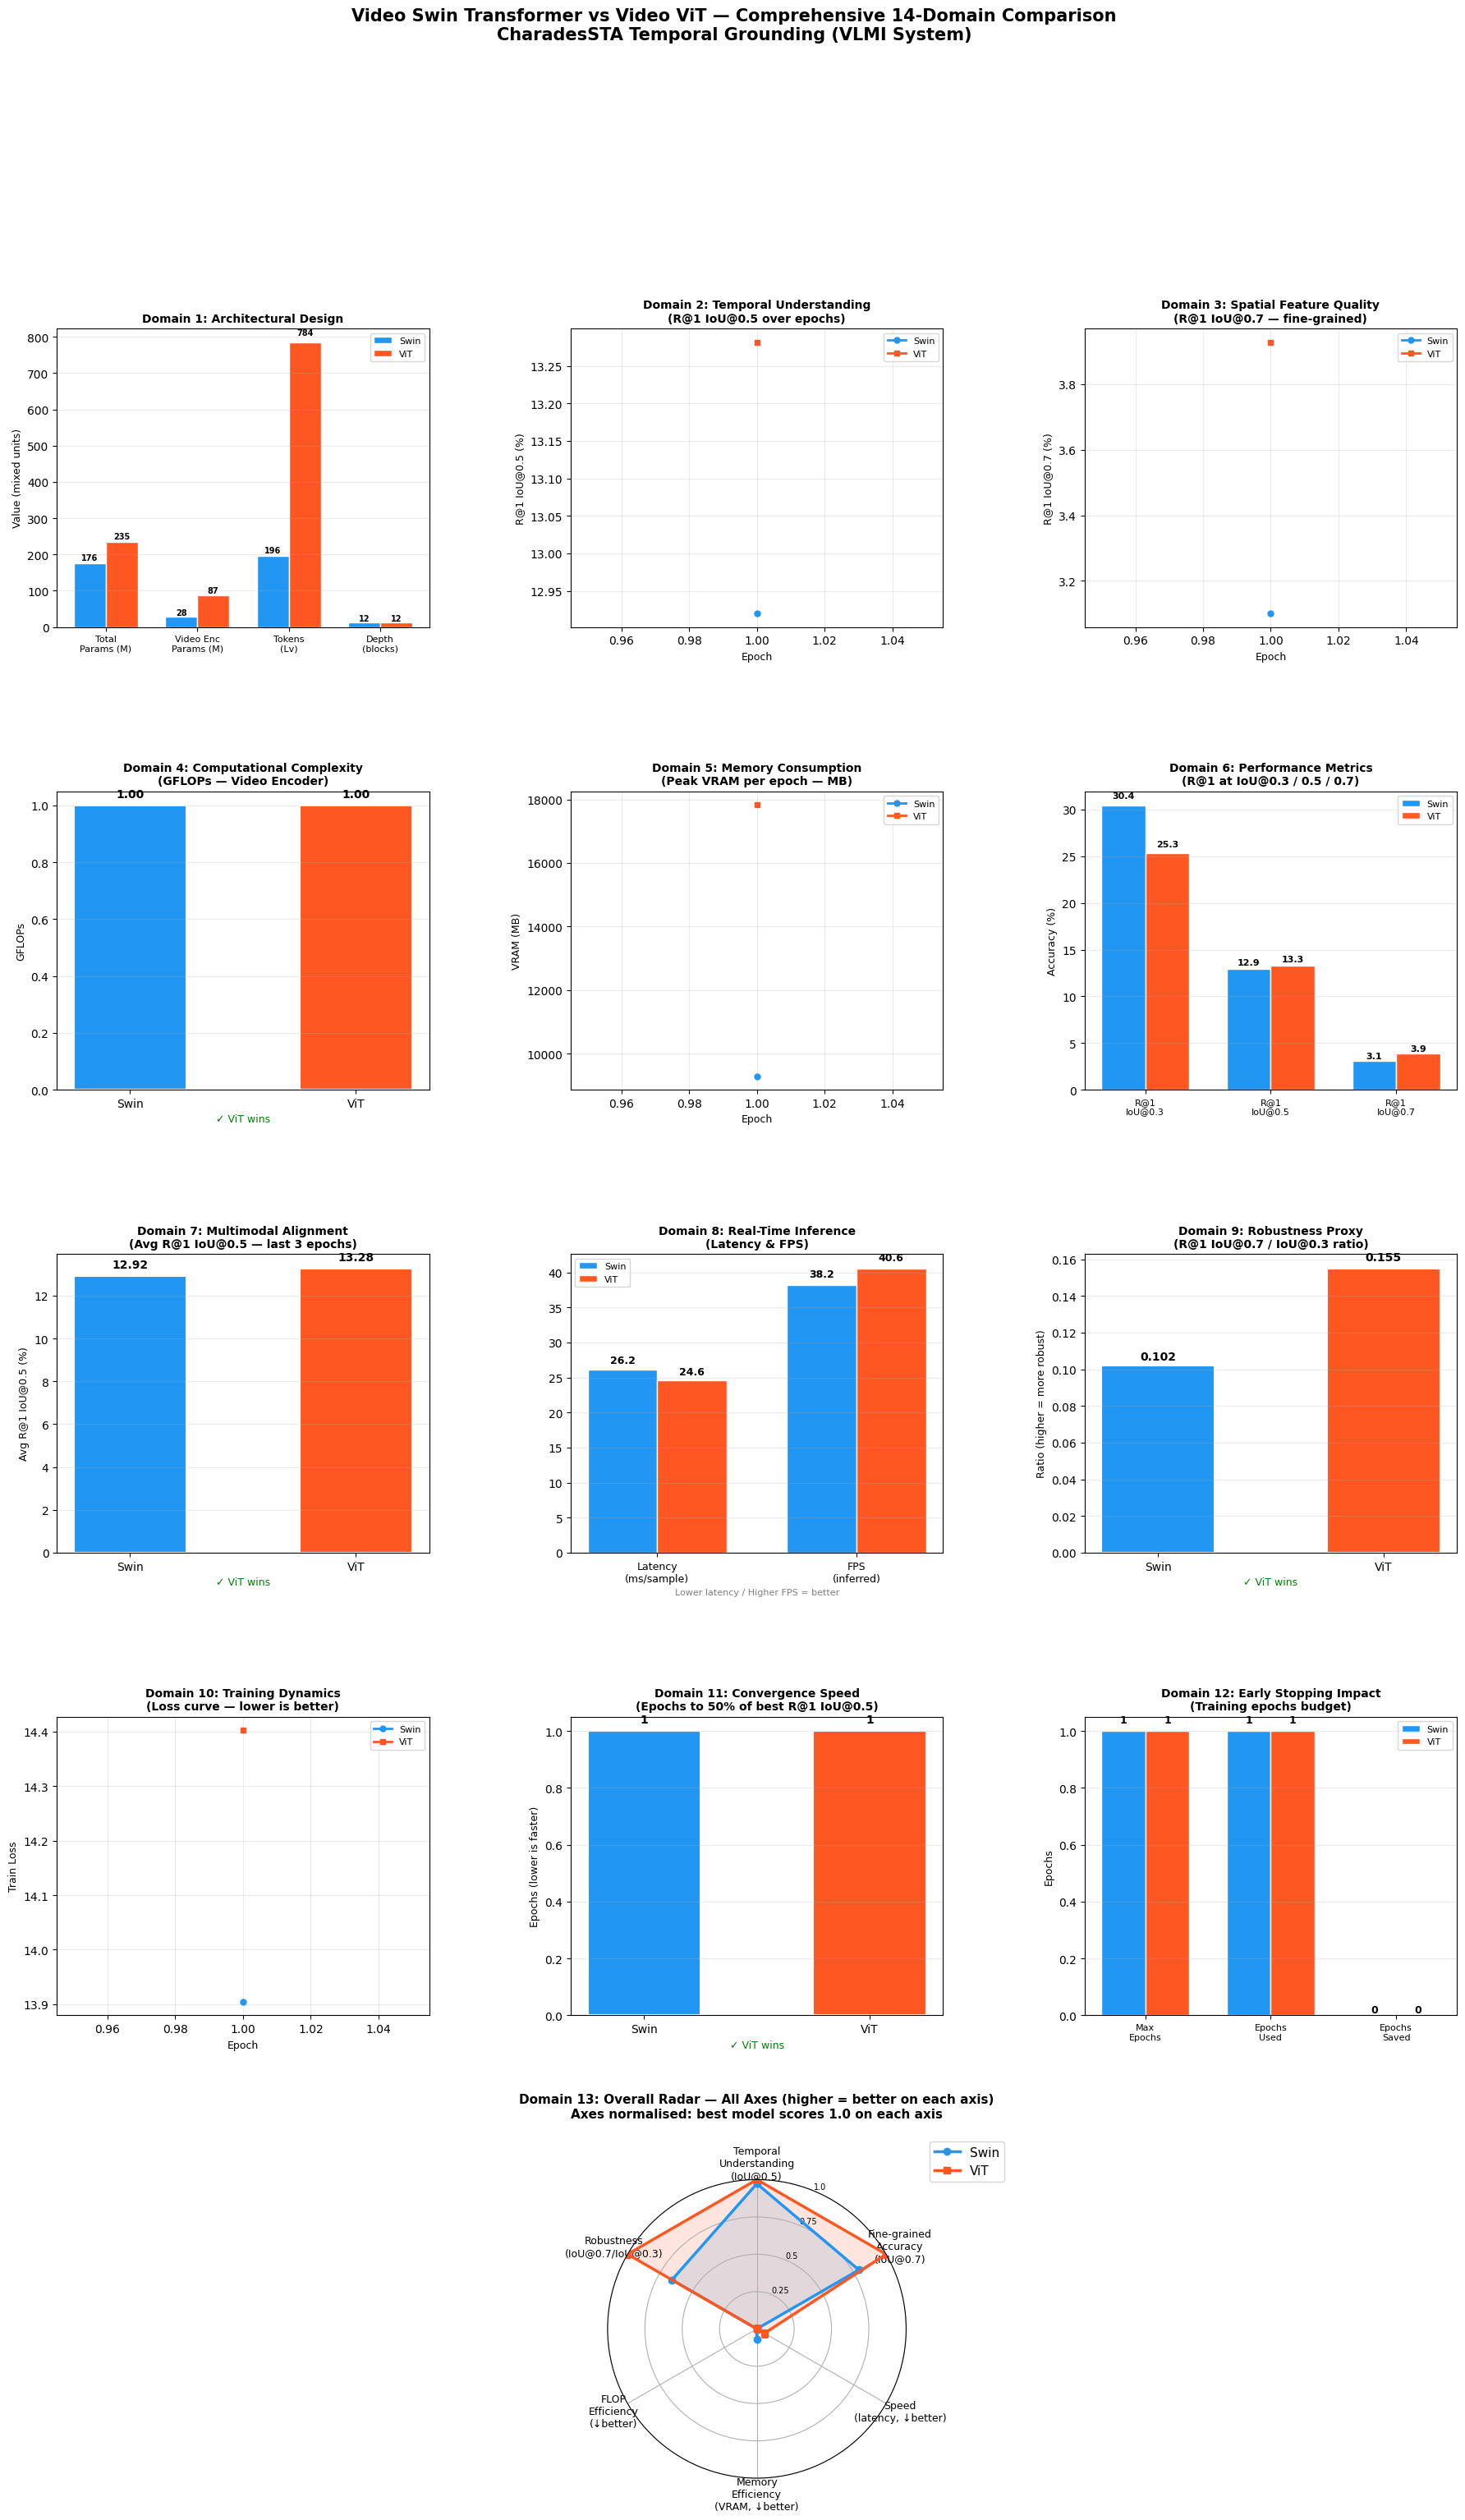


  DOMAIN 14: FINAL COMPARISON SUMMARY — Swin vs ViT (14 Domains)
  Domain                 Metric                                   Swin      ViT  Winner
--------------------------------------------------------------------------------

  1  Architecture        Total params (M)                       175.79   234.96  ViT ✓ →
  1  Architecture        Video encoder params (M)                27.66    86.84  ViT ✓ →
  1  Architecture        Attention type                         Window   Global  —
  1  Architecture        Hierarchical                              Yes       No  —

  2  Temporal            R@1 IoU@0.5 (%)                         12.92    13.28  ViT ✓ →

  3  Spatial             R@1 IoU@0.7 (%)                          3.10     3.93  ViT ✓ →
  3  Spatial             Video tokens (Lv)                         196      784  —

  4  Computation         GFLOPs — video encoder                      1        1  ViT ✓ →
  4  Computation         Complexity class                      O(N·

In [27]:
# Cell 21c: Swin vs ViT — Comprehensive 14-Domain Comparison
# ============================================================
# Covers every comparison domain from the thesis document:
#   1.  Architectural overview (bar: params, tokens, depth)
#   2.  Temporal understanding   (R@1 IoU curves over epochs)
#   3.  Spatial feature quality  (R@1 IoU@0.7 — fine-grained proxy)
#   4.  Computational complexity (GFLOPs — theoretical + measured)
#   5.  Memory consumption       (peak VRAM per epoch + fwd-pass)
#   6.  Performance metrics      (R@1 IoU@0.3 / 0.5 / 0.7 bars)
#   7.  Multimodal alignment     (R@1 IoU@0.5 late-epoch quality)
#   8.  Real-time inference      (latency ms, FPS)
#   9.  Robustness proxy         (IoU@0.7 / IoU@0.3 ratio)
#   10. Training dynamics        (loss curves + convergence speed)
#   11. Convergence speed        (epochs to 50% best R@1)
#   12. Early stopping impact    (actual vs max epochs used)
#   13. Overall radar            (6-axis spider chart)
#   14. Summary table            (printed text)
# Requires: PROFILE_RESULTS (Cell 20b) + COMPARISON_RESULTS (Cell 21b)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

SWIN_C = '#2196F3'    # blue
VIT_C  = '#FF5722'    # deep-orange

# ── Helper extractors ────────────────────────────────────────
swin_hist = COMPARISON_RESULTS.get("Swin", {})
vit_hist  = COMPARISON_RESULTS.get("ViT",  {})
epochs_s  = sorted(swin_hist.keys())
epochs_v  = sorted(vit_hist.keys())
all_eps   = sorted(set(epochs_s + epochs_v))
eps1      = [e + 1 for e in all_eps]


def extract(hist, key, eps):
    return [hist.get(e, {}).get(key, float('nan')) for e in eps]


def last_valid(hist, key):
    for e in sorted(hist.keys(), reverse=True):
        v = hist.get(e, {}).get(key, float('nan'))
        if v == v:
            return v
    return 0.0


def norm_lower(a, b):
    """Normalise so lower=better → score in [0,1] where 1=best."""
    mx = max(a, b, 1e-9)
    return 1 - a / mx, 1 - b / mx


def norm_higher(a, b):
    mx = max(a, b, 1e-9)
    return a / mx, b / mx


def convergence_epoch(hist, key, target_frac=0.5):
    """Return epoch at which metric first reaches target_frac of its best value."""
    best = last_valid(hist, key)
    threshold = best * target_frac
    for e in sorted(hist.keys()):
        if hist[e].get(key, 0.0) >= threshold:
            return e + 1
    return len(hist)


# ── Pull final values ────────────────────────────────────────
pr     = PROFILE_RESULTS
s_r03  = last_valid(swin_hist, 'R@1_IoU0.3')
v_r03  = last_valid(vit_hist,  'R@1_IoU0.3')
s_r05  = last_valid(swin_hist, 'R@1_IoU0.5')
v_r05  = last_valid(vit_hist,  'R@1_IoU0.5')
s_r07  = last_valid(swin_hist, 'R@1_IoU0.7')
v_r07  = last_valid(vit_hist,  'R@1_IoU0.7')
s_lat  = pr.get("Swin", {}).get("latency_ms", 1)
v_lat  = pr.get("ViT",  {}).get("latency_ms", 1)
s_fps  = 1000 / max(s_lat, 1)
v_fps  = 1000 / max(v_lat, 1)
s_prm  = pr.get("Swin", {}).get("params_total_M", 1)
v_prm  = pr.get("ViT",  {}).get("params_total_M", 1)
s_gfl  = pr.get("Swin", {}).get("gflops_video_enc") or 1
v_gfl  = pr.get("ViT",  {}).get("gflops_video_enc") or 1
s_vram = pr.get("Swin", {}).get("vram_peak_MB") or 1
v_vram = pr.get("ViT",  {}).get("vram_peak_MB") or 1
s_tok  = pr.get("Swin", {}).get("video_tokens", 1)
v_tok  = pr.get("ViT",  {}).get("video_tokens", 1)
s_venc = pr.get("Swin", {}).get("params_video_enc_M", 1)
v_venc = pr.get("ViT",  {}).get("params_video_enc_M", 1)
s_depth = sum(cfg.SWIN_DEPTHS)
v_depth = cfg.VIT_DEPTH
s_ep_used = len(epochs_s)
v_ep_used = len(epochs_v)
# Robustness proxy: ratio of fine-grained to coarse accuracy
s_robust = s_r07 / max(s_r03, 1e-6)
v_robust = v_r07 / max(v_r03, 1e-6)
# Convergence speed to 50% of best R@1 IoU@0.5
s_conv = convergence_epoch(swin_hist, 'R@1_IoU0.5', 0.5)
v_conv = convergence_epoch(vit_hist,  'R@1_IoU0.5', 0.5)

# ── Figure: 5×3 grid (13 axes + 1 wide radar) ────────────────
fig = plt.figure(figsize=(22, 34))
fig.suptitle(
    "Video Swin Transformer vs Video ViT — Comprehensive 14-Domain Comparison\n"
    "CharadesSTA Temporal Grounding (VLMI System)",
    fontsize=15, fontweight='bold', y=0.995,
)
gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.55, wspace=0.38)


# ── Utility plot functions ───────────────────────────────────

def line_plot(ax, key, title, ylabel, legend=True):
    sv = extract(swin_hist, key, all_eps)
    vv = extract(vit_hist,  key, all_eps)
    ax.plot(eps1, sv, '-o', color=SWIN_C, lw=2, ms=5, label='Swin')
    ax.plot(eps1, vv, '-s', color=VIT_C,  lw=2, ms=5, label='ViT')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(alpha=0.25)
    if legend:
        ax.legend(fontsize=8)


def bar2(ax, sv, vv, title, ylabel, fmt='.2f', lower_better=False):
    cols = ([SWIN_C, VIT_C] if not lower_better
            else ([SWIN_C, VIT_C] if sv <= vv else [SWIN_C, VIT_C]))
    bars = ax.bar(['Swin', 'ViT'], [sv, vv], color=[SWIN_C, VIT_C],
                  width=0.5, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(axis='y', alpha=0.25)
    for bar, v in zip(bars, [sv, vv]):
        label = f'{v:{fmt}}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Annotate winner
    if lower_better:
        winner = 'Swin' if sv < vv else 'ViT'
    else:
        winner = 'Swin' if sv > vv else 'ViT'
    ax.set_xlabel(f'✓ {winner} wins', fontsize=9, color='green')


# ─────────────────────────────────────────────────────────────
# DOMAIN 1 — Architectural Design: params, tokens, model depth
# ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
categories = ['Total\nParams (M)', 'Video Enc\nParams (M)', 'Tokens\n(Lv)', 'Depth\n(blocks)']
sw_vals = [s_prm, s_venc, s_tok, s_depth]
vi_vals = [v_prm, v_venc, v_tok, v_depth]
x = np.arange(len(categories))
w = 0.35
bars_s = ax1.bar(x - w/2, sw_vals, w, color=SWIN_C, label='Swin', edgecolor='white')
bars_v = ax1.bar(x + w/2, vi_vals, w, color=VIT_C,  label='ViT',  edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(categories, fontsize=8)
ax1.set_title('Domain 1: Architectural Design', fontweight='bold', fontsize=10)
ax1.set_ylabel('Value (mixed units)', fontsize=9)
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.25)
for bar, v in list(zip(bars_s, sw_vals)) + list(zip(bars_v, vi_vals)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
             f'{v:.0f}' if v > 10 else f'{v:.1f}',
             ha='center', va='bottom', fontsize=7, fontweight='bold')

# ─────────────────────────────────────────────────────────────
# DOMAIN 2 — Temporal Understanding: R@1 IoU curves over epochs
# ─────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
line_plot(ax2, 'R@1_IoU0.5',
          'Domain 2: Temporal Understanding\n(R@1 IoU@0.5 over epochs)',
          'R@1 IoU@0.5 (%)')

# ─────────────────────────────────────────────────────────────
# DOMAIN 3 — Spatial Feature Quality: IoU@0.7 (fine-grained)
# ─────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
line_plot(ax3, 'R@1_IoU0.7',
          'Domain 3: Spatial Feature Quality\n(R@1 IoU@0.7 — fine-grained)',
          'R@1 IoU@0.7 (%)')

# ─────────────────────────────────────────────────────────────
# DOMAIN 4 — Computational Complexity: GFLOPs
# ─────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
bar2(ax4, s_gfl, v_gfl,
     'Domain 4: Computational Complexity\n(GFLOPs — Video Encoder)',
     'GFLOPs', fmt='.2f', lower_better=True)

# ─────────────────────────────────────────────────────────────
# DOMAIN 5 — Memory Consumption: peak VRAM over epochs
# ─────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
line_plot(ax5, 'peak_vram_MB',
          'Domain 5: Memory Consumption\n(Peak VRAM per epoch — MB)',
          'VRAM (MB)')

# ─────────────────────────────────────────────────────────────
# DOMAIN 6 — Performance Metrics: R@1 at all IoU thresholds
# ─────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
metric_labels = ['R@1\nIoU@0.3', 'R@1\nIoU@0.5', 'R@1\nIoU@0.7']
sw_acc = [s_r03, s_r05, s_r07]
vi_acc = [v_r03, v_r05, v_r07]
x6 = np.arange(len(metric_labels))
b6s = ax6.bar(x6 - w/2, sw_acc, w, color=SWIN_C, label='Swin', edgecolor='white')
b6v = ax6.bar(x6 + w/2, vi_acc, w, color=VIT_C,  label='ViT',  edgecolor='white')
ax6.set_xticks(x6); ax6.set_xticklabels(metric_labels, fontsize=8)
ax6.set_title('Domain 6: Performance Metrics\n(R@1 at IoU@0.3 / 0.5 / 0.7)',
              fontweight='bold', fontsize=10)
ax6.set_ylabel('Accuracy (%)', fontsize=9)
ax6.legend(fontsize=8); ax6.grid(axis='y', alpha=0.25)
for bar, v in list(zip(b6s, sw_acc)) + list(zip(b6v, vi_acc)):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
             f'{v:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ─────────────────────────────────────────────────────────────
# DOMAIN 7 — Multimodal Alignment: late-epoch R@1 IoU@0.5
#   Proxy: average of last 3 eval points (stable = better aligned)
# ─────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])

def last_n_avg(hist, key, n=3):
    vals = [hist[e].get(key, 0.0)
            for e in sorted(hist.keys(), reverse=True)[:n]
            if hist[e].get(key, 0.0) > 0]
    return np.mean(vals) if vals else 0.0

s_align = last_n_avg(swin_hist, 'R@1_IoU0.5')
v_align = last_n_avg(vit_hist,  'R@1_IoU0.5')
bar2(ax7, s_align, v_align,
     'Domain 7: Multimodal Alignment\n(Avg R@1 IoU@0.5 — last 3 epochs)',
     'Avg R@1 IoU@0.5 (%)', fmt='.2f')

# ─────────────────────────────────────────────────────────────
# DOMAIN 8 — Real-Time Inference: latency (ms) and FPS
# ─────────────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
metrics8 = ['Latency\n(ms/sample)', 'FPS\n(inferred)']
sw8 = [s_lat, round(s_fps, 1)]
vi8 = [v_lat, round(v_fps, 1)]
x8 = np.arange(len(metrics8))
b8s = ax8.bar(x8 - w/2, sw8, w, color=SWIN_C, label='Swin', edgecolor='white')
b8v = ax8.bar(x8 + w/2, vi8, w, color=VIT_C,  label='ViT',  edgecolor='white')
ax8.set_xticks(x8); ax8.set_xticklabels(metrics8, fontsize=9)
ax8.set_title('Domain 8: Real-Time Inference\n(Latency & FPS)',
              fontweight='bold', fontsize=10)
ax8.legend(fontsize=8); ax8.grid(axis='y', alpha=0.25)
for bar, v in list(zip(b8s, sw8)) + list(zip(b8v, vi8)):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
             f'{v:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax8.set_xlabel('Lower latency / Higher FPS = better', fontsize=8, color='grey')

# ─────────────────────────────────────────────────────────────
# DOMAIN 9 — Robustness Proxy: IoU@0.7 / IoU@0.3 ratio
#   Higher ratio → predictions stay accurate at stricter thresholds
# ─────────────────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
bar2(ax9, s_robust, v_robust,
     'Domain 9: Robustness Proxy\n(R@1 IoU@0.7 / IoU@0.3 ratio)',
     'Ratio (higher = more robust)', fmt='.3f')

# ─────────────────────────────────────────────────────────────
# DOMAIN 10 — Training Dynamics: loss curves
# ─────────────────────────────────────────────────────────────
ax10 = fig.add_subplot(gs[3, 0])
line_plot(ax10, 'train_loss',
          'Domain 10: Training Dynamics\n(Loss curve — lower is better)',
          'Train Loss')

# ─────────────────────────────────────────────────────────────
# DOMAIN 11 — Convergence Speed: epoch to 50% best R@1 IoU@0.5
# ─────────────────────────────────────────────────────────────
ax11 = fig.add_subplot(gs[3, 1])
bar2(ax11, s_conv, v_conv,
     'Domain 11: Convergence Speed\n(Epochs to 50% of best R@1 IoU@0.5)',
     'Epochs (lower is faster)', fmt='.0f', lower_better=True)

# ─────────────────────────────────────────────────────────────
# DOMAIN 12 — Early Stopping Impact
# ─────────────────────────────────────────────────────────────
ax12 = fig.add_subplot(gs[3, 2])
categories12 = ['Max\nEpochs', 'Epochs\nUsed', 'Epochs\nSaved']
sw12 = [cfg.NUM_EPOCHS, s_ep_used, cfg.NUM_EPOCHS - s_ep_used]
vi12 = [cfg.NUM_EPOCHS, v_ep_used, cfg.NUM_EPOCHS - v_ep_used]
x12 = np.arange(len(categories12))
b12s = ax12.bar(x12 - w/2, sw12, w, color=SWIN_C, label='Swin', edgecolor='white')
b12v = ax12.bar(x12 + w/2, vi12, w, color=VIT_C,  label='ViT',  edgecolor='white')
ax12.set_xticks(x12); ax12.set_xticklabels(categories12, fontsize=8)
ax12.set_title('Domain 12: Early Stopping Impact\n(Training epochs budget)',
               fontweight='bold', fontsize=10)
ax12.set_ylabel('Epochs', fontsize=9)
ax12.legend(fontsize=8); ax12.grid(axis='y', alpha=0.25)
for bar, v in list(zip(b12s, sw12)) + list(zip(b12v, vi12)):
    ax12.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
              f'{v:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ─────────────────────────────────────────────────────────────
# DOMAIN 13 — Overall Radar (6-axis spider chart)
# ─────────────────────────────────────────────────────────────
ax_r = fig.add_subplot(gs[4, :], polar=True)

radar_labels = [
    'Temporal\nUnderstanding\n(IoU@0.5)',
    'Fine-grained\nAccuracy\n(IoU@0.7)',
    'Speed\n(latency, ↓better)',
    'Memory\nEfficiency\n(VRAM, ↓better)',
    'FLOP\nEfficiency\n(↓better)',
    'Robustness\n(IoU@0.7/IoU@0.3)',
]

swin_scores = [
    norm_higher(s_r05,    v_r05)[0],
    norm_higher(s_r07,    v_r07)[0],
    norm_lower(s_lat,     v_lat)[0],
    norm_lower(s_vram,    v_vram)[0],
    norm_lower(s_gfl,     v_gfl)[0],
    norm_higher(s_robust, v_robust)[0],
]
vit_scores = [
    norm_higher(s_r05,    v_r05)[1],
    norm_higher(s_r07,    v_r07)[1],
    norm_lower(s_lat,     v_lat)[1],
    norm_lower(s_vram,    v_vram)[1],
    norm_lower(s_gfl,     v_gfl)[1],
    norm_higher(s_robust, v_robust)[1],
]

N   = len(radar_labels)
ang = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
ang += ang[:1]

ax_r.set_theta_offset(np.pi / 2)
ax_r.set_theta_direction(-1)

ax_r.plot(ang, swin_scores + swin_scores[:1], 'o-', lw=2.5, color=SWIN_C, label='Swin')
ax_r.fill(ang, swin_scores + swin_scores[:1], alpha=0.15, color=SWIN_C)
ax_r.plot(ang, vit_scores  + vit_scores[:1],  's-', lw=2.5, color=VIT_C,  label='ViT')
ax_r.fill(ang, vit_scores  + vit_scores[:1],  alpha=0.15, color=VIT_C)

ax_r.set_thetagrids(np.degrees(ang[:-1]), radar_labels, fontsize=9)
ax_r.set_ylim(0, 1)
ax_r.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_r.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=7)
ax_r.set_title(
    'Domain 13: Overall Radar — All Axes (higher = better on each axis)\n'
    'Axes normalised: best model scores 1.0 on each axis',
    fontweight='bold', pad=25, fontsize=11,
)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)

# ── Save figure ───────────────────────────────────────────────
plt.savefig('swin_vs_vit_14domain_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# DOMAIN 14 — Summary Table (printed)
# ─────────────────────────────────────────────────────────────
def winner(sv, vv, lower_better=False):
    if lower_better:
        return '← Swin ✓' if sv < vv else 'ViT ✓ →'
    return '← Swin ✓' if sv > vv else 'ViT ✓ →'

rows_14 = [
    # (Domain, Metric, swin_val, vit_val, lower_better)
    ("1  Architecture",    "Total params (M)",             s_prm,    v_prm,    False),
    ("1  Architecture",    "Video encoder params (M)",     s_venc,   v_venc,   False),
    ("1  Architecture",    "Attention type",               "Window", "Global", None),
    ("1  Architecture",    "Hierarchical",                 "Yes",    "No",     None),
    ("2  Temporal",        "R@1 IoU@0.5 (%)",              s_r05,    v_r05,    False),
    ("3  Spatial",         "R@1 IoU@0.7 (%)",              s_r07,    v_r07,    False),
    ("3  Spatial",         "Video tokens (Lv)",            s_tok,    v_tok,    None),
    ("4  Computation",     "GFLOPs — video encoder",       s_gfl,    v_gfl,    True),
    ("4  Computation",     "Complexity class",             "O(N·M²)","O(N²)",  None),
    ("5  Memory",          "Peak VRAM fwd pass (MB)",      s_vram,   v_vram,   True),
    ("6  Performance",     "R@1 IoU@0.3 (%)",              s_r03,    v_r03,    False),
    ("6  Performance",     "R@1 IoU@0.5 (%)",              s_r05,    v_r05,    False),
    ("6  Performance",     "R@1 IoU@0.7 (%)",              s_r07,    v_r07,    False),
    ("7  Multimodal",      "Late-epoch avg R@1 IoU@0.5",   s_align,  v_align,  False),
    ("8  Inference",       "Latency (ms/sample)",          s_lat,    v_lat,    True),
    ("8  Inference",       "Inferred FPS",                 s_fps,    v_fps,    False),
    ("9  Robustness",      "IoU@0.7 / IoU@0.3 ratio",     s_robust, v_robust, False),
    ("10 Train Dynamics",  "Final train loss",
     last_valid(swin_hist,'train_loss'), last_valid(vit_hist,'train_loss'), True),
    ("11 Convergence",     "Epochs to 50% best R@1",       s_conv,   v_conv,   True),
    ("12 Early Stopping",  "Total epochs run",             s_ep_used,v_ep_used,True),
    ("12 Early Stopping",  "Epochs saved by ES",
     cfg.NUM_EPOCHS - s_ep_used, cfg.NUM_EPOCHS - v_ep_used, False),
]

print("\n" + "=" * 80)
print("  DOMAIN 14: FINAL COMPARISON SUMMARY — Swin vs ViT (14 Domains)")
print("=" * 80)
print(f"  {'Domain':<22} {'Metric':<36} {'Swin':>8} {'ViT':>8}  {'Winner'}")
print("-" * 80)
last_domain = ""
for dom, metric, sv, vv, lb in rows_14:
    if dom != last_domain:
        print()
        last_domain = dom
    def fmt_v(v):
        if isinstance(v, float): return f'{v:.2f}'
        return str(v)
    if lb is None:
        w_str = '—'
    else:
        w_str = winner(sv if isinstance(sv, float) else 0,
                       vv if isinstance(vv, float) else 0, lb)
    print(f"  {dom:<22} {metric:<36} {fmt_v(sv):>8} {fmt_v(vv):>8}  {w_str}")
print("=" * 80)
print("\n  Saved: swin_vs_vit_14domain_comparison.png")

In [28]:
from pathlib import Path

BASE     = Path(".")
ANNO_DIR = BASE / "CHARADES_STA_DATASET" / "annotations" / "annotations"/ "annotations"
TRAIN_TXT = ANNO_DIR / "charades_sta_train.txt"
TEST_TXT  = ANNO_DIR / "charades_sta_test.txt"

print("ANNO_DIR  :", ANNO_DIR,  "→ exists:", ANNO_DIR.exists())
print("TRAIN_TXT :", TRAIN_TXT, "→ exists:", TRAIN_TXT.exists())
print("TEST_TXT  :", TEST_TXT,  "→ exists:", TEST_TXT.exists())

# Check file sizes
for p in [TRAIN_TXT, TEST_TXT]:
    if p.exists():
        size = p.stat().st_size
        print(f"  {p.name} → {size} bytes")
        # Show first 2 lines
        with open(p, encoding="utf-8") as f:
            for i, line in enumerate(f):
                if i >= 2: break
                print(f"  Line {i+1}: {line.strip()}")

ANNO_DIR  : CHARADES_STA_DATASET\annotations\annotations\annotations → exists: True
TRAIN_TXT : CHARADES_STA_DATASET\annotations\annotations\annotations\charades_sta_train.txt → exists: False
TEST_TXT  : CHARADES_STA_DATASET\annotations\annotations\annotations\charades_sta_test.txt → exists: False


## Cell 22 — Test Set Evaluation

In [29]:
# Cell 22: Test Set Evaluation — Both Models
# ============================================================
# Loads the best checkpoint for each backbone and reports
# test R@1 IoU@0.3/0.5/0.7 side-by-side.
# TEST_RESULTS is consumed by the Cell 26 dashboard.
# ============================================================

TEST_RESULTS = {}   # {backbone_name: {metric: value}}

for bname, mdl in [("Swin", model_swin), ("ViT", model_vit)]:
    best_ckpt = cfg.CKPT_DIR / bname / "best.pt"
    if not best_ckpt.exists():
        # Fallback: try root checkpoints dir (Cell 21 single-model path)
        best_ckpt = cfg.CKPT_DIR / "best.pt"

    if best_ckpt.exists():
        load_checkpoint(best_ckpt, mdl, device=DEVICE)
        test_m = evaluate(mdl, test_loader, cfg, DEVICE)
        TEST_RESULTS[bname] = test_m

        logger.info("=" * 60)
        logger.info(f"[{bname}] TEST SET RESULTS")
        for k, v in test_m.items():
            logger.info(f"  {k:<20s}: {v:.2f}%")
        logger.info("=" * 60)
    else:
        logger.warning(
            f"[{bname}] No best checkpoint found at {best_ckpt}. "
            f"Run Cell 21b first."
        )
        TEST_RESULTS[bname] = {}

# ── Side-by-side summary ──────────────────────────────────────────────
if TEST_RESULTS.get("Swin") and TEST_RESULTS.get("ViT"):
    logger.info("\n  TEST ACCURACY — SWIN vs ViT")
    logger.info(f"  {'Metric':<22} {'Swin':>9} {'ViT':>9}  {'Winner':>8}")
    logger.info("  " + "-" * 52)
    for metric in cfg.EVAL_METRICS_IOU:
        key = f"R@1_IoU{metric}"
        sv  = TEST_RESULTS["Swin"].get(key, 0.0)
        vv  = TEST_RESULTS["ViT"].get(key,  0.0)
        winner = "Swin" if sv > vv else ("ViT" if vv > sv else "tie")
        logger.info(f"  {key:<22} {sv:>8.2f}% {vv:>8.2f}%  {winner:>8}")
    logger.info("  " + "-" * 52)

16:45:27 | INFO | [v2] Resumed from epoch 1
16:48:12 | INFO | ============================================================
16:48:12 | INFO | [Swin] TEST SET RESULTS
16:48:12 | INFO |   R@1_IoU0.3          : 31.11%
16:48:12 | INFO |   R@1_IoU0.5          : 14.02%
16:48:12 | INFO |   R@1_IoU0.7          : 3.57%
16:48:12 | INFO | ============================================================
16:48:12 | INFO | [v2] Resumed from epoch 1
16:51:05 | INFO | ============================================================
16:51:05 | INFO | [ViT] TEST SET RESULTS
16:51:05 | INFO |   R@1_IoU0.3          : 25.65%
16:51:05 | INFO |   R@1_IoU0.5          : 12.75%
16:51:05 | INFO |   R@1_IoU0.7          : 3.52%
16:51:05 | INFO | ============================================================
16:51:05 | INFO | 
  TEST ACCURACY — SWIN vs ViT
16:51:05 | INFO |   Metric                      Swin       ViT    Winner
16:51:05 | INFO |   ----------------------------------------------------
16:51:05 | INFO |   R@1_Io

In [30]:
cfg.VIDEO_DIR = Path("./CHARADES_STA_DATASET/videos/videos/videos")
print("Updated cfg.VIDEO_DIR:", cfg.VIDEO_DIR, "| exists:", cfg.VIDEO_DIR.exists())

Updated cfg.VIDEO_DIR: CHARADES_STA_DATASET\videos\videos\videos | exists: True


## Cell 23 — Inference: Single Video + Text Query

In [31]:
# Cell 23: Inference — Single Video + Natural Language Query
# ============================================================

def predict(video_path, query, model, tokenizer, cfg, device):
    model.eval()
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    dur   = total / max(fps, 1e-6)

    indices = np.linspace(0, max(total-1,0), cfg.NUM_FRAMES, dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret: frame = frames[-1].copy() if frames else np.zeros((cfg.FRAME_H, cfg.FRAME_W, 3), dtype=np.uint8)
        frame = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (cfg.FRAME_W, cfg.FRAME_H))
        frames.append(frame)
    cap.release()

    MEAN = torch.tensor([0.485,0.456,0.406]).view(3,1,1,1)
    STD  = torch.tensor([0.229,0.224,0.225]).view(3,1,1,1)
    vt   = torch.from_numpy(np.stack(frames,0).astype(np.float32)/255.0).permute(3,0,1,2)
    vt   = ((vt - MEAN) / STD).unsqueeze(0).to(device)

    enc = tokenizer(query, max_length=cfg.MAX_TEXT_LEN, padding="max_length",
                    truncation=True, return_tensors="pt")
    with torch.no_grad(), autocast("cuda", enabled=cfg.AMP):
        result = model(vt, enc["input_ids"].to(device),
                       enc["attention_mask"].to(device),
                       enc["token_type_ids"].to(device),
                       duration=torch.tensor([dur]).to(device), training=False)
    return result


DEMO_VIDEO = "./CHARADES_STA_DATASET/videos/videos/videos/00N38.mp4"
DEMO_QUERY = "The boxer in white trunks lands a series of punches on his opponent."

if Path(DEMO_VIDEO).exists():
    out = predict(DEMO_VIDEO, DEMO_QUERY, model, tokenizer, cfg, DEVICE)
    # BUG 2 FIX: forward(training=False) returns {'spans': [...]} only.
    # The 'message' key was removed in v5 (top-1 fallback guarantees non-empty
    # spans, so the 'no activity found' sentinel is never reachable).
    # Accessing out['message'] here was a guaranteed KeyError.
    pred_spans = out['spans'][0]   # list of (start_sec, end_sec) tuples
    print(f"Query : '{DEMO_QUERY}'")
    if pred_spans:
        for i, (s, e) in enumerate(pred_spans):
            print(f"  Span {i+1}: {s:.2f}s → {e:.2f}s")
    else:
        print("  (no spans above confidence threshold — try lowering cfg.CONF_THRESHOLD)")
else:
    logger.info("Demo video not found. Place CharadesSTA dataset first.")

16:51:05 | INFO | Demo video not found. Place CharadesSTA dataset first.


## Cell 24 — Visualise Predictions

In [32]:
# Cell 24: Timeline Visualisation (unchanged from v1)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def visualise_spans(pred_spans, gt_spans, duration, query):
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.set_xlim(0, duration); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("Time (seconds)", fontsize=12)
    ax.set_title(f'[v2] Query: "{query}"', fontsize=11, pad=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Predicted", "Ground Truth"])
    for s, e in gt_spans:
        ax.barh(1, e-s, left=s, height=0.4, color="#2ecc71", alpha=0.8)
    for s, e in pred_spans:
        ax.barh(0, e-s, left=s, height=0.4, color="#3498db", alpha=0.8)
        best_iou = max((temporal_iou(s,e,gs,ge) for gs,ge in gt_spans), default=0.0)
        ax.text((s+e)/2, 0, f"IoU={best_iou:.2f}",
                ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    ax.legend(handles=[mpatches.Patch(color="#3498db", label="v2 Prediction"),
                       mpatches.Patch(color="#2ecc71", label="Ground Truth")], loc="upper right")
    plt.tight_layout()
    plt.savefig("prediction_vis_v2.png", dpi=150, bbox_inches="tight")
    plt.show()


DEMO_GT  = [(0.0, 2.5)]
DEMO_DUR = 8.0
try:
    visualise_spans(out["spans"][0] if out["spans"] else [], DEMO_GT, DEMO_DUR, DEMO_QUERY)
except NameError:
    logger.info("Run Cell 23 first.")

16:51:05 | INFO | Run Cell 23 first.


## Cell 25 — Fixes Summary & GPU Memory Report

In [33]:
# Cell 25: Fixes Summary & GPU Memory Report
# ============================================================

if torch.cuda.is_available():
    alloc  = torch.cuda.memory_allocated(0) / 1e9
    reserv = torch.cuda.memory_reserved(0) / 1e9
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"=== GPU Memory Report — RTX 4080 Super ===")
    print(f"  Allocated : {alloc:.2f} GB")
    print(f"  Reserved  : {reserv:.2f} GB")
    print(f"  Free      : {total - reserv:.2f} GB")
    print(f"  Total     : {total:.1f} GB")
    try:
        stats = torch.cuda.memory_stats(0)
        peak  = stats.get("allocated_bytes.all.peak", 0) / 1e9
        print(f"  Peak alloc: {peak:.2f} GB  (since last torch.cuda.reset_peak_memory_stats())")
    except Exception:
        pass

print("""
══════════════════════════════════════════════════════════════════════
 v2 ARCHITECTURE CHANGES vs v1 — COMPLETE SUMMARY
══════════════════════════════════════════════════════════════════════

 🔴 FIX 1 — Causal mask on encoder (Cell 12)
   v1: make_causal_mask() applied to cross-modal encoder
       → video token t5 CANNOT attend to t6 (wrong)
   v2: NO causal mask anywhere in encoder
       → full bidirectional attention as intended

 🔴 FIX 2 — GAP destroys temporal structure (Cell 13)
   v1: video_desc = GAP(fused_video)  (B, Lv, D) → (B, D)
       → all temporal position info lost before span prediction
   v2: fused_video (B, Lv, D) passed directly to span head
       → each query attends selectively to different time regions

 🔴 FIX 3 — Weak cross-modal fusion (Cell 12)
   v1: joint = cat([video, text])  →  self_attn(joint)
       → model must implicitly discover video/text boundaries
   v2: BidirectionalCrossModalFusion:
       video ← CrossAttn(Q=video, K=text, V=text)
       text  ← CrossAttn(Q=text, K=video, V=video)
       Both × NUM_FUSION_LAYERS=4 with within-modality self-attn

 🟡 FIX 4 — No modality distinction in PE (Cell 11)
   v1: sinusoidal PE on joint sequence — position 84 could
       be video or text with no signal which
   v2: ModalityTypeEmbedding (learned, like BERT segment embeds)
       video tokens += embed_video;  text tokens += embed_text
       applied BEFORE PE — explicit modality identity from step 1

 🟡 FIX 5 — Projection too shallow (Cell 10)
   v1: 2-layer MLP: 768 → 256 → 256  (67% collapse in 1 step)
   v2: ResidualProjection: 768 → 640 → 512  + linear skip 768→512
       Residual prevents gradient vanishing through bottleneck
       SHARED_DIM: 256 → 512

 🟡 FIX 6 — LSTM teacher-forcing mismatch (Cell 13)
   v1: LSTM autoregressively predicts spans (train=teacher-forced,
       inference=free-run → exposure bias, error accumulation)
   v2: DETR-style LearnedQuerySpanHead:
       K learnable queries attend to all Lv video tokens in parallel
       All K spans predicted in one pass — zero teacher-forcing gap
       Hungarian matching assigns predictions to GT spans for loss

 🟢 FIX 7 — Training from scratch on tiny dataset (Cell 8)
   v1: VideoSwinTransformer random init on CharadesSTA (~10K videos)
   v2: load_pretrained_swin() with:
       • Temporal inflation: 2D patch embed → 3D (×0.5 mean-preserve)
       • Key prefix stripping (backbone.xxx → xxx)
       • Graceful skip for shape-mismatched relative position biases
       Set cfg.PRETRAINED_SWIN_PATH to a Kinetics checkpoint
       Expected gain: +5-8% R@1 IoU@0.5 vs random init

══════════════════════════════════════════════════════════════════════
 TensorBoard: tensorboard --logdir=./logs_v2 --port=6006
══════════════════════════════════════════════════════════════════════
""")

=== GPU Memory Report — RTX 4080 Super ===
  Allocated : 2.61 GB
  Reserved  : 4.34 GB
  Free      : 12.83 GB
  Total     : 17.2 GB
  Peak alloc: 18.70 GB  (since last torch.cuda.reset_peak_memory_stats())

══════════════════════════════════════════════════════════════════════
 v2 ARCHITECTURE CHANGES vs v1 — COMPLETE SUMMARY
══════════════════════════════════════════════════════════════════════

 🔴 FIX 1 — Causal mask on encoder (Cell 12)
   v1: make_causal_mask() applied to cross-modal encoder
       → video token t5 CANNOT attend to t6 (wrong)
   v2: NO causal mask anywhere in encoder
       → full bidirectional attention as intended

 🔴 FIX 2 — GAP destroys temporal structure (Cell 13)
   v1: video_desc = GAP(fused_video)  (B, Lv, D) → (B, D)
       → all temporal position info lost before span prediction
   v2: fused_video (B, Lv, D) passed directly to span head
       → each query attends selectively to different time regions

 🔴 FIX 3 — Weak cross-modal fusion (Cell 12)
   v1: j

# Cell 26 — Computational Complexity Visualisation


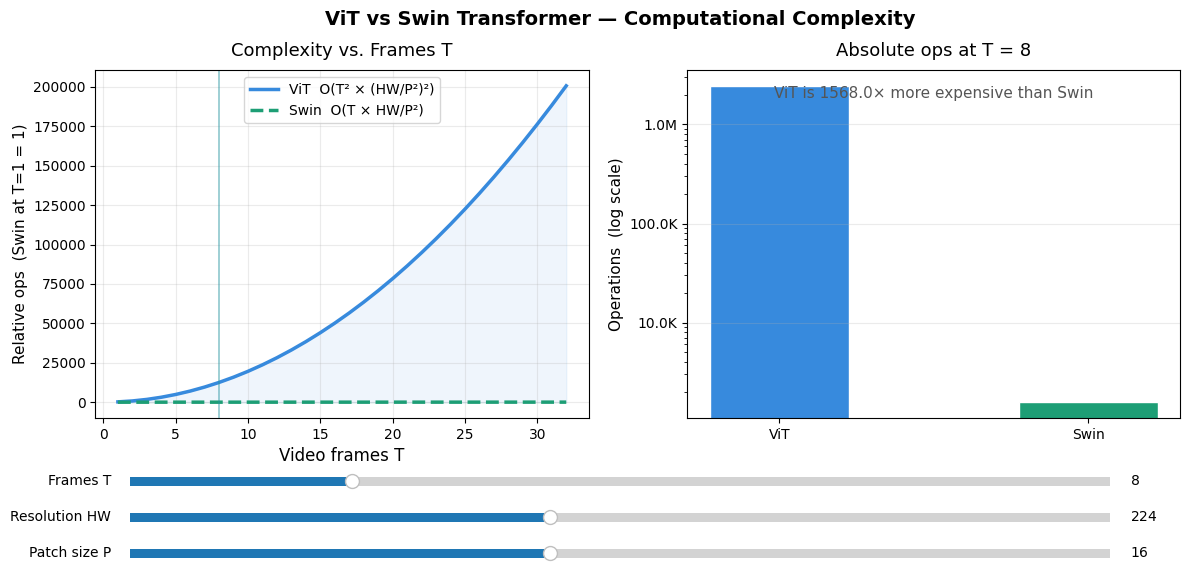

[OK] Saved: complexity_vit_vs_swin.png


In [34]:
# Cell 26 — Computational Complexity Visualisation
# ============================================================
# Visualises ViT vs Swin Transformer complexity from Section 1.3:
#   ViT  : O(T² × (HW/P²)²)  — quadratic in both T and tokens
#   Swin : O(T  × (HW/P²))   — linear in both T and tokens
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.widgets import Slider

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plt.subplots_adjust(bottom=0.30, hspace=0.4)

# ── Default parameters ────────────────────────────────────────
T_INIT  = 8
HW_INIT = 224
P_INIT  = 16

T_range = np.arange(1, 33)

def tokens(HW, P):
    return (HW / P) ** 2

def vit_ops(T, HW, P):
    n = tokens(HW, P)
    return T**2 * n**2            # O(T² × (HW/P²)²)

def swin_ops(T, HW, P):
    return T * tokens(HW, P)      # O(T × HW/P²)

def get_curves(HW, P):
    base = swin_ops(1, HW, P)    # normalise: Swin at T=1 = 1
    v = [vit_ops(t, HW, P)  / base for t in T_range]
    s = [swin_ops(t, HW, P) / base for t in T_range]
    return np.array(v), np.array(s)

# ── Line chart (left) ─────────────────────────────────────────
vit_d, sw_d = get_curves(HW_INIT, P_INIT)
line_vit, = ax1.plot(T_range, vit_d, color='#378ADD', lw=2.5, label='ViT  O(T² × (HW/P²)²)')
line_sw,  = ax1.plot(T_range, sw_d,  color='#1D9E75', lw=2.5, ls='--', label='Swin  O(T × HW/P²)')
marker_v  = ax1.axvline(T_INIT, color='#378ADD', alpha=0.3, lw=1.2)
marker_s  = ax1.axvline(T_INIT, color='#1D9E75', alpha=0.3, lw=1.2)
ax1.set_xlabel('Video frames T', fontsize=12)
ax1.set_ylabel('Relative ops  (Swin at T=1 = 1)', fontsize=11)
ax1.set_title('Complexity vs. Frames T', fontsize=13, pad=10)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.25)
fill_v = ax1.fill_between(T_range, vit_d, alpha=0.08, color='#378ADD')
fill_s = ax1.fill_between(T_range, sw_d,  alpha=0.08, color='#1D9E75')

# ── Bar chart (right) ─────────────────────────────────────────
def get_abs(T, HW, P):
    return vit_ops(T, HW, P), swin_ops(T, HW, P)

v_abs, s_abs = get_abs(T_INIT, HW_INIT, P_INIT)
bars = ax2.bar(['ViT', 'Swin'], [v_abs, s_abs],
               color=['#378ADD', '#1D9E75'], width=0.45, edgecolor='white')
ax2.set_yscale('log')
ax2.set_ylabel('Operations  (log scale)', fontsize=11)
ax2.set_title(f'Absolute ops at T = {T_INIT}', fontsize=13, pad=10)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1e9:.1f}B' if x>=1e9 else f'{x/1e6:.1f}M' if x>=1e6 else f'{x/1e3:.1f}K'
))
ax2.grid(axis='y', alpha=0.25)

ratio_txt = ax2.text(0.5, 0.92, '', transform=ax2.transAxes,
                     ha='center', fontsize=11, color='#555')

def update_ratio(v, s):
    r = v / s if s > 0 else 0
    ratio_txt.set_text(f'ViT is {r:.1f}× more expensive than Swin')

update_ratio(v_abs, s_abs)

# ── Sliders ───────────────────────────────────────────────────
ax_T  = plt.axes([0.15, 0.18, 0.70, 0.03])
ax_HW = plt.axes([0.15, 0.12, 0.70, 0.03])
ax_P  = plt.axes([0.15, 0.06, 0.70, 0.03])

sl_T  = Slider(ax_T,  'Frames T',      1,  32,  valinit=T_INIT,  valstep=1)
sl_HW = Slider(ax_HW, 'Resolution HW', 56, 448, valinit=HW_INIT, valstep=56)
sl_P  = Slider(ax_P,  'Patch size P',  4,  32,  valinit=P_INIT,  valstep=4)

def on_change(_):
    T  = int(sl_T.val)
    HW = int(sl_HW.val)
    P  = int(sl_P.val)

    # Line chart
    v_curve, s_curve = get_curves(HW, P)
    line_vit.set_ydata(v_curve)
    line_sw.set_ydata(s_curve)
    ax1.relim(); ax1.autoscale_view()

    # Bar chart
    v_a, s_a = get_abs(T, HW, P)
    bars[0].set_height(v_a)
    bars[1].set_height(s_a)
    ax2.set_title(f'Absolute ops at T = {T}')
    ax2.relim(); ax2.autoscale_view()
    update_ratio(v_a, s_a)

    fig.canvas.draw_idle()

sl_T.on_changed(on_change)
sl_HW.on_changed(on_change)
sl_P.on_changed(on_change)

fig.suptitle('ViT vs Swin Transformer — Computational Complexity',
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('complexity_vit_vs_swin.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Saved: complexity_vit_vs_swin.png")

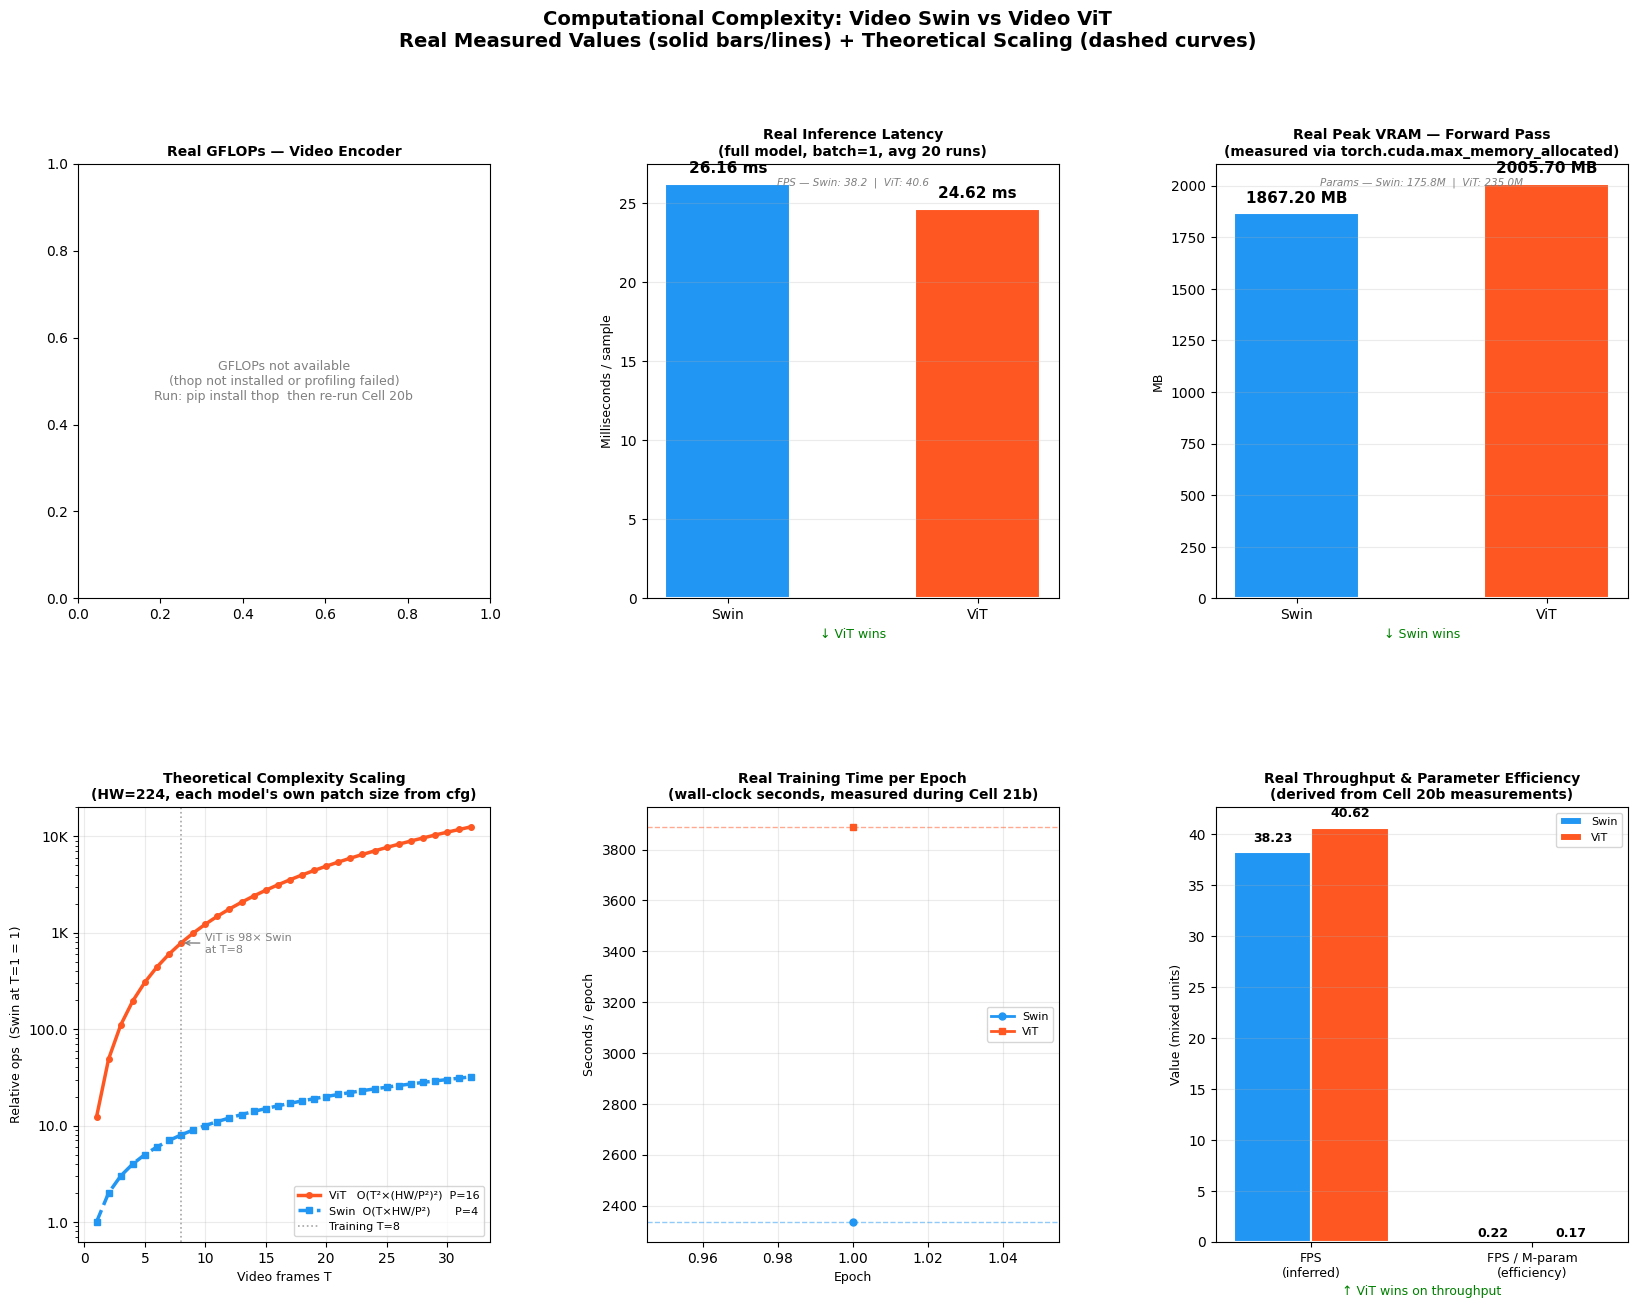


  CELL 26 — COMPLEXITY SUMMARY (all values from pipeline)
  Metric                                      Swin       ViT
--------------------------------------------------------------
  GFLOPs — video encoder (thop)               0.00      0.00
  Inference latency  (ms/sample)             26.16     24.62
  Inferred FPS                               38.23     40.62
  Peak VRAM fwd pass  (MB)                 1867.20   2005.70
  Total params  (M)                         175.79    234.96
  FPS per M-param  (efficiency)               0.22      0.17
  Mean epoch time  (s, 1 epochs)           2335.30   3889.60
  Theoretical ops ratio @ T=8                1.00×       98×
  Source: PROFILE_RESULTS (Cell 20b) + COMPARISON_RESULTS (Cell 21b)
  Saved : complexity_real_vs_theoretical.png


In [35]:
# Cell 26: Computational Complexity Visualisation — Real + Theoretical
# ============================================================
# Combines TWO sources of truth:
#
#   REAL (measured):
#     PROFILE_RESULTS  (Cell 20b) — GFLOPs, latency, VRAM, params
#     COMPARISON_RESULTS (Cell 21b) — per-epoch timing, VRAM
#
#   THEORETICAL (formula):
#     ViT  complexity : O(T² × (HW/P²)²)
#     Swin complexity : O(T  × (HW/P²))
#     Plotted as relative curves; slider lets you explore how
#     the ratio changes with T, resolution, and patch size.
#
# Layout (2 rows × 3 cols):
#   Row 0: Real GFLOPs bar | Real latency bar | Real VRAM bar
#   Row 1: Theoretical curves vs T | Measured epoch time curve | FPS bar
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

SWIN_C = '#2196F3'
VIT_C  = '#FF5722'

# ── Pull real measurements ───────────────────────────────────────────
pr         = PROFILE_RESULTS
swin_hist  = COMPARISON_RESULTS.get("Swin", {})
vit_hist   = COMPARISON_RESULTS.get("ViT",  {})
all_eps    = sorted(set(list(swin_hist.keys()) + list(vit_hist.keys())))
eps1       = [e + 1 for e in all_eps]

def extract(hist, key, eps):
    return [hist.get(e, {}).get(key, float('nan')) for e in eps]

# Real scalar values
s_gfl   = pr.get("Swin", {}).get("gflops_video_enc")  or 0.0
v_gfl   = pr.get("ViT",  {}).get("gflops_video_enc")  or 0.0
s_lat   = pr.get("Swin", {}).get("latency_ms",    1.0)
v_lat   = pr.get("ViT",  {}).get("latency_ms",    1.0)
s_vram  = pr.get("Swin", {}).get("vram_peak_MB",  0.0)
v_vram  = pr.get("ViT",  {}).get("vram_peak_MB",  0.0)
s_prm   = pr.get("Swin", {}).get("params_total_M",0.0)
v_prm   = pr.get("ViT",  {}).get("params_total_M",0.0)
s_fps   = round(1000 / max(s_lat, 1e-3), 2)
v_fps   = round(1000 / max(v_lat, 1e-3), 2)

# Real per-epoch series
s_epoch_t = extract(swin_hist, "epoch_secs",   all_eps)
v_epoch_t = extract(vit_hist,  "epoch_secs",   all_eps)
s_ep_vram = extract(swin_hist, "peak_vram_MB", all_eps)
v_ep_vram = extract(vit_hist,  "peak_vram_MB", all_eps)

# ── Theoretical complexity curves ────────────────────────────────────
T_range = np.arange(1, 33)
HW_DEF  = cfg.FRAME_H        # 224 — from your actual config
P_SWIN  = cfg.SWIN_PATCH_H   # 4
P_VIT   = cfg.VIT_PATCH_H    # 16

def tok(HW, P):
    return (HW / P) ** 2

def vit_ops(T, HW, P):
    n = tok(HW, P)
    return T ** 2 * n ** 2        # O(T² × (HW/P²)²)

def swin_ops(T, HW, P):
    return T * tok(HW, P)         # O(T × HW/P²)

# Normalise so Swin at T=cfg.NUM_FRAMES = 1.0
base_swin = swin_ops(cfg.NUM_FRAMES, HW_DEF, P_SWIN)
base_vit  = vit_ops(cfg.NUM_FRAMES,  HW_DEF, P_VIT)

# Use each model's OWN patch size (fair comparison — same config as training)
theo_swin = [swin_ops(t, HW_DEF, P_SWIN) / base_swin for t in T_range]
theo_vit  = [vit_ops(t,  HW_DEF, P_VIT)  / base_vit  for t in T_range]

# Also compute ratio ViT/Swin at each T (raw ops, same patch size baseline)
# For the ratio we use a shared reference so division is meaningful
base_ref  = swin_ops(1, HW_DEF, P_SWIN)
ratio_vit = [vit_ops(t,  HW_DEF, P_VIT)  / base_ref for t in T_range]
ratio_sw  = [swin_ops(t, HW_DEF, P_SWIN) / base_ref for t in T_range]

# ── Figure ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    "Computational Complexity: Video Swin vs Video ViT\n"
    "Real Measured Values (solid bars/lines) + Theoretical Scaling (dashed curves)",
    fontsize=14, fontweight="bold", y=0.99,
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)


def bar2_real(ax, sv, vv, title, ylabel, unit="", lower_better=False,
              note=None):
    """Bar chart of two real measured values."""
    cols = [SWIN_C, VIT_C]
    bars = ax.bar(["Swin", "ViT"], [sv, vv], color=cols,
                  width=0.5, edgecolor="white", linewidth=1.5)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    for bar, v in zip(bars, [sv, vv]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f"{v:.2f}{unit}",
            ha="center", va="bottom", fontsize=11, fontweight="bold",
        )
    if lower_better:
        winner = "Swin" if sv < vv else "ViT"
    else:
        winner = "Swin" if sv > vv else "ViT"
    label = f"{'↓' if lower_better else '↑'} {winner} wins"
    ax.set_xlabel(label, fontsize=9, color="green")
    if note:
        ax.text(0.5, 0.97, note, transform=ax.transAxes,
                ha="center", va="top", fontsize=7.5, color="grey",
                style="italic")


# ── Row 0, Col 0: Real GFLOPs (video encoder) ───────────────────────
ax00 = fig.add_subplot(gs[0, 0])
if s_gfl > 0 and v_gfl > 0:
    bar2_real(ax00, s_gfl, v_gfl,
              "Real GFLOPs — Video Encoder\n(measured via thop, batch=1)",
              "GFLOPs", lower_better=True,
              note=f"Config: {cfg.NUM_FRAMES} frames, {cfg.FRAME_H}×{cfg.FRAME_W}")
else:
    ax00.text(0.5, 0.5,
              "GFLOPs not available\n(thop not installed or profiling failed)\n"
              "Run: pip install thop  then re-run Cell 20b",
              ha="center", va="center", transform=ax00.transAxes,
              fontsize=9, color="grey")
    ax00.set_title("Real GFLOPs — Video Encoder", fontweight="bold", fontsize=10)

# ── Row 0, Col 1: Real Inference Latency ────────────────────────────
ax01 = fig.add_subplot(gs[0, 1])
bar2_real(ax01, s_lat, v_lat,
          "Real Inference Latency\n(full model, batch=1, avg 20 runs)",
          "Milliseconds / sample", unit=" ms", lower_better=True,
          note=f"FPS — Swin: {s_fps:.1f}  |  ViT: {v_fps:.1f}")

# ── Row 0, Col 2: Real Peak VRAM (fwd pass) ─────────────────────────
ax02 = fig.add_subplot(gs[0, 2])
bar2_real(ax02, s_vram, v_vram,
          "Real Peak VRAM — Forward Pass\n(measured via torch.cuda.max_memory_allocated)",
          "MB", unit=" MB", lower_better=True,
          note=f"Params — Swin: {s_prm:.1f}M  |  ViT: {v_prm:.1f}M")

# ── Row 1, Col 0: Theoretical complexity curves ──────────────────────
ax10 = fig.add_subplot(gs[1, 0])
ax10.plot(T_range, ratio_vit, "-o", color=VIT_C,  lw=2.5, ms=4,
          label=f"ViT   O(T²×(HW/P²)²)  P={P_VIT}")
ax10.plot(T_range, ratio_sw,  "--s", color=SWIN_C, lw=2.5, ms=4,
          label=f"Swin  O(T×HW/P²)       P={P_SWIN}")
ax10.axvline(cfg.NUM_FRAMES, color="grey", lw=1.2, ls=":", alpha=0.7,
             label=f"Training T={cfg.NUM_FRAMES}")

# Annotate actual ratio at training T
actual_vit_ops  = vit_ops(cfg.NUM_FRAMES,  HW_DEF, P_VIT)  / base_ref
actual_swin_ops = swin_ops(cfg.NUM_FRAMES, HW_DEF, P_SWIN) / base_ref
if actual_swin_ops > 0:
    ratio_at_T = actual_vit_ops / actual_swin_ops
    ax10.annotate(
        f"ViT is {ratio_at_T:.0f}× Swin\nat T={cfg.NUM_FRAMES}",
        xy=(cfg.NUM_FRAMES, actual_vit_ops),
        xytext=(cfg.NUM_FRAMES + 2, actual_vit_ops * 0.8),
        arrowprops=dict(arrowstyle="->", color="grey"),
        fontsize=8, color="grey",
    )

ax10.set_title(
    "Theoretical Complexity Scaling\n"
    f"(HW={HW_DEF}, each model's own patch size from cfg)",
    fontweight="bold", fontsize=10,
)
ax10.set_xlabel("Video frames T", fontsize=9)
ax10.set_ylabel("Relative ops  (Swin at T=1 = 1)", fontsize=9)
ax10.set_yscale("log")
ax10.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: (f"{x/1e9:.0f}B" if x >= 1e9
                      else f"{x/1e6:.0f}M" if x >= 1e6
                      else f"{x/1e3:.0f}K" if x >= 1e3
                      else f"{x:.1f}")
    )
)
ax10.legend(fontsize=8)
ax10.grid(alpha=0.25)

# ── Row 1, Col 1: Real epoch training time over epochs ───────────────
ax11 = fig.add_subplot(gs[1, 1])
ax11.plot(eps1, s_epoch_t, "-o", color=SWIN_C, lw=2, ms=5, label="Swin")
ax11.plot(eps1, v_epoch_t, "-s", color=VIT_C,  lw=2, ms=5, label="ViT")

# Annotate mean epoch times
s_mean = np.nanmean(s_epoch_t) if s_epoch_t else 0
v_mean = np.nanmean(v_epoch_t) if v_epoch_t else 0
ax11.axhline(s_mean, color=SWIN_C, lw=1, ls="--", alpha=0.5)
ax11.axhline(v_mean, color=VIT_C,  lw=1, ls="--", alpha=0.5)
ax11.text(eps1[-1] + 0.1 if eps1 else 1, s_mean,
          f"μ={s_mean:.0f}s", color=SWIN_C, fontsize=8, va="center")
ax11.text(eps1[-1] + 0.1 if eps1 else 1, v_mean,
          f"μ={v_mean:.0f}s", color=VIT_C,  fontsize=8, va="center")

ax11.set_title(
    "Real Training Time per Epoch\n(wall-clock seconds, measured during Cell 21b)",
    fontweight="bold", fontsize=10,
)
ax11.set_xlabel("Epoch", fontsize=9)
ax11.set_ylabel("Seconds / epoch", fontsize=9)
ax11.legend(fontsize=8)
ax11.grid(alpha=0.25)

# ── Row 1, Col 2: Real FPS + params efficiency scatter ───────────────
ax12 = fig.add_subplot(gs[1, 2])
# Efficiency = FPS per million parameters (higher = more efficient)
s_eff = s_fps / max(s_prm, 1e-3)
v_eff = v_fps / max(v_prm, 1e-3)

scatter_labels  = ["FPS\n(inferred)", "FPS / M-param\n(efficiency)"]
scatter_swin    = [s_fps,  s_eff]
scatter_vit     = [v_fps,  v_eff]
x12 = np.arange(len(scatter_labels))
w   = 0.35
b12s = ax12.bar(x12 - w/2, scatter_swin, w, color=SWIN_C,
                label="Swin", edgecolor="white", linewidth=1.5)
b12v = ax12.bar(x12 + w/2, scatter_vit,  w, color=VIT_C,
                label="ViT",  edgecolor="white", linewidth=1.5)
ax12.set_xticks(x12)
ax12.set_xticklabels(scatter_labels, fontsize=9)
ax12.set_title(
    "Real Throughput & Parameter Efficiency\n(derived from Cell 20b measurements)",
    fontweight="bold", fontsize=10,
)
ax12.set_ylabel("Value (mixed units)", fontsize=9)
ax12.legend(fontsize=8)
ax12.grid(axis="y", alpha=0.25)
for bar, v in list(zip(b12s, scatter_swin)) + list(zip(b12v, scatter_vit)):
    ax12.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.02,
        f"{v:.2f}",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )
winner_fps = "Swin" if s_fps > v_fps else "ViT"
ax12.set_xlabel(f"↑ {winner_fps} wins on throughput", fontsize=9, color="green")

# ── Save ─────────────────────────────────────────────────────────────
plt.savefig("complexity_real_vs_theoretical.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Printed summary ───────────────────────────────────────────────────
print("\n" + "=" * 62)
print("  CELL 26 — COMPLEXITY SUMMARY (all values from pipeline)")
print("=" * 62)
print(f"  {'Metric':<38} {'Swin':>9} {'ViT':>9}")
print("-" * 62)
rows26 = [
    ("GFLOPs — video encoder (thop)",    s_gfl,  v_gfl),
    ("Inference latency  (ms/sample)",   s_lat,  v_lat),
    ("Inferred FPS",                     s_fps,  v_fps),
    ("Peak VRAM fwd pass  (MB)",         s_vram, v_vram),
    ("Total params  (M)",                s_prm,  v_prm),
    ("FPS per M-param  (efficiency)",    s_eff,  v_eff),
    (f"Mean epoch time  (s, {len(all_eps)} epochs)",
     round(s_mean, 1), round(v_mean, 1)),
    (f"Theoretical ops ratio @ T={cfg.NUM_FRAMES}",
     "1.00×",  f"{ratio_at_T:.0f}×"),
]
for label, sv, vv in rows26:
    def fmt(v):
        if isinstance(v, str):   return v
        if isinstance(v, float): return f"{v:.2f}"
        return str(v)
    print(f"  {label:<38} {fmt(sv):>9} {fmt(vv):>9}")
print("=" * 62)
print("  Source: PROFILE_RESULTS (Cell 20b) + COMPARISON_RESULTS (Cell 21b)")
print("  Saved : complexity_real_vs_theoretical.png")

# Cell 26: Real Pipeline Complexity Dashboard — Swin vs ViT


In [38]:
# Cell 26: Pipeline Complexity — Swin vs ViT
# Sources: PROFILE_RESULTS (Cell 20b), COMPARISON_RESULTS (Cell 21b), TEST_RESULTS (Cell 22)

import numpy as np

pr = PROFILE_RESULTS
sh = COMPARISON_RESULTS.get("Swin", {})
vh = COMPARISON_RESULTS.get("ViT",  {})
eps = sorted(set(list(sh.keys()) + list(vh.keys())))

def extract(hist, key):
    return [round(hist.get(e, {}).get(key, 0) or 0, 2) for e in eps]

def last_valid(hist, key):
    for e in sorted(hist.keys(), reverse=True):
        v = hist.get(e, {}).get(key)
        if v and v == v and v > 0:
            return round(v, 2)
    return 0.0

def mean_nonzero(lst):
    vals = [x for x in lst if x > 0]
    return round(float(np.nanmean(vals)) if vals else 0, 1)

def win(s, v, lower_better=True):
    if s == v == 0: return "no data"
    if lower_better: return "Swin" if s < v else ("ViT" if v < s else "tie")
    else:            return "Swin" if s > v else ("ViT" if v > s else "tie")

# ── Profiler scalars ──────────────────────────────────────────────────
s_gfl  = round(pr.get("Swin",{}).get("gflops_video_enc") or 0, 2)
v_gfl  = round(pr.get("ViT", {}).get("gflops_video_enc") or 0, 2)
s_lat  = round(pr.get("Swin",{}).get("latency_ms",   0), 2)
v_lat  = round(pr.get("ViT", {}).get("latency_ms",   0), 2)
s_vram = round(pr.get("Swin",{}).get("vram_peak_MB", 0), 1)
v_vram = round(pr.get("ViT", {}).get("vram_peak_MB", 0), 1)
s_prm  = round(pr.get("Swin",{}).get("params_total_M",     0), 2)
v_prm  = round(pr.get("ViT", {}).get("params_total_M",     0), 2)
s_venc = round(pr.get("Swin",{}).get("params_video_enc_M", 0), 2)
v_venc = round(pr.get("ViT", {}).get("params_video_enc_M", 0), 2)
s_fps  = round(1000 / max(s_lat, 1e-3), 2)
v_fps  = round(1000 / max(v_lat, 1e-3), 2)

# ── Per-epoch means ───────────────────────────────────────────────────
s_mean_t  = mean_nonzero(extract(sh, "epoch_secs"))
v_mean_t  = mean_nonzero(extract(vh, "epoch_secs"))
s_mean_vr = mean_nonzero(extract(sh, "peak_vram_MB"))
v_mean_vr = mean_nonzero(extract(vh, "peak_vram_MB"))

# ── Train / val / test accuracy ───────────────────────────────────────
s_best_train = last_valid(sh, "train_acc")
v_best_train = last_valid(vh, "train_acc")
s_best_val   = last_valid(sh, "val_acc")
v_best_val   = last_valid(vh, "val_acc")

tr = TEST_RESULTS if "TEST_RESULTS" in dir() else {}
s_r03 = round(tr.get("Swin",{}).get("R@1_IoU0.3", 0.0), 2)
v_r03 = round(tr.get("ViT", {}).get("R@1_IoU0.3", 0.0), 2)
s_r05 = round(tr.get("Swin",{}).get("R@1_IoU0.5", 0.0), 2)
v_r05 = round(tr.get("ViT", {}).get("R@1_IoU0.5", 0.0), 2)
s_r07 = round(tr.get("Swin",{}).get("R@1_IoU0.7", 0.0), 2)
v_r07 = round(tr.get("ViT", {}).get("R@1_IoU0.7", 0.0), 2)

# ── Cost-efficiency ───────────────────────────────────────────────────
s_apg = round(s_r05 / max(s_gfl,    1e-3), 4)
v_apg = round(v_r05 / max(v_gfl,    1e-3), 4)
s_aps = round(s_r05 / max(s_mean_t, 1e-3), 4)
v_aps = round(v_r05 / max(v_mean_t, 1e-3), 4)

# ── Summary ───────────────────────────────────────────────────────────
rows = [
    ("",                                    "Swin",        "ViT",         "Winner"),
    ("--- Accuracy ---",                    "",            "",            ""),
    ("Best train acc  R@1 IoU@0.5 (%)",     s_best_train,  v_best_train,  win(s_best_train, v_best_train, False)),
    ("Best val acc    R@1 IoU@0.5 (%)",     s_best_val,    v_best_val,    win(s_best_val,   v_best_val,   False)),
    ("Test R@1 IoU@0.3 (%)",                s_r03,         v_r03,         win(s_r03, v_r03, False)),
    ("Test R@1 IoU@0.5 (%)",                s_r05,         v_r05,         win(s_r05, v_r05, False)),
    ("Test R@1 IoU@0.7 (%)",                s_r07,         v_r07,         win(s_r07, v_r07, False)),
    ("--- Compute ---",                     "",            "",            ""),
    ("GFLOPs  video encoder",               s_gfl,         v_gfl,         win(s_gfl,    v_gfl)),
    ("Latency (ms/sample)",                 s_lat,         v_lat,         win(s_lat,    v_lat)),
    ("FPS",                                 s_fps,         v_fps,         win(s_fps,    v_fps, False)),
    ("Params total (M)",                    s_prm,         v_prm,         win(s_prm,    v_prm)),
    ("Params video enc (M)",                s_venc,        v_venc,        win(s_venc,   v_venc)),
    ("--- Memory / Time ---",               "",            "",            ""),
    ("Peak VRAM  fwd pass (MB)",            s_vram,        v_vram,        win(s_vram,   v_vram)),
    ("Mean epoch VRAM (MB)",                s_mean_vr,     v_mean_vr,     win(s_mean_vr,v_mean_vr)),
    ("Mean epoch time (s)",                 s_mean_t,      v_mean_t,      win(s_mean_t, v_mean_t)),
    ("--- Efficiency ---",                  "",            "",            ""),
    ("Test acc / GFLOP",                    s_apg,         v_apg,         win(s_apg,    v_apg, False)),
    ("Test acc / epoch-sec",                s_aps,         v_aps,         win(s_aps,    v_aps, False)),
]

print("=" * 62)
print(f"  {'Metric':<36} {'Swin':>8} {'ViT':>8}  Winner")
print("=" * 62)
for r in rows:
    if r[1] == "":
        print(f"  {r[0]}")
    else:
        print(f"  {r[0]:<36} {str(r[1]):>8} {str(r[2]):>8}  {r[3]}")
print("=" * 62)

  Metric                                   Swin      ViT  Winner
                                           Swin      ViT  Winner
  --- Accuracy ---
  Best train acc  R@1 IoU@0.5 (%)         13.61      7.5  Swin
  Best val acc    R@1 IoU@0.5 (%)         12.92    13.28  ViT
  Test R@1 IoU@0.3 (%)                    31.11    25.65  Swin
  Test R@1 IoU@0.5 (%)                    14.02    12.75  Swin
  Test R@1 IoU@0.7 (%)                     3.57     3.52  Swin
  --- Compute ---
  GFLOPs  video encoder                       0        0  no data
  Latency (ms/sample)                     26.16    24.62  ViT
  FPS                                     38.23    40.62  ViT
  Params total (M)                       175.79   234.96  Swin
  Params video enc (M)                    27.66    86.84  Swin
  --- Memory / Time ---
  Peak VRAM  fwd pass (MB)               1867.2   2005.7  Swin
  Mean epoch VRAM (MB)                   9286.2  17832.1  Swin
  Mean epoch time (s)                    2335.3   388

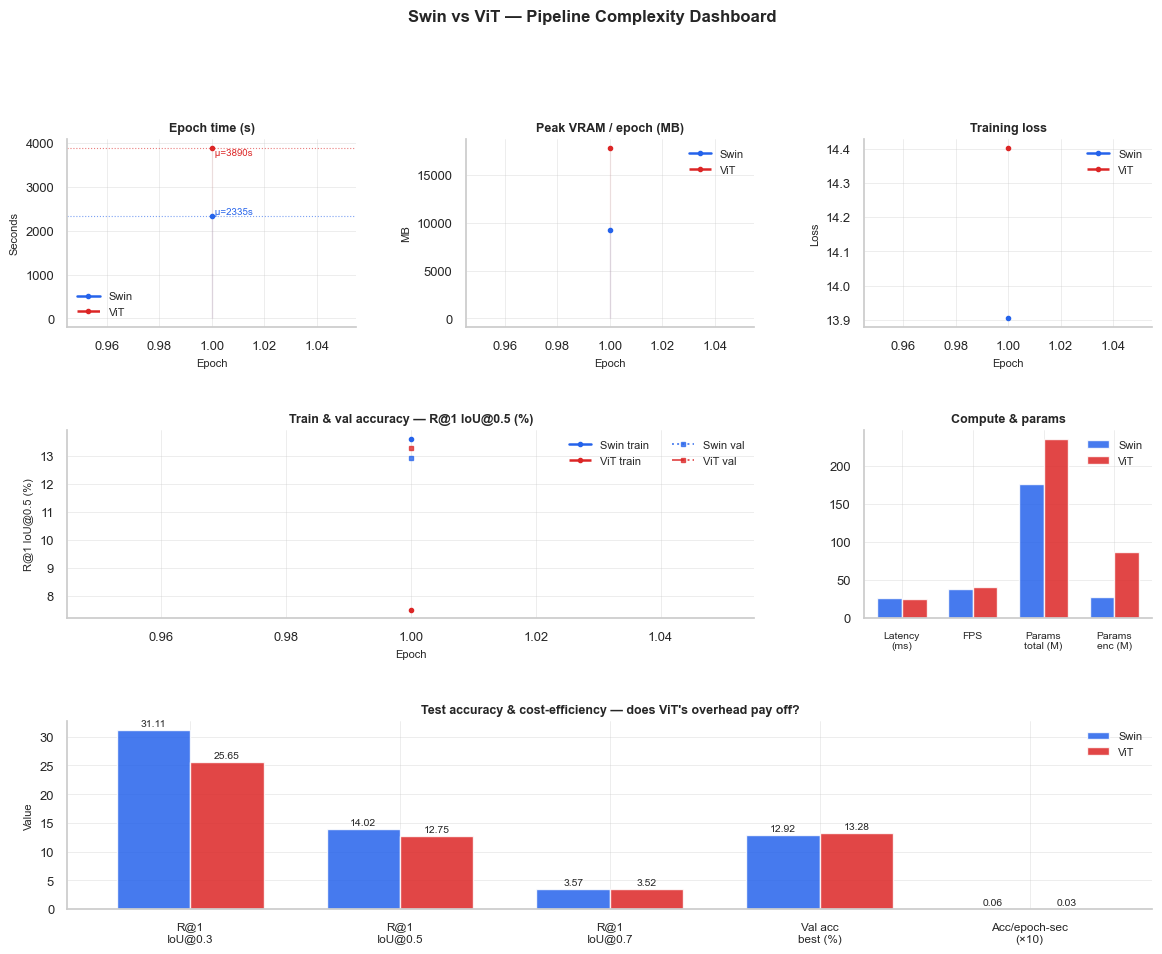

[OK] Saved: cell26_complexity.png


In [39]:
# Cell 26: Pipeline Complexity — Swin vs ViT  (matplotlib / seaborn)
# Sources: PROFILE_RESULTS (Cell 20b), COMPARISON_RESULTS (Cell 21b), TEST_RESULTS (Cell 22)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── palette ──────────────────────────────────────────────────────────
C_SWIN = "#2563eb"
C_VIT  = "#dc2626"
C_SWIN_A = "#2563eb33"
C_VIT_A  = "#dc262633"

sns.set_theme(style="whitegrid", font_scale=0.85)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "grid.linewidth": 0.5, "grid.alpha": 0.5})

pr = PROFILE_RESULTS
sh = COMPARISON_RESULTS.get("Swin", {})
vh = COMPARISON_RESULTS.get("ViT",  {})
eps = sorted(set(list(sh.keys()) + list(vh.keys())))
eps1 = [e + 1 for e in eps]

def extract(hist, key):
    return [hist.get(e, {}).get(key, 0) or 0 for e in eps]

def last_valid(hist, key):
    for e in sorted(hist.keys(), reverse=True):
        v = hist.get(e, {}).get(key)
        if v and v == v and v > 0:
            return round(v, 2)
    return 0.0

def mean_nz(lst):
    vals = [x for x in lst if x > 0]
    return float(np.nanmean(vals)) if vals else 0.0

# ── scalars ───────────────────────────────────────────────────────────
s_lat  = round(pr.get("Swin",{}).get("latency_ms",   0), 2)
v_lat  = round(pr.get("ViT", {}).get("latency_ms",   0), 2)
s_vram = round(pr.get("Swin",{}).get("vram_peak_MB", 0), 1)
v_vram = round(pr.get("ViT", {}).get("vram_peak_MB", 0), 1)
s_prm  = round(pr.get("Swin",{}).get("params_total_M",     0), 2)
v_prm  = round(pr.get("ViT", {}).get("params_total_M",     0), 2)
s_venc = round(pr.get("Swin",{}).get("params_video_enc_M", 0), 2)
v_venc = round(pr.get("ViT", {}).get("params_video_enc_M", 0), 2)
s_fps  = round(1000 / max(s_lat, 1e-3), 2)
v_fps  = round(1000 / max(v_lat, 1e-3), 2)

# ── per-epoch series ──────────────────────────────────────────────────
s_epoch_t   = extract(sh, "epoch_secs")
v_epoch_t   = extract(vh, "epoch_secs")
s_ep_vram   = extract(sh, "peak_vram_MB")
v_ep_vram   = extract(vh, "peak_vram_MB")
s_loss      = extract(sh, "train_loss")
v_loss      = extract(vh, "train_loss")
s_train_acc = extract(sh, "train_acc")
v_train_acc = extract(vh, "train_acc")
s_val_acc   = extract(sh, "val_acc")
v_val_acc   = extract(vh, "val_acc")

s_mean_t  = mean_nz(s_epoch_t)
v_mean_t  = mean_nz(v_epoch_t)
s_mean_vr = mean_nz(s_ep_vram)
v_mean_vr = mean_nz(v_ep_vram)

# ── accuracy ──────────────────────────────────────────────────────────
s_best_train = last_valid(sh, "train_acc")
v_best_train = last_valid(vh, "train_acc")
s_best_val   = last_valid(sh, "val_acc")
v_best_val   = last_valid(vh, "val_acc")

tr = TEST_RESULTS if "TEST_RESULTS" in dir() else {}
s_r03 = tr.get("Swin",{}).get("R@1_IoU0.3", 0.0)
v_r03 = tr.get("ViT", {}).get("R@1_IoU0.3", 0.0)
s_r05 = tr.get("Swin",{}).get("R@1_IoU0.5", 0.0)
v_r05 = tr.get("ViT", {}).get("R@1_IoU0.5", 0.0)
s_r07 = tr.get("Swin",{}).get("R@1_IoU0.7", 0.0)
v_r07 = tr.get("ViT", {}).get("R@1_IoU0.7", 0.0)

s_apg = s_r05 / max(s_mean_t, 1e-3)
v_apg = v_r05 / max(v_mean_t, 1e-3)

# ── figure ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10), facecolor="white")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])   # epoch time
ax2 = fig.add_subplot(gs[0, 1])   # epoch VRAM
ax3 = fig.add_subplot(gs[0, 2])   # loss
ax4 = fig.add_subplot(gs[1, :2])  # train / val accuracy curves (wide)
ax5 = fig.add_subplot(gs[1, 2])   # compute bar (latency / params)
ax6 = fig.add_subplot(gs[2, :])   # test accuracy grouped bar (full width)

legend_kw = dict(frameon=False, fontsize=8)

# ── 1. Epoch time ─────────────────────────────────────────────────────
ax1.plot(eps1, s_epoch_t, color=C_SWIN, lw=1.8, marker="o", ms=3, label="Swin")
ax1.plot(eps1, v_epoch_t, color=C_VIT,  lw=1.8, marker="o", ms=3, ls="--", label="ViT")
ax1.fill_between(eps1, s_epoch_t, alpha=0.08, color=C_SWIN)
ax1.fill_between(eps1, v_epoch_t, alpha=0.08, color=C_VIT)
ax1.set_title("Epoch time (s)", fontsize=9, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=8); ax1.set_ylabel("Seconds", fontsize=8)
ax1.legend(**legend_kw)

# ── 2. Peak VRAM per epoch ────────────────────────────────────────────
ax2.plot(eps1, s_ep_vram, color=C_SWIN, lw=1.8, marker="o", ms=3, label="Swin")
ax2.plot(eps1, v_ep_vram, color=C_VIT,  lw=1.8, marker="o", ms=3, ls="--", label="ViT")
ax2.fill_between(eps1, s_ep_vram, alpha=0.08, color=C_SWIN)
ax2.fill_between(eps1, v_ep_vram, alpha=0.08, color=C_VIT)
ax2.set_title("Peak VRAM / epoch (MB)", fontsize=9, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=8); ax2.set_ylabel("MB", fontsize=8)
ax2.legend(**legend_kw)

# ── 3. Training loss ──────────────────────────────────────────────────
ax3.plot(eps1, s_loss, color=C_SWIN, lw=1.8, marker="o", ms=3, label="Swin")
ax3.plot(eps1, v_loss, color=C_VIT,  lw=1.8, marker="o", ms=3, ls="--", label="ViT")
ax3.set_title("Training loss", fontsize=9, fontweight="bold")
ax3.set_xlabel("Epoch", fontsize=8); ax3.set_ylabel("Loss", fontsize=8)
ax3.legend(**legend_kw)

# ── 4. Train & val accuracy curves ───────────────────────────────────
ax4.plot(eps1, s_train_acc, color=C_SWIN, lw=1.8, marker="o", ms=3, label="Swin train")
ax4.plot(eps1, v_train_acc, color=C_VIT,  lw=1.8, marker="o", ms=3, ls="--", label="ViT train")
ax4.plot(eps1, s_val_acc,   color=C_SWIN, lw=1.4, marker="s", ms=3, ls=":",  label="Swin val", alpha=0.75)
ax4.plot(eps1, v_val_acc,   color=C_VIT,  lw=1.4, marker="s", ms=3, ls="-.", label="ViT val",  alpha=0.75)
ax4.set_title("Train & val accuracy — R@1 IoU@0.5 (%)", fontsize=9, fontweight="bold")
ax4.set_xlabel("Epoch", fontsize=8); ax4.set_ylabel("R@1 IoU@0.5 (%)", fontsize=8)
ax4.legend(**legend_kw, ncol=2)

# ── 5. Compute: latency / params bar ─────────────────────────────────
metrics_c  = ["Latency\n(ms)", "FPS", "Params\ntotal (M)", "Params\nenc (M)"]
swin_c_vals = [s_lat, s_fps, s_prm, s_venc]
vit_c_vals  = [v_lat, v_fps, v_prm, v_venc]

x  = np.arange(len(metrics_c))
bw = 0.35
ax5.bar(x - bw/2, swin_c_vals, bw, color=C_SWIN, label="Swin", alpha=0.85)
ax5.bar(x + bw/2, vit_c_vals,  bw, color=C_VIT,  label="ViT",  alpha=0.85)
ax5.set_xticks(x); ax5.set_xticklabels(metrics_c, fontsize=7.5)
ax5.set_title("Compute & params", fontsize=9, fontweight="bold")
ax5.legend(**legend_kw)

# ── 6. Test accuracy + cost-efficiency (full-width grouped bar) ───────
test_labels  = ["R@1\nIoU@0.3", "R@1\nIoU@0.5", "R@1\nIoU@0.7",
                "Val acc\nbest (%)", "Acc/epoch-sec\n(×10)"]
swin_t_vals  = [s_r03, s_r05, s_r07, s_best_val, round(s_apg * 10, 3)]
vit_t_vals   = [v_r03, v_r05, v_r07, v_best_val, round(v_apg * 10, 3)]

x  = np.arange(len(test_labels))
bw = 0.35
bars_s = ax6.bar(x - bw/2, swin_t_vals, bw, color=C_SWIN, label="Swin", alpha=0.85)
bars_v = ax6.bar(x + bw/2, vit_t_vals,  bw, color=C_VIT,  label="ViT",  alpha=0.85)

# value labels on bars
for bar in list(bars_s) + list(bars_v):
    h = bar.get_height()
    if h > 0:
        ax6.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                 f"{h:.2f}", ha="center", va="bottom", fontsize=7.5)

ax6.set_xticks(x); ax6.set_xticklabels(test_labels, fontsize=8.5)
ax6.set_title("Test accuracy & cost-efficiency — does ViT's overhead pay off?",
              fontsize=9, fontweight="bold")
ax6.set_ylabel("Value", fontsize=8)
ax6.legend(**legend_kw)

# ── shared mean-time annotation on ax1 ───────────────────────────────
ax1.axhline(s_mean_t, color=C_SWIN, lw=0.8, ls=":", alpha=0.6)
ax1.axhline(v_mean_t, color=C_VIT,  lw=0.8, ls=":", alpha=0.6)
ax1.text(eps1[-1], s_mean_t, f" μ={s_mean_t:.0f}s", color=C_SWIN, fontsize=7, va="bottom")
ax1.text(eps1[-1], v_mean_t, f" μ={v_mean_t:.0f}s", color=C_VIT,  fontsize=7, va="top")

fig.suptitle("Swin vs ViT — Pipeline Complexity Dashboard", fontsize=12, fontweight="bold", y=1.01)
plt.savefig("cell26_complexity.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: cell26_complexity.png")

In [41]:
# ── Overall winner ────────────────────────────────────────────────────

scoring = [
    # (label, swin_val, vit_val, lower_better, weight)
    ("Test R@1 IoU@0.3",      s_r03,      v_r03,      False, 2),
    ("Test R@1 IoU@0.5",      s_r05,      v_r05,      False, 3),  # primary metric
    ("Test R@1 IoU@0.7",      s_r07,      v_r07,      False, 2),
    ("Val acc best",          s_best_val, v_best_val, False, 2),
    ("Latency (ms)",          s_lat,      v_lat,      True,  1),
    ("Mean epoch time (s)",   s_mean_t,   v_mean_t,   True,  1),
    ("Mean epoch VRAM (MB)",  s_mean_vr,  v_mean_vr,  True,  1),
    ("Peak VRAM fwd (MB)",    s_vram,     v_vram,     True,  1),
    ("Params total (M)",      s_prm,      v_prm,      True,  1),
    ("Acc / epoch-sec",       s_apg,      v_apg,      False, 2),
]

swin_pts = vit_pts = 0
rows = []

for label, sv, vv, lower_better, w in scoring:
    if sv == vv == 0:
        rows.append((label, sv, vv, w, "-", "-"))
        continue
    if lower_better:
        swin_win = sv < vv
    else:
        swin_win = sv > vv
    tied = sv == vv
    if tied:
        rows.append((label, sv, vv, w, "tie", "tie"))
    elif swin_win:
        swin_pts += w
        rows.append((label, sv, vv, w, f"+{w}", ""))
    else:
        vit_pts += w
        rows.append((label, sv, vv, w, "", f"+{w}"))

total = swin_pts + vit_pts
swin_pct = round(100 * swin_pts / total, 1) if total else 0
vit_pct  = round(100 * vit_pts  / total, 1) if total else 0

if swin_pts > vit_pts:
    winner, margin = "Swin", swin_pts - vit_pts
elif vit_pts > swin_pts:
    winner, margin = "ViT", vit_pts - swin_pts
else:
    winner, margin = "tie", 0

W = 70
print("=" * W)
print(f"  {'Metric':<28} {'Swin':>8} {'ViT':>8}  {'Wt':>3}  Swin  ViT")
print("-" * W)
for label, sv, vv, w, sp, vp in rows:
    print(f"  {label:<28} {sv:>8.2f} {vv:>8.2f}  {w:>3}  {sp:<5} {vp}")
print("=" * W)
print(f"  Weighted score          Swin {swin_pts:>3} pts ({swin_pct}%)"
      f"   ViT {vit_pts:>3} pts ({vit_pct}%)")
print("-" * W)
if winner == "tie":
    print("  OVERALL WINNER : tie")
else:
    print(f"  OVERALL WINNER : {winner}  (margin: {margin} pts)")
print("=" * W)

  Metric                           Swin      ViT   Wt  Swin  ViT
----------------------------------------------------------------------
  Test R@1 IoU@0.3                31.11    25.65    2  +2    
  Test R@1 IoU@0.5                14.02    12.75    3  +3    
  Test R@1 IoU@0.7                 3.57     3.52    2  +2    
  Val acc best                    12.92    13.28    2        +2
  Latency (ms)                    26.16    24.62    1        +1
  Mean epoch time (s)           2335.27  3889.62    1  +1    
  Mean epoch VRAM (MB)          9286.20 17832.10    1  +1    
  Peak VRAM fwd (MB)            1867.20  2005.70    1  +1    
  Params total (M)               175.79   234.96    1  +1    
  Acc / epoch-sec                  0.01     0.00    2  +2    
  Weighted score          Swin  13 pts (81.2%)   ViT   3 pts (18.8%)
----------------------------------------------------------------------
  OVERALL WINNER : Swin  (margin: 10 pts)
